In [1]:
# !pip install pyarrow
# !pip install hdfs

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

import os
import psycopg2
from psycopg2 import connect
from dotenv import load_dotenv
from hdfs import InsecureClient
from sqlalchemy import create_engine

import warnings
warnings.filterwarnings('ignore')

# Load the Dataset from HDFS

In [3]:
client = InsecureClient('http://localhost:9870', user='jihadakbr')

In [4]:
with client.read('/user/jihadakbr/credit_risk/raw/application_train.csv', encoding='utf-8') as reader:
    train = pd.read_csv(reader)

In [5]:
with client.read('/user/jihadakbr/credit_risk/raw/application_test.csv', encoding='utf-8') as reader:
    test = pd.read_csv(reader)

In [6]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
test.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
pd.set_option('display.max_info_columns', 200)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [10]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 121 columns):
 #    Column                        Non-Null Count  Dtype  
---   ------                        --------------  -----  
 0    SK_ID_CURR                    48744 non-null  int64  
 1    NAME_CONTRACT_TYPE            48744 non-null  object 
 2    CODE_GENDER                   48744 non-null  object 
 3    FLAG_OWN_CAR                  48744 non-null  object 
 4    FLAG_OWN_REALTY               48744 non-null  object 
 5    CNT_CHILDREN                  48744 non-null  int64  
 6    AMT_INCOME_TOTAL              48744 non-null  float64
 7    AMT_CREDIT                    48744 non-null  float64
 8    AMT_ANNUITY                   48720 non-null  float64
 9    AMT_GOODS_PRICE               48744 non-null  float64
 10   NAME_TYPE_SUITE               47833 non-null  object 
 11   NAME_INCOME_TYPE              48744 non-null  object 
 12   NAME_EDUCATION_TYPE           48744 non-null

# Concatenate Train and Test Sets

In [11]:
# Add an identifier so we know where each row came from
train['is_train'] = True
test['is_train'] = False

In [12]:
# Add a placeholder for the target in test so columns align
test['TARGET'] = None

In [13]:
# Combine the datasets, It will automatically order the column
df = pd.concat([train, test], ignore_index=True)

In [14]:
train.shape, test.shape, df.shape

((307511, 123), (48744, 123), (356255, 123))

In [15]:
df[df['is_train']].head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,is_train
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,True
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,True
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,True
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,True
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,True


In [16]:
df[~df['is_train']].head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,is_train
307511,100001,None,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,False
307512,100005,None,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,False
307513,100013,None,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,...,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0,False
307514,100028,None,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,False
307515,100038,None,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False


# Data Preprocessing I

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 123 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    356255 non-null  int64  
 1    TARGET                        307511 non-null  object 
 2    NAME_CONTRACT_TYPE            356255 non-null  object 
 3    CODE_GENDER                   356255 non-null  object 
 4    FLAG_OWN_CAR                  356255 non-null  object 
 5    FLAG_OWN_REALTY               356255 non-null  object 
 6    CNT_CHILDREN                  356255 non-null  int64  
 7    AMT_INCOME_TOTAL              356255 non-null  float64
 8    AMT_CREDIT                    356255 non-null  float64
 9    AMT_ANNUITY                   356219 non-null  float64
 10   AMT_GOODS_PRICE               355977 non-null  float64
 11   NAME_TYPE_SUITE               354052 non-null  object 
 12   NAME_INCOME_TYPE            

## Handling Duplicate Data

In [18]:
# Check duplicate data
df.duplicated().sum().sum()

0

There are no duplicates found.

## Converting Data Type

In [19]:
df['SK_ID_CURR'] = df['SK_ID_CURR'].astype(str)

## Handling Error Data

Pandas DataFrame can automatically convert a numeric column to an object type if it contains even a single non-numeric value. Therefore, if a column retains its numeric type, its data distribution can be directly analyzed using `df.describe()`.

For categorical columns, data errors should be reviewed per column to ensure consistency and accuracy.

In [20]:
pd.set_option('display.max_columns', None)       # Show all columns
pd.set_option('display.float_format', '{:.3f}'.format)  # Disable scientific notation
pd.set_option('display.max_rows', None)

In [21]:
df.describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,356255.000,356255.000,356255.000,356219.000,355977.000,356255.000,356255.000,356255.000,356255.000,356255.000,121014.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356253.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,162345.000,355587.000,286622.000,176307.000,148671.000,183392.000,119949.000,107895.000,167175.000,177848.000,179914.000,115147.000,145411.000,113276.000,178353.000,109394.000,160489.000,176307.000,148671.000,183392.000,119949.000,107895.000,167175.000,177848.000,179914.000,115147.000,145411.000,113276.000,178353.000,109394.000,160489.000,176307.000,148671.000,183392.000,119949.000,107895.000,167175.000,177848.000,179914.000,115147.000,145411.000,113276.000,178353.000,109394.000,160489.000,185200.000,355205.000,355205.000,355205.000,355205.000,356254.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,308687.000,308687.000,308687.000,308687.000,308687.000,308687.000
mean,0.414,170116.060,587767.414,27425.561,528019.998,0.021,-16041.249,64317.231,-4983.594,-3002.071,12.024,1.000,0.818,0.200,0.998,0.279,0.071,2.152,2.051,2.029,12.056,0.016,0.051,0.041,0.078,0.230,0.179,0.502,0.515,0.509,0.118,0.089,0.978,0.752,0.045,0.080,0.150,0.227,0.233,0.066,0.101,0.108,0.009,0.029,0.115,0.088,0.977,0.759,0.043,0.075,0.145,0.223,0.229,0.065,0.106,0.107,0.008,0.027,0.119,0.088,0.978,0.756,0.045,0.079,0.149,0.227,0.233,0.067,0.103,0.109,0.009,0.028,0.103,1.426,0.143,1.409,0.100,-978.581,0.000,0.721,0.000,0.015,0.088,0.000,0.082,0.004,0.000,0.004,0.000,0.003,0.003,0.001,0.009,0.000,0.007,0.001,0.000,0.000,0.006,0.006,0.030,0.232,0.304,1.912
std,0.720,223506.819,398623.694,14732.808,366064.986,0.014,4358.804,141705.533,3526.969,1517.902,11.881,0.002,0.385,0.400,0.043,0.448,0.257,0.908,0.511,0.505,3.268,0.124,0.221,0.198,0.268,0.421,0.383,0.210,0.190,0.194,0.109,0.082,0.058,0.113,0.077,0.135,0.100,0.145,0.162,0.081,0.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 123 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    356255 non-null  object 
 1    TARGET                        307511 non-null  object 
 2    NAME_CONTRACT_TYPE            356255 non-null  object 
 3    CODE_GENDER                   356255 non-null  object 
 4    FLAG_OWN_CAR                  356255 non-null  object 
 5    FLAG_OWN_REALTY               356255 non-null  object 
 6    CNT_CHILDREN                  356255 non-null  int64  
 7    AMT_INCOME_TOTAL              356255 non-null  float64
 8    AMT_CREDIT                    356255 non-null  float64
 9    AMT_ANNUITY                   356219 non-null  float64
 10   AMT_GOODS_PRICE               355977 non-null  float64
 11   NAME_TYPE_SUITE               354052 non-null  object 
 12   NAME_INCOME_TYPE            

In [23]:
df["TARGET"].value_counts().sort_index()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [24]:
pd.reset_option('display.max_rows')

In [25]:
df["NAME_CONTRACT_TYPE"].value_counts().sort_index()

NAME_CONTRACT_TYPE
Cash loans         326537
Revolving loans     29718
Name: count, dtype: int64

In [26]:
df["CODE_GENDER"].value_counts().sort_index()

CODE_GENDER
F      235126
M      121125
XNA         4
Name: count, dtype: int64

In [27]:
df["NAME_TYPE_SUITE"].value_counts().sort_index()

NAME_TYPE_SUITE
Children             3675
Family              46030
Group of people       320
Other_A               975
Other_B              1981
Spouse, partner     12818
Unaccompanied      288253
Name: count, dtype: int64

In [28]:
df["NAME_INCOME_TYPE"].value_counts().sort_index()

NAME_INCOME_TYPE
Businessman                 11
Commercial associate     83019
Maternity leave              5
Pensioner                64635
State servant            25235
Student                     20
Unemployed                  23
Working                 183307
Name: count, dtype: int64

In [29]:
df["NAME_EDUCATION_TYPE"].value_counts().sort_index()

NAME_EDUCATION_TYPE
Academic degree                     205
Higher education                  87379
Incomplete higher                 12001
Lower secondary                    4291
Secondary / secondary special    252379
Name: count, dtype: int64

In [30]:
df["NAME_FAMILY_STATUS"].value_counts().sort_index()

NAME_FAMILY_STATUS
Civil marriage           34036
Married                 228715
Separated                22725
Single / not married     52480
Unknown                      2
Widow                    18297
Name: count, dtype: int64

In [31]:
df["NAME_HOUSING_TYPE"].value_counts().sort_index()

NAME_HOUSING_TYPE
Co-op apartment          1245
House / apartment      316513
Municipal apartment     12800
Office apartment         3024
Rented apartment         5599
With parents            17074
Name: count, dtype: int64

In [32]:
df["OCCUPATION_TYPE"].value_counts().sort_index()

OCCUPATION_TYPE
Accountants              11441
Cleaning staff            5309
Cooking staff             6840
Core staff               31931
Drivers                  21376
HR staff                   667
High skill tech staff    13234
IT staff                   607
Laborers                 63841
Low-skill Laborers        2365
Managers                 24945
Medicine staff            9853
Private service staff     3107
Realty agents              889
Sales staff              37174
Secretaries               1518
Security staff            7636
Waiters/barmen staff      1526
Name: count, dtype: int64

In [33]:
df["WEEKDAY_APPR_PROCESS_START"].value_counts().sort_index()

WEEKDAY_APPR_PROCESS_START
FRIDAY       57588
MONDAY       59120
SATURDAY     38455
SUNDAY       18040
THURSDAY     59009
TUESDAY      63652
WEDNESDAY    60391
Name: count, dtype: int64

In [34]:
df["ORGANIZATION_TYPE"].value_counts().sort_index()

ORGANIZATION_TYPE
Advertising                 500
Agriculture                2746
Bank                       2881
Business Entity Type 1     6871
Business Entity Type 2    12032
Business Entity Type 3    78832
Cleaning                    303
Construction               7760
Culture                     440
Electricity                1106
Emergency                   651
Government                11912
Hotel                      1100
Housing                    3393
Industry: type 1           1217
Industry: type 10           133
Industry: type 11          3120
Industry: type 12           446
Industry: type 13            73
Industry: type 2            535
Industry: type 3           3767
Industry: type 4           1044
Industry: type 5            696
Industry: type 6            139
Industry: type 7           1524
Industry: type 8             27
Industry: type 9           3867
Insurance                   677
Kindergarten               7918
Legal Services              358
Medicine              

In [35]:
df["FONDKAPREMONT_MODE"].value_counts().sort_index()

FONDKAPREMONT_MODE
not specified             6600
org spec account          6539
reg oper account         85954
reg oper spec account    14070
Name: count, dtype: int64

In [36]:
df["HOUSETYPE_MODE"].value_counts().sort_index()

HOUSETYPE_MODE
block of flats      175162
specific housing      1761
terraced house        1416
Name: count, dtype: int64

In [37]:
df["WALLSMATERIAL_MODE"].value_counts().sort_index()

WALLSMATERIAL_MODE
Block           10681
Mixed            2649
Monolithic       2068
Others           1909
Panel           77309
Stone, brick    75249
Wooden           6156
Name: count, dtype: int64

In [38]:
df["EMERGENCYSTATE_MODE"].value_counts().sort_index()

EMERGENCYSTATE_MODE
No     185607
Yes      2684
Name: count, dtype: int64

# Splitting the Dataset

In [39]:
# Recover the train and test sets
train = df[df['is_train']].copy().reset_index(drop=True)
test = df[~df['is_train']].copy().reset_index(drop=True)

In [40]:
# Drop helper columns
train = train.drop(columns=['is_train'])
test = test.drop(columns=['is_train', 'TARGET'])

In [41]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,351000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,-3648.000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083,0.263,0.139,0.025,0.037,0.972,0.619,0.014,0.000,0.069,0.083,0.125,0.037,0.020,0.019,0.000,0.000,0.025,0.038,0.972,0.634,0.014,0.000,0.069,0.083,0.125,0.038,0.022,0.020,0.000,0.000,0.025,0.037,0.972,0.624,0.014,0.000,0.069,0.083,0.125,0.037,0.021,0.019,0.000,0.000,reg oper account,block of flats,0.015,"Stone, brick",No,2.000,2.000,2.000,2.000,-1134.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,1129500.000,Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,-1186.000,-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311,0.622,NaN,0.096,0.053,0.985,0.796,0.060,0.080,0.035,0.292,0.333,0.013,0.077,0.055,0.004,0.010,0.092,0.054,0.985,0.804,0.050,0.081,0.035,0.292,0.333,0.013,0.079,0.055,0.000,0.000,0.097,0.053,0.985,0.799,0.061,0.080,0.035,0.292,0.333,0.013,0.079,0.056,0.004,0.010,reg oper account,block of flats,0.071,Block,No,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,135000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,-4260.000,-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556,0.730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [42]:
test.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.000,568800.000,20560.500,450000.000,Unaccompanied,Working,Higher education,Married,House / apartment,0.019,-19241,-2329,-5170.000,-812,NaN,1,1,0,1,0,1,NaN,2.000,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.753,0.790,0.160,0.066,0.059,0.973,NaN,NaN,NaN,0.138,0.125,NaN,NaN,NaN,0.051,NaN,NaN,0.067,0.061,0.973,NaN,NaN,NaN,0.138,0.125,NaN,NaN,NaN,0.053,NaN,NaN,0.067,0.059,0.973,NaN,NaN,NaN,0.138,0.125,NaN,NaN,NaN,0.051,NaN,NaN,NaN,block of flats,0.039,"Stone, brick",No,0.000,0.000,0.000,0.000,-1740.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
1,100005,Cash loans,M,N,Y,0,99000.000,222768.000,17370.000,180000.000,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.036,-18064,-4469,-9118.000,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.000,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.565,0.292,0.433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,3.000
2,100013,Cash loans,M,Y,Y,0,202500.000,663264.000,69777.000,630000.000,NaN,Working,Higher education,Married,House / apartment,0.019,-20038,-4458,-2175.000,-3503,5.000,1,1,0,1,0,0,Drivers,2.000,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.700,0.611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,-856.000,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,1.000,4.000
3,100028,Cash loans,F,N,Y,2,315000.000,1575000.000,49018.500,1575000.

In [43]:
train.shape, test.shape, df.shape

((307511, 122), (48744, 121), (356255, 123))

**TARGET column value percentages**

In [44]:
df["TARGET"].value_counts(normalize=True).sort_index() * 100

TARGET
0   91.927
1    8.073
Name: proportion, dtype: float64

In [45]:
train["TARGET"].value_counts(normalize=True).sort_index() * 100

TARGET
0   91.927
1    8.073
Name: proportion, dtype: float64

# Data Preprocessing II

## Handling Missing Values

In [46]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    # Calculate missing values and their percentages
    missing = train.isna().sum()
    missing_percent = (missing / len(train)) * 100
    
    # Filter for columns with missing values and print
    missing_data = pd.DataFrame({
        'Missing Count': missing[missing > 0],
        'Missing Percent': missing_percent[missing > 0]
    })
    print(missing_data)

                              Missing Count  Missing Percent
AMT_ANNUITY                              12            0.004
AMT_GOODS_PRICE                         278            0.090
NAME_TYPE_SUITE                        1292            0.420
OWN_CAR_AGE                          202929           65.991
OCCUPATION_TYPE                       96391           31.346
CNT_FAM_MEMBERS                           2            0.001
EXT_SOURCE_1                         173378           56.381
EXT_SOURCE_2                            660            0.215
EXT_SOURCE_3                          60965           19.825
APARTMENTS_AVG                       156061           50.750
BASEMENTAREA_AVG                     179943           58.516
YEARS_BEGINEXPLUATATION_AVG          150007           48.781
YEARS_BUILD_AVG                      204488           66.498
COMMONAREA_AVG                       214865           69.872
ELEVATORS_AVG                        163891           53.296
ENTRANCES_AVG           

### Rows with >=50% Missing values

In [47]:
# Set threshold
threshold = 0.5

**Train Set**

In [48]:
# Find rows where the fraction of missing values is >= 50%
mask_train = train.isnull().mean(axis=1) >= threshold

In [49]:
# Display those rows
rows_with_many_nans = train[mask_train]

In [50]:
rows_with_many_nans

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
69707,180861,0,Revolving loans,F,N,Y,0,67500.000,202500.000,10125.000,202500.000,Unaccompanied,Working,Secondary / secondary special,Widow,House / apartment,0.031,-16787,-808,-2926.000,-314,NaN,1,1,0,1,0,0,NaN,1.000,2,2,TUESDAY,12,0,0,0,0,0,0,Self-employed,NaN,0.697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-361.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
116937,235599,0,Revolving loans,M,N,N,0,225000.000,720000.000,36000.000,720000.000,Unaccompanied,Pensioner,Secondary / secondary special,Single / not married,House / apartment,0.006,-10529,365243,-2479.000,-2478,NaN,1,0,0,1,0,0,NaN,1.000,3,3,THURSDAY,5,0,0,0,0,0,0,XNA,NaN,0.464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-29.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
133770,255145,0,Revolving loans,F,N,Y,0,225000.000,405000.000,20250.000,405000.000,Unaccompanied,Pensioner,Higher education,Married,House / apartment,0.046,-22597,365243,-4115.000,-4413,NaN,1,0,0,1,0,0,NaN,2.000,1,1,MONDAY,14,0,0,0,0,0,0,XNA,NaN,0.447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-505.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
150206,274127,0,Revolving loans,M,N,N,0,450000.000,1237500.000,61875.000,1237500.000,Unaccompanied,Commercial associate,Secondary / secondary special,Single /

In [51]:
# get the indices to drop them
indices_to_drop = train[mask_train].index

In [52]:
train = train.drop(index=indices_to_drop)

In [53]:
mask_train = train.isnull().mean(axis=1) >= threshold
rows_with_many_nans = train[mask_train]
rows_with_many_nans

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR


**Test Set**

In [54]:
mask_test = test.isnull().mean(axis=1) >= threshold
rows_with_many_nans = test[mask_test]
rows_with_many_nans

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
45915,435535,Revolving loans,F,N,Y,0,337500.000,360000.000,18000.000,360000.000,Unaccompanied,Pensioner,Secondary / secondary special,Single / not married,House / apartment,0.033,-18780,365243,-204.000,-2312,NaN,1,0,0,0,0,0,NaN,1.000,1,1,WEDNESDAY,16,0,0,0,0,0,0,XNA,NaN,0.573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-330.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
indices_to_drop = test[mask_test].index
test = test.drop(index=indices_to_drop)

In [56]:
mask_test = test.isnull().mean(axis=1) >= threshold
rows_with_many_nans = test[mask_test]
rows_with_many_nans

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR


### Columns with Minimal Missing Values (<1%)

Numerical: impute with median  
Categorical: impute with mode

Why? Negligible impact on model performance, simple imputation suffices.

In [57]:
missing = train.isna().sum()
missing_percent = (missing / len(train)) * 100

mask = (missing_percent > 0) & (missing_percent < 1)

missing_data = pd.DataFrame({
    'Missing Count': missing[mask],
    'Missing Percent': missing_percent[mask]
})
print(missing_data)

                          Missing Count  Missing Percent
AMT_ANNUITY                          12            0.004
AMT_GOODS_PRICE                     278            0.090
NAME_TYPE_SUITE                    1292            0.420
CNT_FAM_MEMBERS                       2            0.001
EXT_SOURCE_2                        660            0.215
OBS_30_CNT_SOCIAL_CIRCLE           1012            0.329
DEF_30_CNT_SOCIAL_CIRCLE           1012            0.329
OBS_60_CNT_SOCIAL_CIRCLE           1012            0.329
DEF_60_CNT_SOCIAL_CIRCLE           1012            0.329
DAYS_LAST_PHONE_CHANGE                1            0.000


In [58]:
# Columns with <1% missing values
low_missing_cols = [
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'NAME_TYPE_SUITE',
    'CNT_FAM_MEMBERS',
    'EXT_SOURCE_2',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',
    'DAYS_LAST_PHONE_CHANGE'
]

In [59]:
# Separate into numerical and categorical
num_cols = train[low_missing_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train[low_missing_cols].select_dtypes(include=['object']).columns.tolist()

In [60]:
print("Numerical columns to impute:", num_cols)
print("Categorical columns to impute:", cat_cols)

Numerical columns to impute: ['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_2', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE']
Categorical columns to impute: ['NAME_TYPE_SUITE']


In [61]:
# TRAIN N TEST - Impute numerical columns using MEDIAN from the training set
for col in num_cols:
    median_val = train[col].median()
    train[col].fillna(median_val, inplace=True)
    test[col].fillna(median_val, inplace=True)

In [62]:
# TRAIN N TEST - Impute categorical columns using MODE from the training set
for col in cat_cols:
    mode_val = train[col].mode()[0]  # Take the first mode if multiple exist
    train[col].fillna(mode_val, inplace=True)
    test[col].fillna(mode_val, inplace=True)

In [63]:
# Verify no missing values remain
print("TRAIN - Remaining missing values after imputation:")
print(train[low_missing_cols].isnull().sum())

TRAIN - Remaining missing values after imputation:
AMT_ANNUITY                 0
AMT_GOODS_PRICE             0
NAME_TYPE_SUITE             0
CNT_FAM_MEMBERS             0
EXT_SOURCE_2                0
OBS_30_CNT_SOCIAL_CIRCLE    0
DEF_30_CNT_SOCIAL_CIRCLE    0
OBS_60_CNT_SOCIAL_CIRCLE    0
DEF_60_CNT_SOCIAL_CIRCLE    0
DAYS_LAST_PHONE_CHANGE      0
dtype: int64


In [64]:
# Verify no missing values remain
print("TEST - Remaining missing values after imputation:")
print(test[low_missing_cols].isnull().sum())

TEST - Remaining missing values after imputation:
AMT_ANNUITY                 0
AMT_GOODS_PRICE             0
NAME_TYPE_SUITE             0
CNT_FAM_MEMBERS             0
EXT_SOURCE_2                0
OBS_30_CNT_SOCIAL_CIRCLE    0
DEF_30_CNT_SOCIAL_CIRCLE    0
OBS_60_CNT_SOCIAL_CIRCLE    0
DEF_60_CNT_SOCIAL_CIRCLE    0
DAYS_LAST_PHONE_CHANGE      0
dtype: int64


### Columns with Moderate Missingness (1-30%)

In [65]:
missing = train.isna().sum()
missing_percent = (missing / len(train)) * 100

mask = (missing_percent >= 1) & (missing_percent <= 30)

missing_data = pd.DataFrame({
    'Missing Count': missing[mask],
    'Missing Percent': missing_percent[mask]
})
print(missing_data)

                            Missing Count  Missing Percent
EXT_SOURCE_3                        60956           19.823
AMT_REQ_CREDIT_BUREAU_HOUR          41510           13.499
AMT_REQ_CREDIT_BUREAU_DAY           41510           13.499
AMT_REQ_CREDIT_BUREAU_WEEK          41510           13.499
AMT_REQ_CREDIT_BUREAU_MON           41510           13.499
AMT_REQ_CREDIT_BUREAU_QRT           41510           13.499
AMT_REQ_CREDIT_BUREAU_YEAR          41510           13.499


**Credit Bureau Request Columns (13.5% missing)**

columns: AMT_REQ_CREDIT_BUREAU_HOUR, _DAY, _WEEK, _MON, _QRT, _YEAR

Create a missing indicator flag (FLAG_CREDIT_BUREAU_MISSING)  
Impute missing values with 0 (assuming missing = no recent credit requests)

Why? Missingness likely systematic (e.g., no credit history). A flag captures this pattern.

**External Source 3 (19.8% missing)**

Create a missing indicator flag (FLAG_EXT_SOURCE_3_MISSING)  
Impute with median

Why? EXT_SOURCE features are critical risk predictors, flags preserve missingness signal.

In [66]:
moderate_missing_cols = [
    # Credit bureau requests (13.5% missing)
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
    
    # External sources
    'EXT_SOURCE_3'  # 19.8% missing
]

In [67]:
# Separate into numerical and categorical
num_cols = train[moderate_missing_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train[moderate_missing_cols].select_dtypes(include=['object']).columns.tolist()

In [68]:
print("Numerical cols:", num_cols)
print("Categorical cols:", cat_cols)

Numerical cols: ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_3']
Categorical cols: []


In [69]:
# TRAIN N TEST - Identify Credit Bureau columns
credit_bureau_cols = [col for col in train.columns if 'CREDIT_BUREAU' in col]

# Flag and impute with 0 in train
train['FLAG_CREDIT_BUREAU_MISSING'] = train[credit_bureau_cols].isnull().any(axis=1).astype(int)
train[credit_bureau_cols] = train[credit_bureau_cols].fillna(0)

# Flag and impute with 0 in test (using same columns)
test['FLAG_CREDIT_BUREAU_MISSING'] = test[credit_bureau_cols].isnull().any(axis=1).astype(int)
test[credit_bureau_cols] = test[credit_bureau_cols].fillna(0)

In [70]:
# df - Identify Credit Bureau columns

# Flag and impute in with 0 in df
df['FLAG_CREDIT_BUREAU_MISSING'] = df[credit_bureau_cols].isnull().any(axis=1).astype(int)
df[credit_bureau_cols] = df[credit_bureau_cols].fillna(0)

In [71]:
# TRAIN N TEST - EXT_SOURCE_3: Flag + Impute Median

# Compute median from train only
ext_source_3_median = train['EXT_SOURCE_3'].median()

# Flag + impute in train
train['FLAG_EXT_SOURCE_3_MISSING'] = train['EXT_SOURCE_3'].isnull().astype(int)
train['EXT_SOURCE_3'].fillna(ext_source_3_median, inplace=True)

# Flag + impute in test
test['FLAG_EXT_SOURCE_3_MISSING'] = test['EXT_SOURCE_3'].isnull().astype(int)
test['EXT_SOURCE_3'].fillna(ext_source_3_median, inplace=True)

In [72]:
print(f"ext_source_3_median: {ext_source_3_median}")

ext_source_3_median: 0.5352762504724826


In [73]:
# df - EXT_SOURCE_3: Flag + WITHOUT Imputing a Median

# Flag
df['FLAG_EXT_SOURCE_3_MISSING'] = df['EXT_SOURCE_3'].isnull().astype(int)

In [74]:
# Verify TRAIN
print("Missing values after imputation:")
print(train[moderate_missing_cols].isnull().sum())

Missing values after imputation:
AMT_REQ_CREDIT_BUREAU_HOUR    0
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
EXT_SOURCE_3                  0
dtype: int64


In [75]:
# Verify TEST
print("Missing values after imputation:")
print(test[moderate_missing_cols].isnull().sum())

Missing values after imputation:
AMT_REQ_CREDIT_BUREAU_HOUR    0
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
EXT_SOURCE_3                  0
dtype: int64


### Columns with High Missingness (>30%)

In [76]:
missing = train.isna().sum()
missing_percent = (missing / len(train)) * 100

mask = missing_percent > 30

missing_data = pd.DataFrame({
    'Missing Count': missing[mask],
    'Missing Percent': missing_percent[mask]
})
print(missing_data)

                              Missing Count  Missing Percent
OWN_CAR_AGE                          202920           65.990
OCCUPATION_TYPE                       96382           31.344
EXT_SOURCE_1                         173369           56.380
APARTMENTS_AVG                       156052           50.748
BASEMENTAREA_AVG                     179934           58.515
YEARS_BEGINEXPLUATATION_AVG          149998           48.780
YEARS_BUILD_AVG                      204479           66.497
COMMONAREA_AVG                       214856           69.871
ELEVATORS_AVG                        163882           53.295
ENTRANCES_AVG                        154819           50.347
FLOORSMAX_AVG                        153011           49.759
FLOORSMIN_AVG                        208633           67.848
LANDAREA_AVG                         182581           59.376
LIVINGAPARTMENTS_AVG                 210190           68.354
LIVINGAREA_AVG                       154341           50.192
NONLIVINGAPARTMENTS_AVG 

In [77]:
print(missing_data.index)

Index(['OWN_CAR_AGE', 'OCCUPATION_TYPE', 'EXT_SOURCE_1', 'APARTMENTS_AVG',
       'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG',
       'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG',
       'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG',
       'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG',
       'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE',
       'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE',
       'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE',
       'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE',
       'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI',
       'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI',
       'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI',
       'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
       'NONLIVINGAPARTMENTS_MEDI', 'NONLI

**OWN_CAR_AGE (66% missing)**

Create a binary flag (FLAG_NO_CAR = 1 if missing, else 0)  
Impute missing values with 0 (logical: no car → car age = 0)

Why? Missingness strongly indicates no car. Flag captures this, while 0 preserves logical consistency.

**OCCUPATION_TYPE (31.3% missing)**

Impute with "Unknown" category

Why? Occupational data is inherently categorical, a new category avoids biased imputation.

**EXT_SOURCE_1 (56.3% missing)**

Create a missing indicator flag (FLAG_EXT_SOURCE_1_MISSING)  
Impute with median

Why? Critical predictive feature, flags help the model utilize missingness patterns.

**Building Information Columns (48-70% missing)**

Numerical: Impute with -999 (extreme value detectable by tree-based models).
Categorical: Impute with "Missing" category.

Why?  
High missingness suggests systemic absence (e.g., no property data)  
Avoid creating 40+ flags; let tree models split on -999/"Missing"  

In [78]:
high_missing_cols = [
    # Personal/ownership info
    'OWN_CAR_AGE',
    'OCCUPATION_TYPE',
    
    # External sources
    'EXT_SOURCE_1',
    
    # Building/apartment info (all variants: AVG, MODE, MEDI)
    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG',
    'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG',
    'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG',
    'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG',
    'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE',
    'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE',
    'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE',
    'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI',
    'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI',
    'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI',
    'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE',
    'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
]

In [79]:
# Separate into numerical and categorical
num_cols = train[high_missing_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train[high_missing_cols].select_dtypes(include=['object']).columns.tolist()

In [80]:
print("Numerical cols:", num_cols)
print("Categorical cols:", cat_cols)

Numerical cols: ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'TOTALAREA_MODE']
Categorical cols: ['OCCUPATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSE

In [81]:
# ===== OWN_CAR_AGE =====
# Flag and impute: 0 = no car
train['FLAG_NO_CAR'] = train['OWN_CAR_AGE'].isnull().astype(int)
train['OWN_CAR_AGE'].fillna(0, inplace=True)

test['FLAG_NO_CAR'] = test['OWN_CAR_AGE'].isnull().astype(int)
test['OWN_CAR_AGE'].fillna(0, inplace=True)

df['FLAG_NO_CAR'] = df['OWN_CAR_AGE'].isnull().astype(int)
df['OWN_CAR_AGE'].fillna(0, inplace=True)

In [82]:
# ===== OCCUPATION_TYPE =====
# Impute missing occupation as 'Unknown'
train['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)
test['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)
df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)

In [83]:
# ===== EXT_SOURCE_1 =====
# Compute median from train
ext_source_1_median = train['EXT_SOURCE_1'].median()

# Flag + impute in train
train['FLAG_EXT_SOURCE_1_MISSING'] = train['EXT_SOURCE_1'].isnull().astype(int)
train['EXT_SOURCE_1'].fillna(ext_source_1_median, inplace=True)

# Flag + impute in test
test['FLAG_EXT_SOURCE_1_MISSING'] = test['EXT_SOURCE_1'].isnull().astype(int)
test['EXT_SOURCE_1'].fillna(ext_source_1_median, inplace=True)

In [84]:
print(f"ext_source_1_median: {ext_source_1_median}")

ext_source_1_median: 0.5059979305057544


In [85]:
# ===== EXT_SOURCE_1 =====
# Flag
df['FLAG_EXT_SOURCE_1_MISSING'] = df['EXT_SOURCE_1'].isnull().astype(int)

In [86]:
# ===== Building-Related Columns =====
# Global missingness flag for all building features

# Identify building-related columns once
building_cols = [col for col in num_cols + cat_cols if 'AVG' in col or 'MODE' in col or 'MEDI' in col]

# Global missingness flag for building features
train['FLAG_BUILDING_INFO_MISSING'] = train[building_cols].isnull().any(axis=1).astype(int)
test['FLAG_BUILDING_INFO_MISSING'] = test[building_cols].isnull().any(axis=1).astype(int)
df['FLAG_BUILDING_INFO_MISSING'] = df[building_cols].isnull().any(axis=1).astype(int)

In [87]:
# Impute numerical building features with -999
building_num_cols = [col for col in building_cols if col in num_cols]

for col in building_num_cols:
    train[col].fillna(-999, inplace=True)
    test[col].fillna(-999, inplace=True)
    df[col].fillna(-999, inplace=True)

In [88]:
# Impute categorical building features with "Missing"
building_cat_cols = [col for col in building_cols if col in cat_cols]

for col in building_cat_cols:
    train[col].fillna('Missing', inplace=True)
    test[col].fillna('Missing', inplace=True)
    df[col].fillna('Missing', inplace=True)

In [89]:
# ===== Verify =====
print("Remaining missing values in high-missing cols:")
print(f"Train: {train[high_missing_cols].isnull().sum().sum()}")  # Should be 0
print(f"Test: {test[high_missing_cols].isnull().sum().sum()}")  # Should be 0

Remaining missing values in high-missing cols:
Train: 0
Test: 0


**Check Missing Values in the DataFrame**

In [90]:
train.isna().sum().sum()

0

In [91]:
test.isna().sum().sum()

0

In [92]:
df.isna().sum().sum()

319675

In [93]:
df.isna().sum()[df.isna().sum() > 0]

TARGET                       48744
AMT_ANNUITY                     36
AMT_GOODS_PRICE                278
NAME_TYPE_SUITE               2203
CNT_FAM_MEMBERS                  2
EXT_SOURCE_1                193910
EXT_SOURCE_2                   668
EXT_SOURCE_3                 69633
OBS_30_CNT_SOCIAL_CIRCLE      1050
DEF_30_CNT_SOCIAL_CIRCLE      1050
OBS_60_CNT_SOCIAL_CIRCLE      1050
DEF_60_CNT_SOCIAL_CIRCLE      1050
DAYS_LAST_PHONE_CHANGE           1
dtype: int64

## Handling Outliers

In [94]:
train.describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING
count,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000,307502.000
mean,0.417,168797.050,599028.093,27108.509,538316.611,0.021,-16037.021,63812.190,-4986.138,-2994.224,4.102,1.000,0.820,0.199,0.998,0.281,0.057,2.153,2.052,2.032,12.063,0.015,0.051,0.041,0.078,0.230,0.180,0.504,0.515,0.516,-506.918,-584.526,-486.807,-664.051,-698.002,-532.376,-502.895,-496.982,-677.724,-593.135,-682.825,-501.363,-693.624,-551.214,-506.919,-584.526,-486.807,-664.049,-698.003,-532.378,-502.898,-496.984,-677.725,-593.135,-682.823,-501.364,-693.624,-551.215,-506.917,-584.526,-486.807,-664.050,-698.002,-532.377,-502.896,-496.982,-677.724,-593.134,-682.824,-501.363,-693.624,-551.214,-482.134,1.418,0.143,1.401,0.100,-962.878,0.000,0.710,0.000,0.015,0.088,0.000,0.081,0.004,0.000,0.004,0.000,0.004,0.003,0.001,0.010,0.000,0.008,0.001,0.001,0.000,0.006,0.006,0.0

In [95]:
train.describe().loc[['mean', 'min', 'max']]

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING
mean,0.417,168797.050,599028.093,27108.509,538316.611,0.021,-16037.021,63812.190,-4986.138,-2994.224,4.102,1.000,0.820,0.199,0.998,0.281,0.057,2.153,2.052,2.032,12.063,0.015,0.051,0.041,0.078,0.230,0.180,0.504,0.515,0.516,-506.918,-584.526,-486.807,-664.051,-698.002,-532.376,-502.895,-496.982,-677.724,-593.135,-682.825,-501.363,-693.624,-551.214,-506.919,-584.526,-486.807,-664.049,-698.003,-532.378,-502.898,-496.984,-677.725,-593.135,-682.823,-501.364,-693.624,-551.215,-506.917,-584.526,-486.807,-664.050,-698.002,-532.377,-502.896,-496.982,-677.724,-593.134,-682.824,-501.363,-693.624,-551.214,-482.134,1.418,0.143,1.401,0.100,-962.878,0.000,0.710,0.000,0.015,0.088,0.000,0.081,0.004,0.000,0.004,0.000,0.004,0.003,0.001,0.010,0.000,0.008,0.001,0.001,0.000,0.006,0.006,0.030,0.231,0.230,1.643,0.135,0.198,0.660,0.564,0.744
min,0.000,25650.000,45000.000,1615.500,40500.000,0.000,-25229.000,-17912.000,-24672.000,-7197.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.015,0.000,0.001,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000,0.000,0.000,0.000,-4292.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,19.000,117000000.000,4050000.000,258025.500,4050000.000,0.073,-7489.000,365243.000,0.000,0.000,91.000,1.000,1.000,1.000,1.000,1.000,1.000,20.000,3.000,3.000,23.000,1.000,1.000,1.000,1.000,1.000,1.000,0.963,0.855,0.896,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000

In [96]:
df.describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING
count,356255.000,356255.000,356255.000,356219.000,355977.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356253.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,162345.000,355587.000,286622.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,355205.000,355205.000,355205.000,355205.000,356254.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000,356255.000
mean,0.414,170116.060,587767.414,27425.561,528019.998,0.021,-16041.249,64317.231,-4983.594,-3002.071,4.084,1.000,0.818,0.200,0.998,0.279,0.071,2.152,2.051,2.029,12.056,0.016,0.051,0.041,0.078,0.230,0.179,0.502,0.515,0.509,-504.547,-582.064,-484.234,-662.389,-696.430,-530.175,-500.209,-494.376,-676.033,-591.216,-681.322,-498.814,-692.238,-548.949,-504.548,-582.064,-484.234,-662.387,-696.431,-530.177,-500.211,-494.378,-676.034,-591.216,-681.321,-498.814,-692.238,-548.949,-504.546,-582.064,-484.234,-662.388,-696.430,-530.176,-500.209,-494.376,-676.033,-591.215,-681.322,-498.813,-692.238,-548.949,-479.614,1.426,0.143,1.409,0.100,-978.581,0.000,0.721,0.000,0.015,0.088,0.000,0.082,0.004,0.000,0.004,0.000,0.003,0.003,0.001,0.009,0.000,0.007,0.001,0.000,0.000,0.005,0.005,0.0

In [97]:
df.describe().loc[['mean', 'min', 'max']]

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING
mean,0.414,170116.060,587767.414,27425.561,528019.998,0.021,-16041.249,64317.231,-4983.594,-3002.071,4.084,1.000,0.818,0.200,0.998,0.279,0.071,2.152,2.051,2.029,12.056,0.016,0.051,0.041,0.078,0.230,0.179,0.502,0.515,0.509,-504.547,-582.064,-484.234,-662.389,-696.430,-530.175,-500.209,-494.376,-676.033,-591.216,-681.322,-498.814,-692.238,-548.949,-504.548,-582.064,-484.234,-662.387,-696.431,-530.177,-500.211,-494.378,-676.034,-591.216,-681.321,-498.814,-692.238,-548.949,-504.546,-582.064,-484.234,-662.388,-696.430,-530.176,-500.209,-494.376,-676.033,-591.215,-681.322,-498.813,-692.238,-548.949,-479.614,1.426,0.143,1.409,0.100,-978.581,0.000,0.721,0.000,0.015,0.088,0.000,0.082,0.004,0.000,0.004,0.000,0.003,0.003,0.001,0.009,0.000,0.007,0.001,0.000,0.000,0.005,0.005,0.026,0.201,0.264,1.656,0.134,0.195,0.660,0.544,0.743
min,0.000,25650.000,45000.000,1615.500,40500.000,0.000,-25229.000,-17912.000,-24672.000,-7197.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.013,0.000,0.001,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000,0.000,0.000,0.000,-4361.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,20.000,117000000.000,4050000.000,258025.500,4050000.000,0.073,-7338.000,365243.000,0.000,0.000,91.000,1.000,1.000,1.000,1.000,1.000,1.000,21.000,3.000,3.000,23.000,1.000,1.000,1.000,1.000,1.000,1.000,0.963,0.855,0.896,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.00

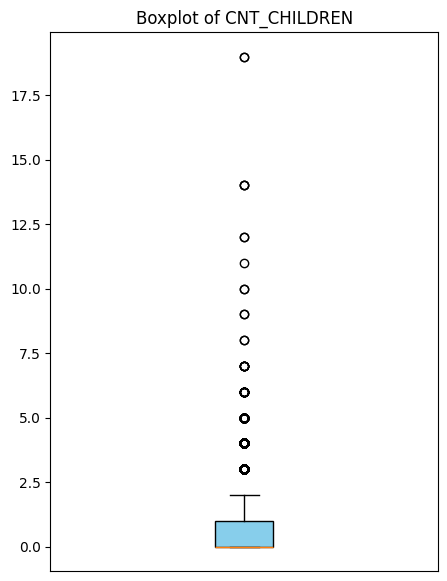

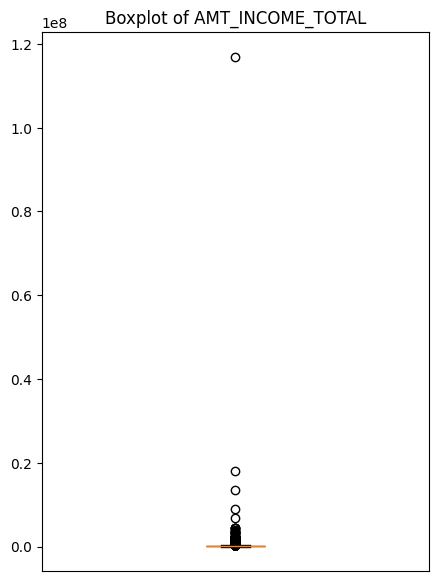

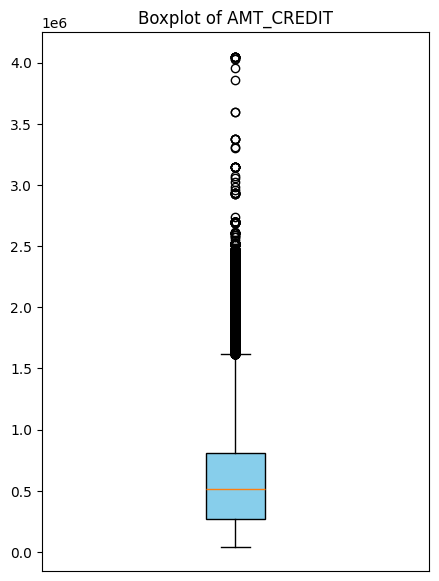

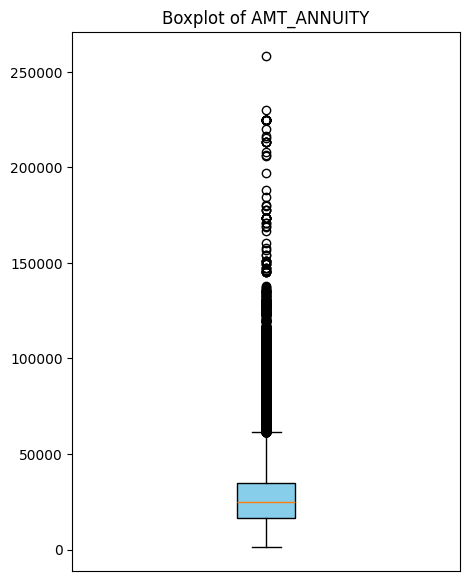

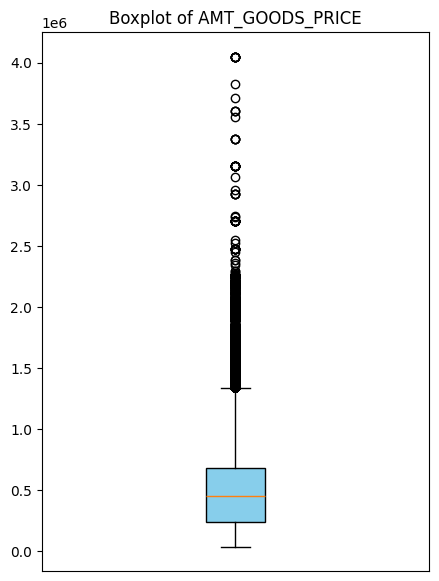

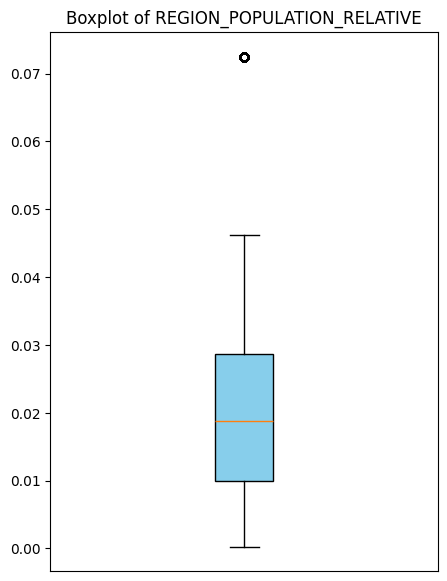

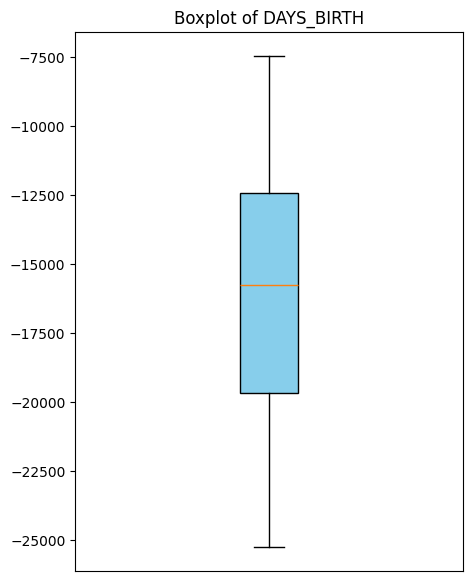

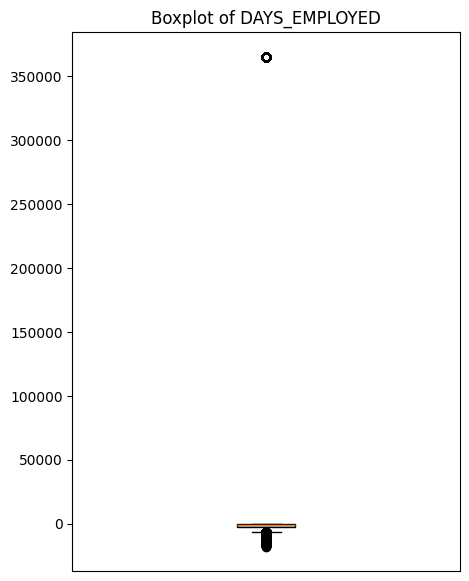

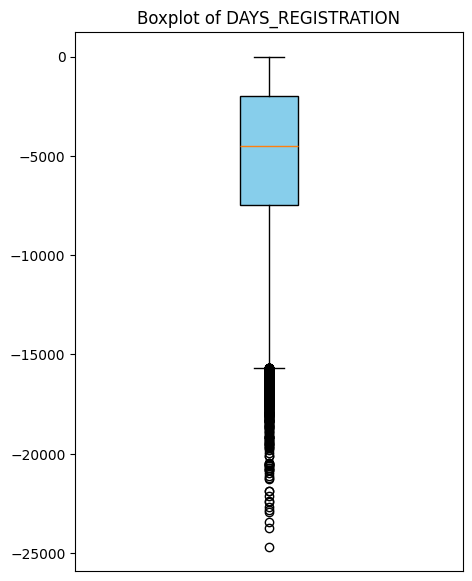

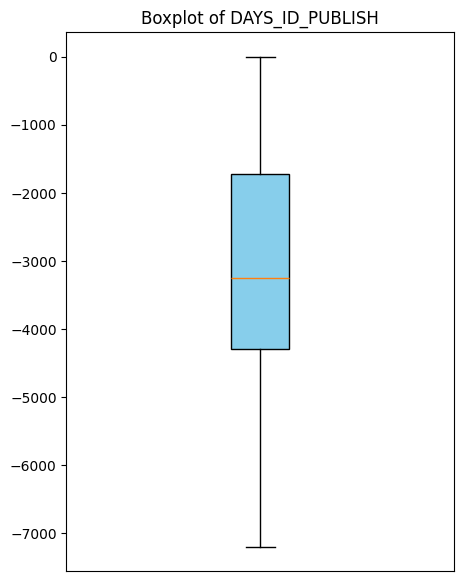

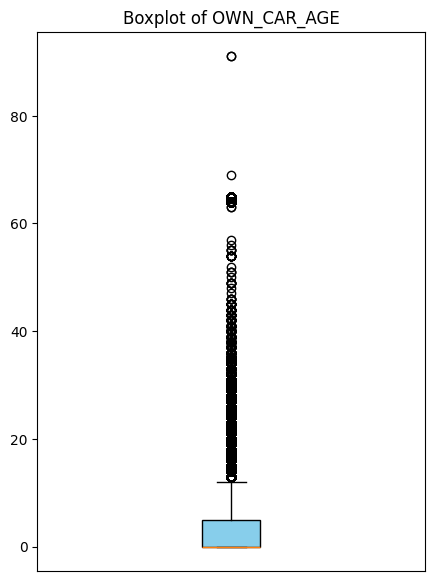

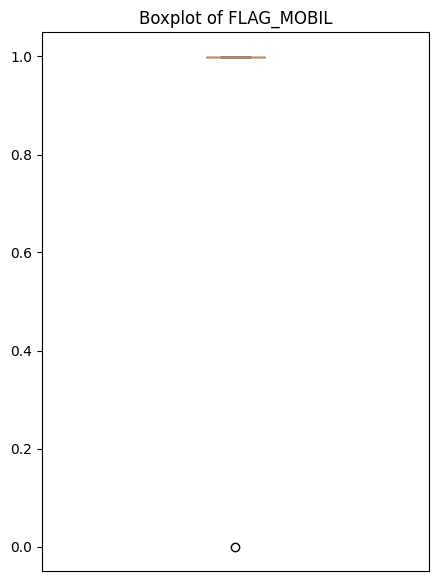

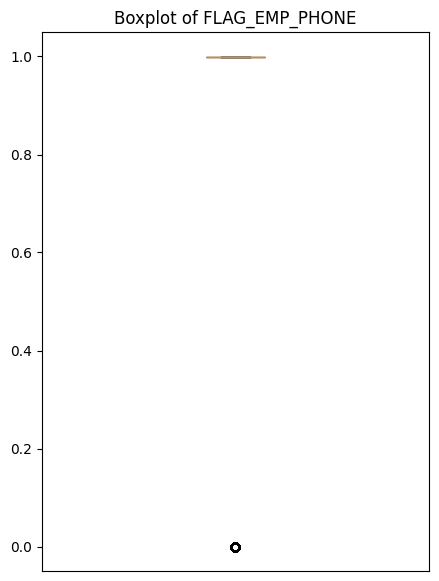

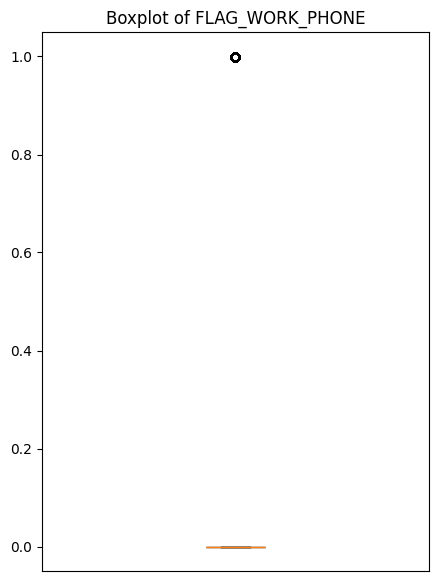

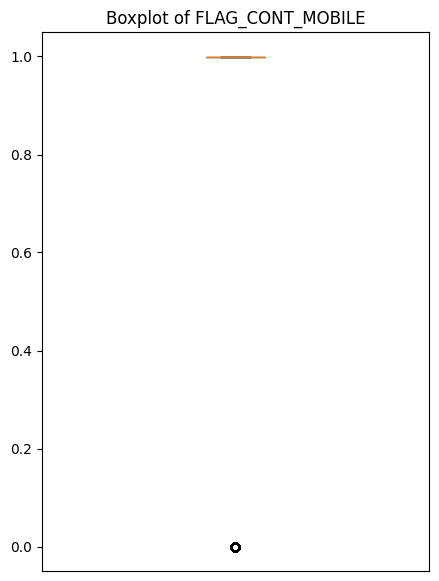

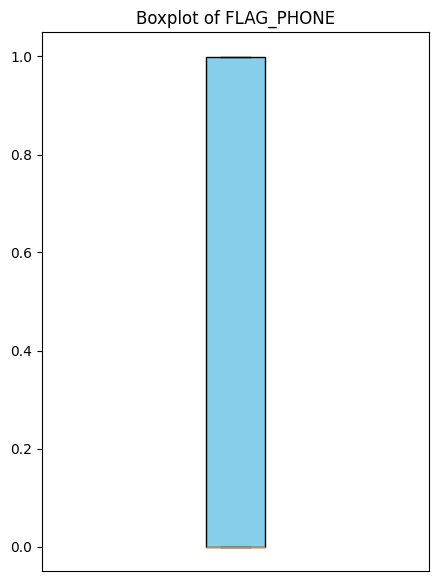

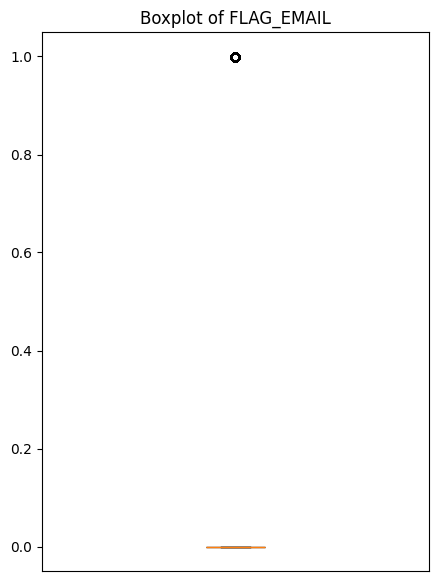

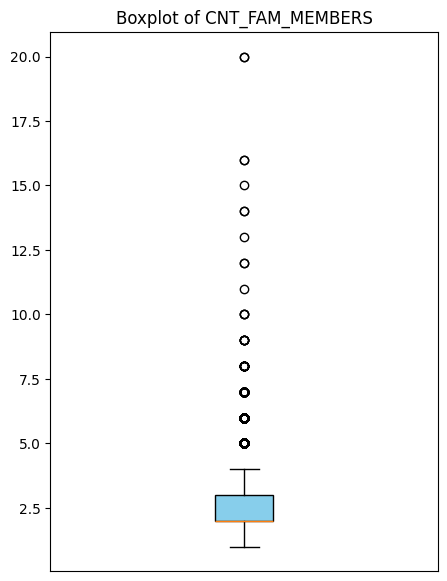

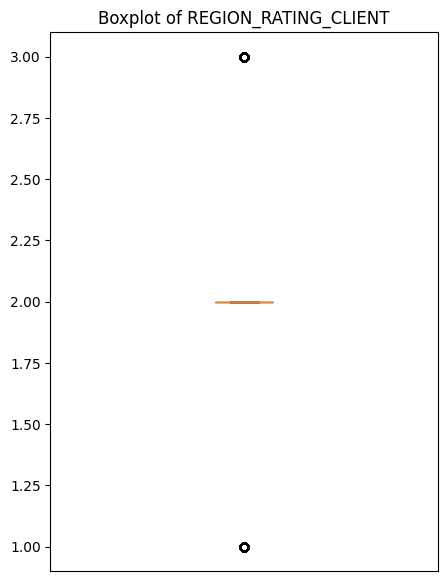

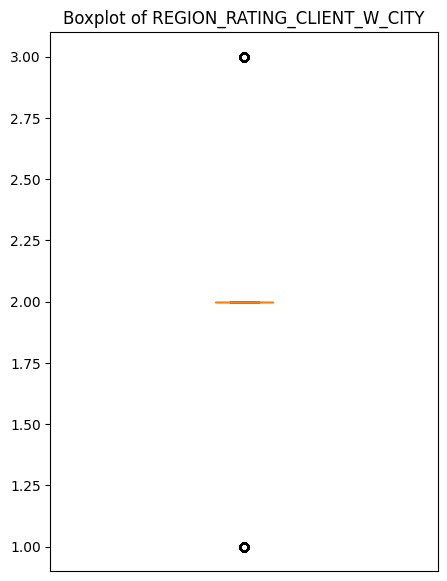

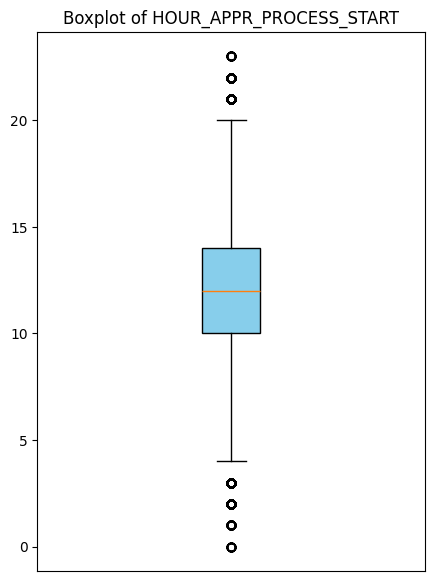

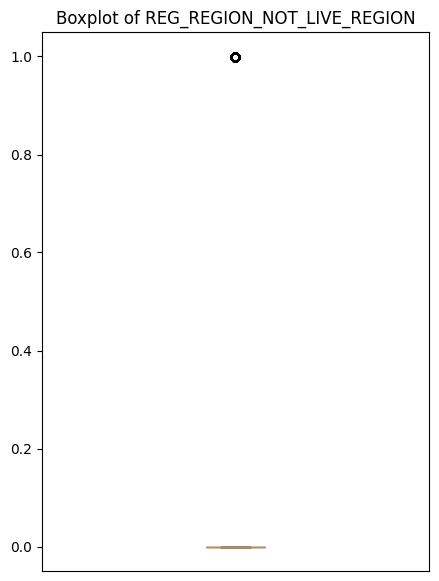

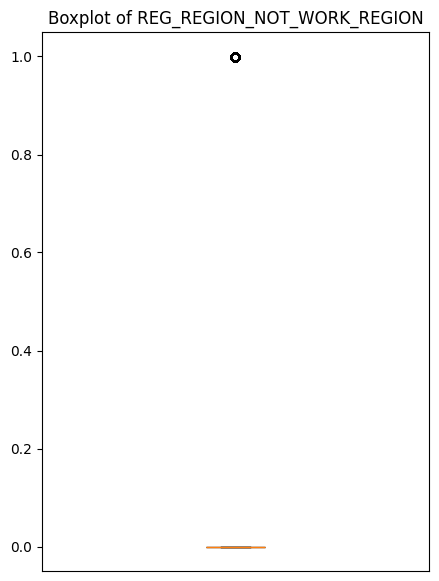

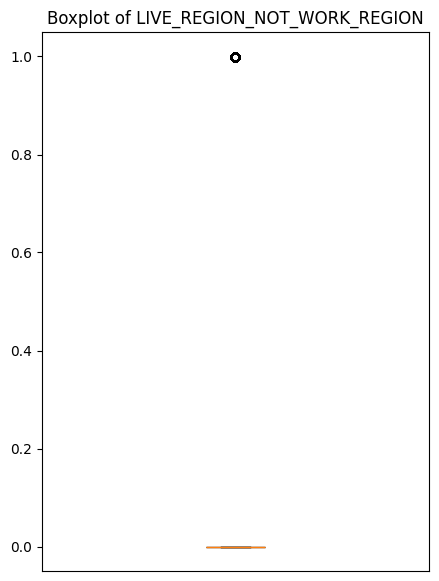

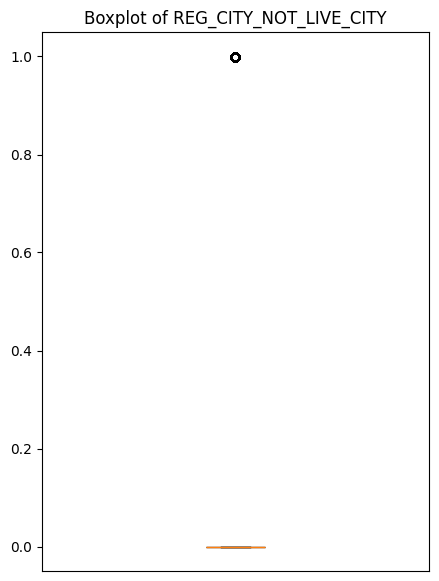

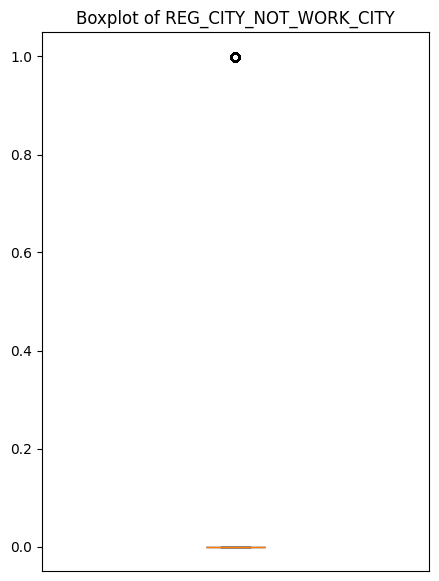

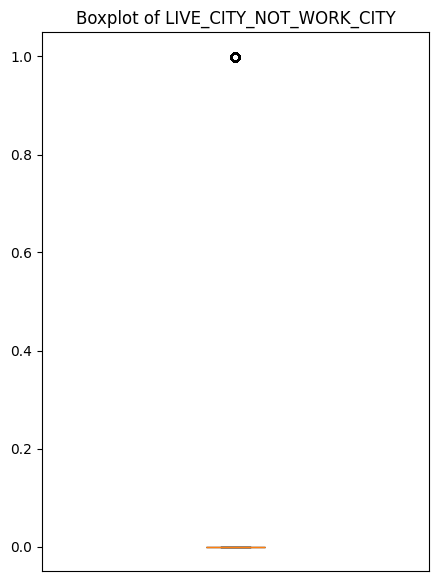

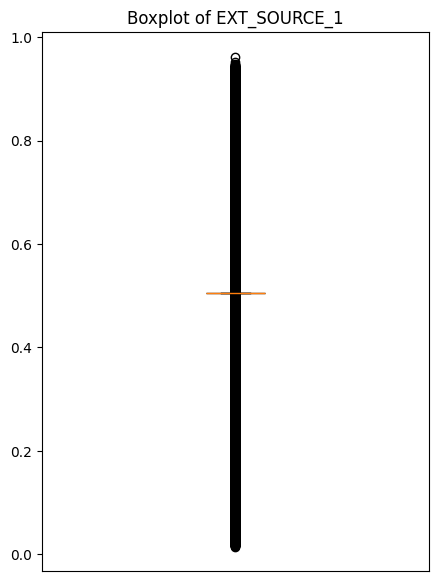

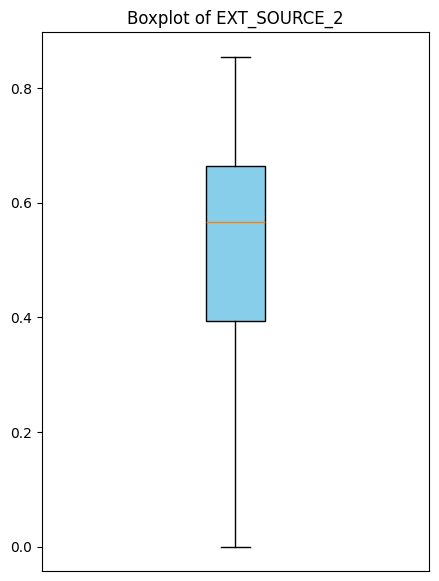

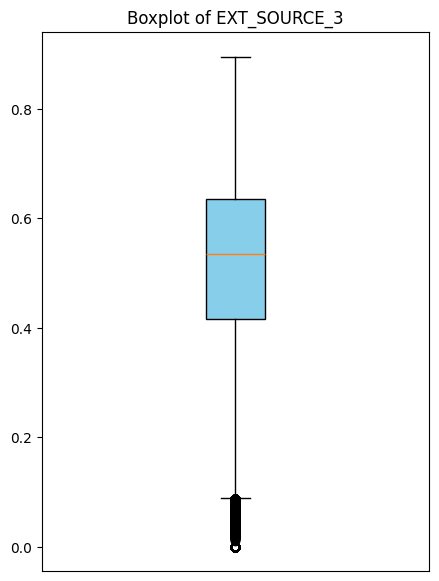

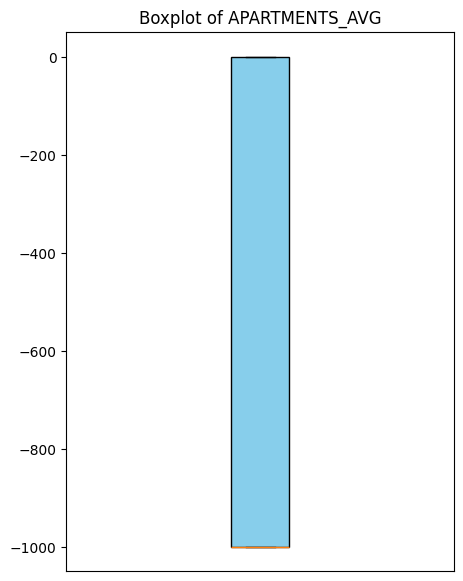

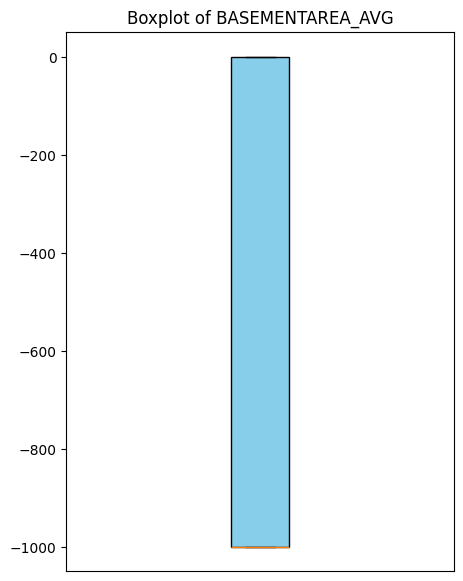

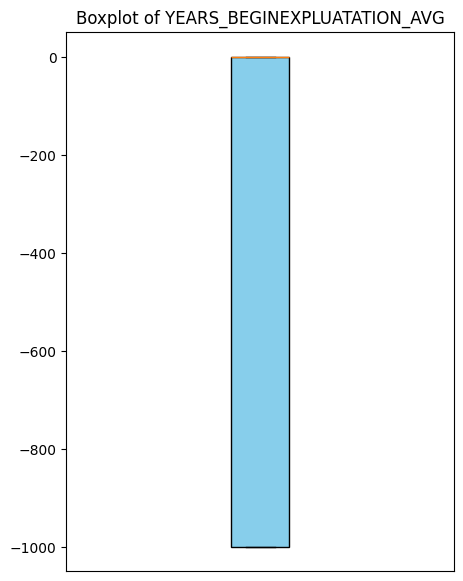

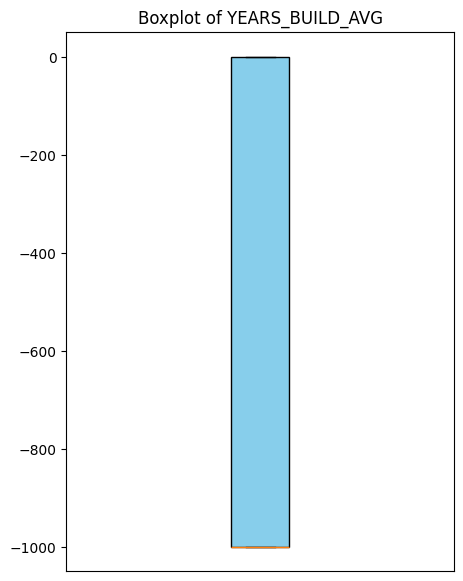

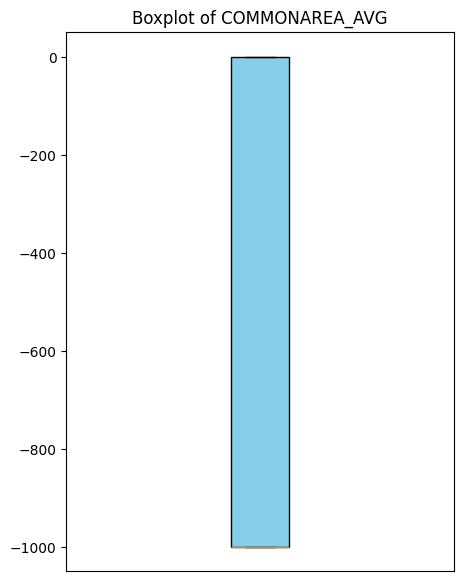

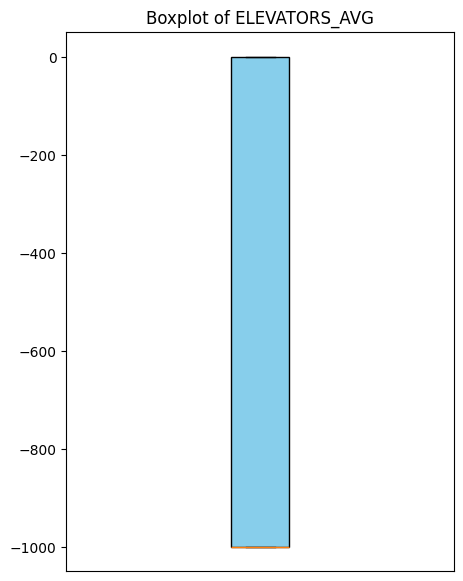

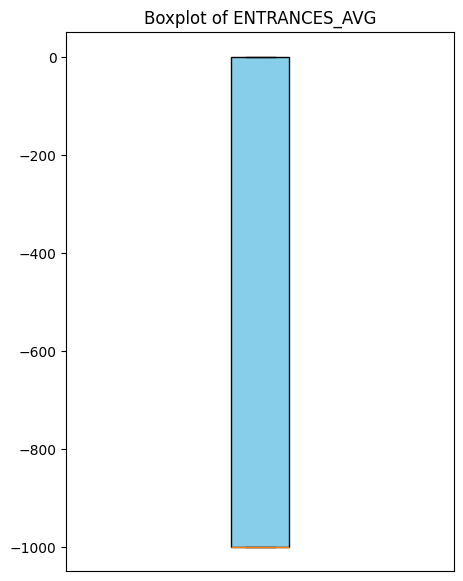

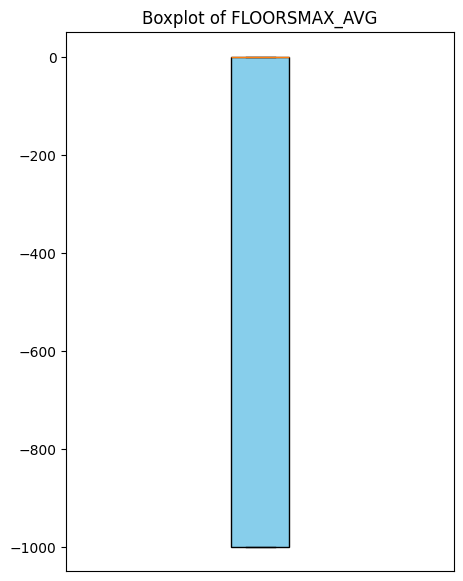

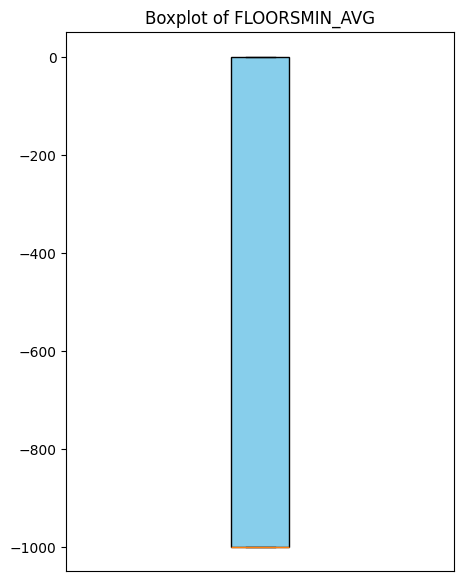

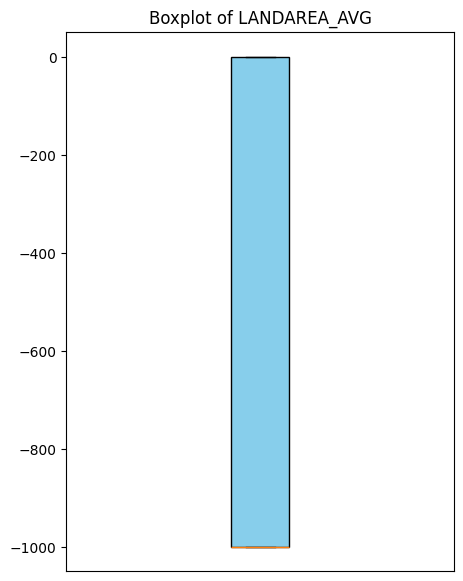

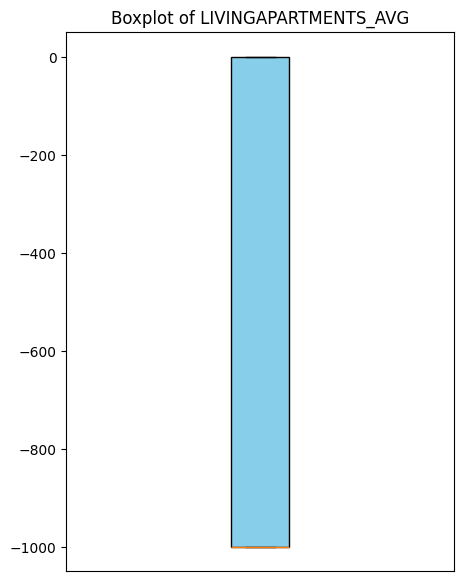

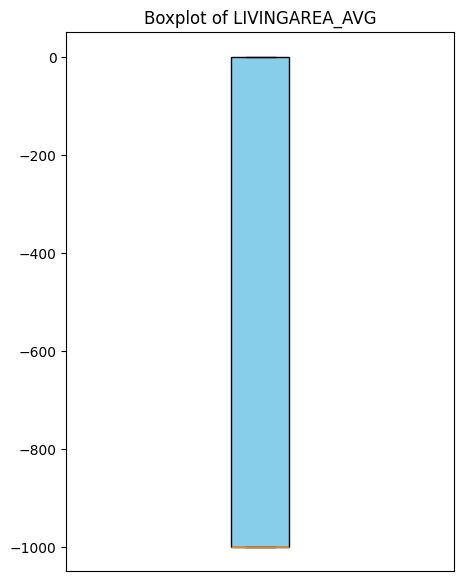

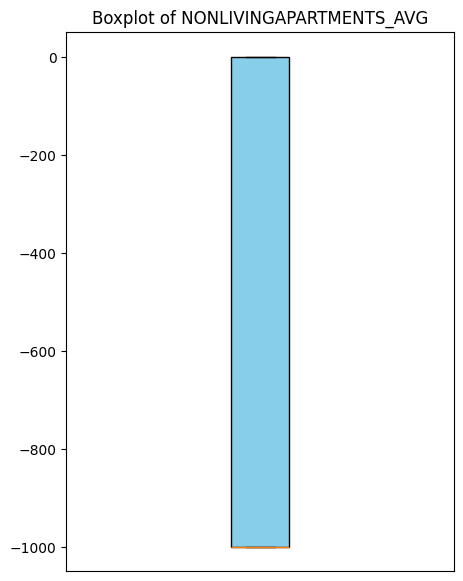

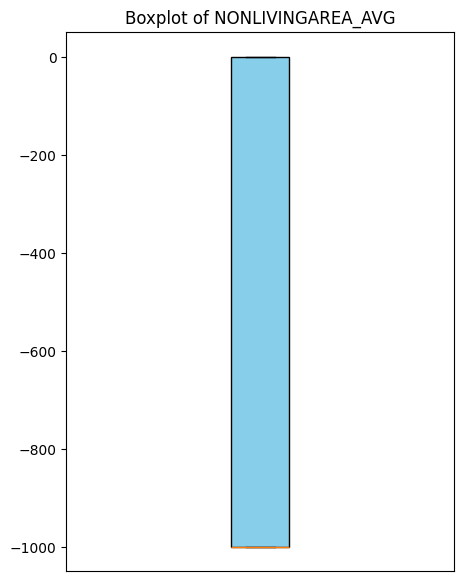

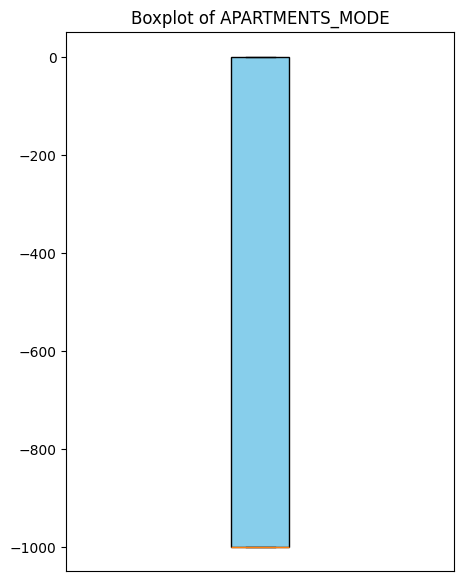

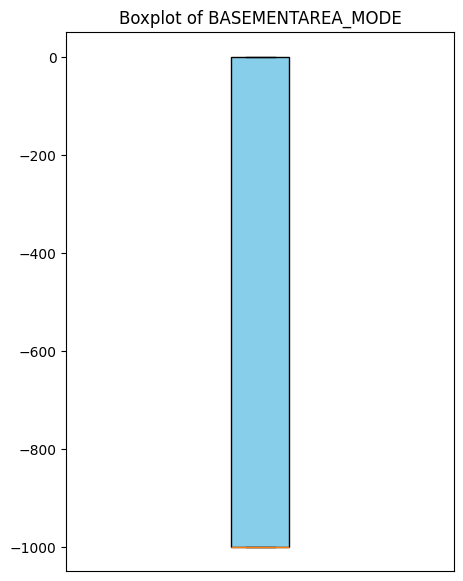

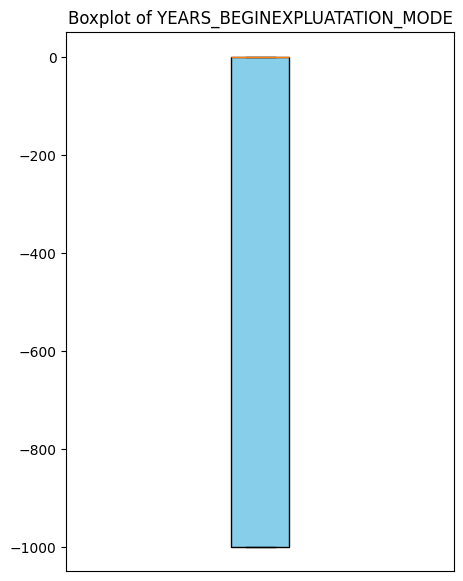

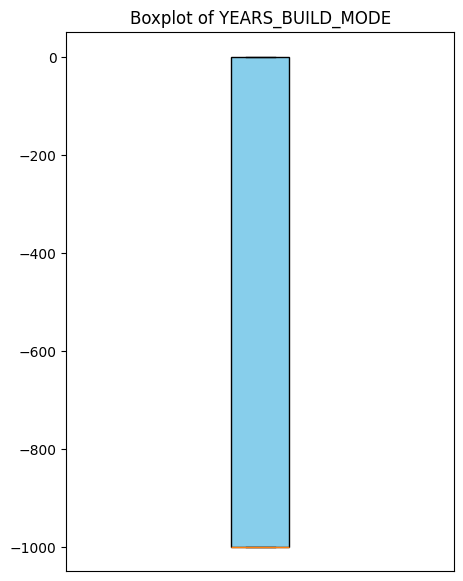

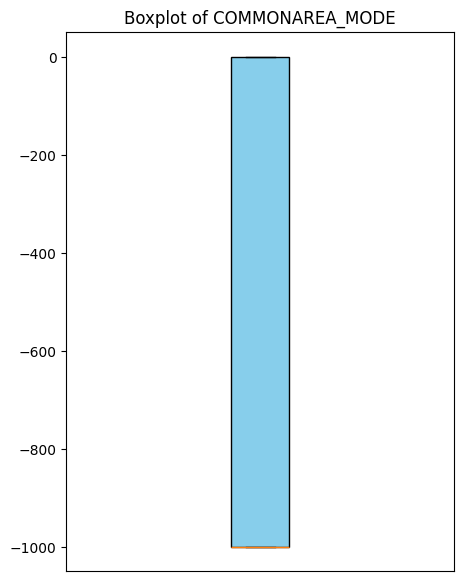

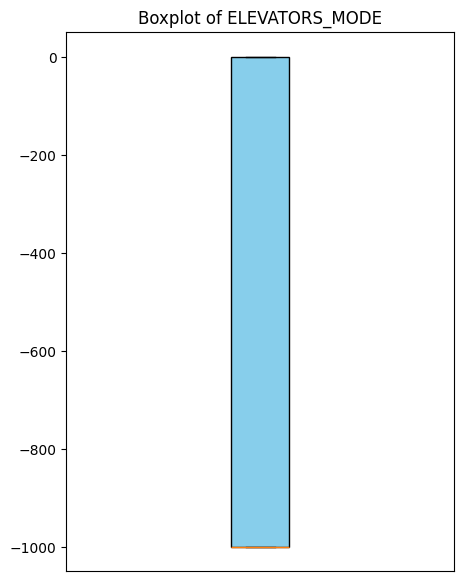

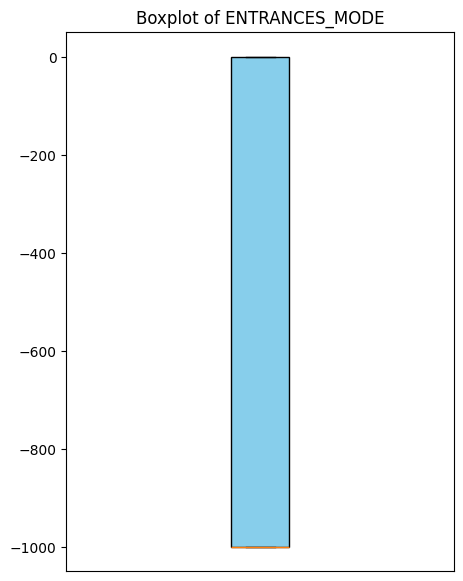

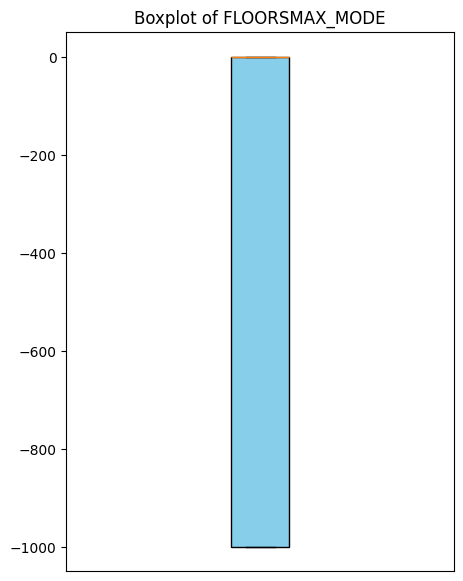

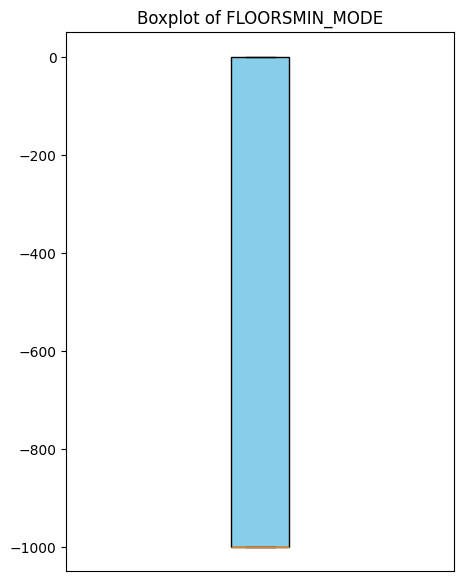

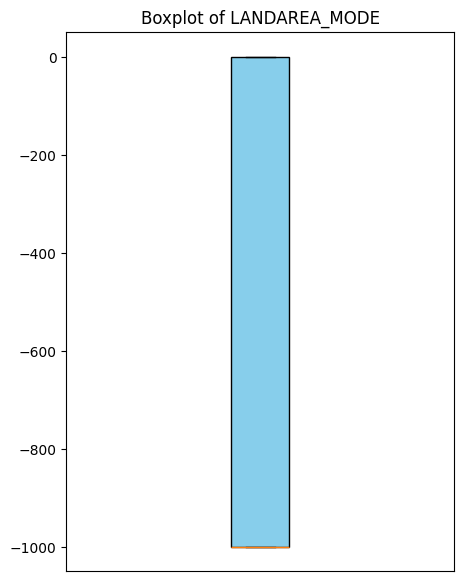

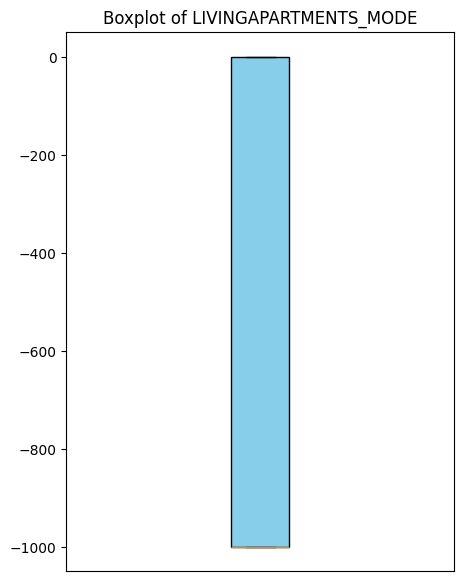

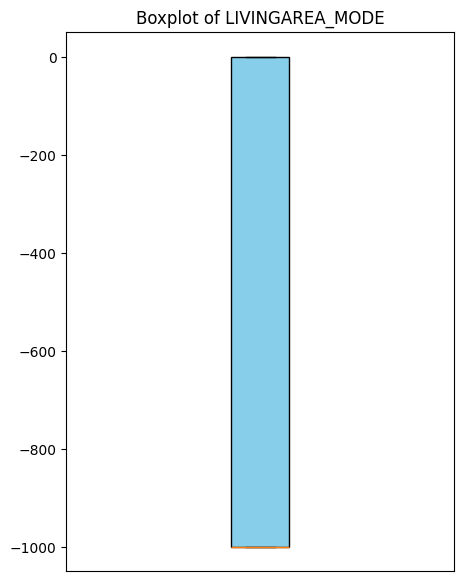

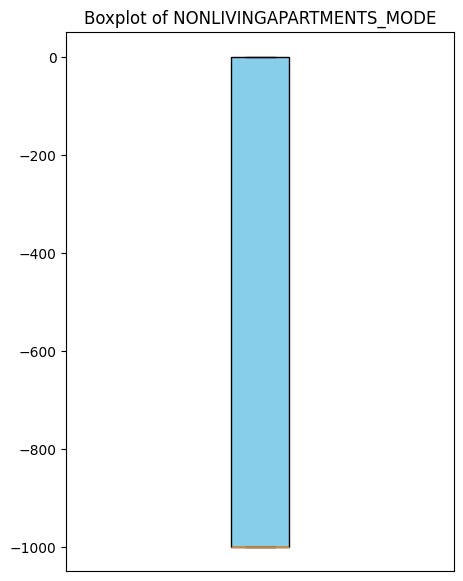

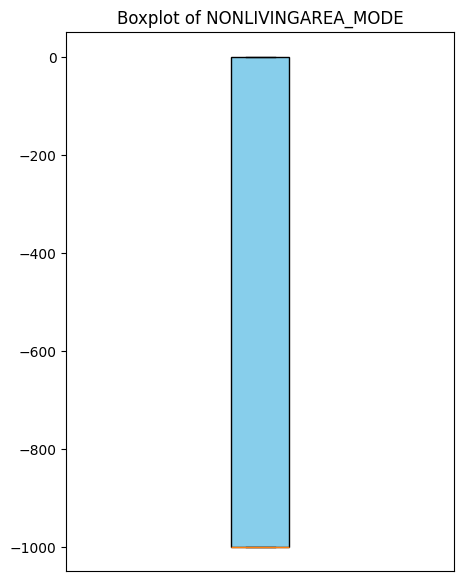

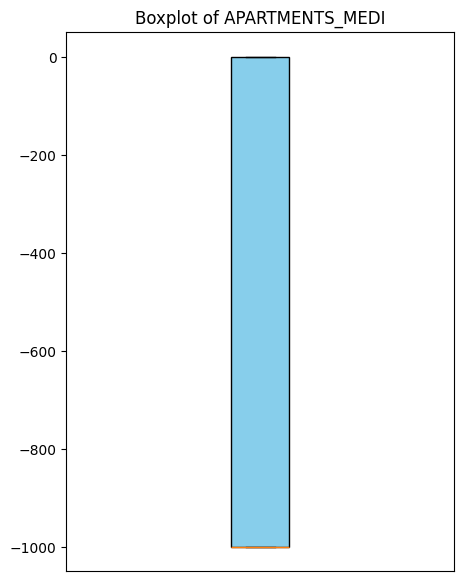

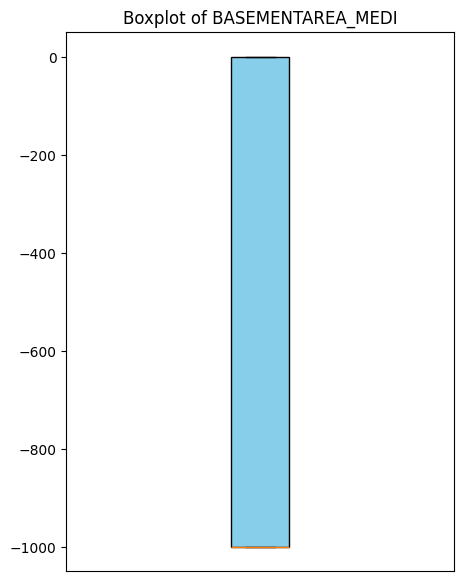

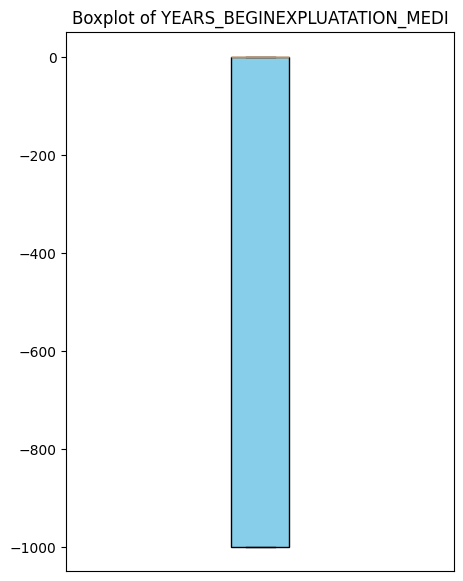

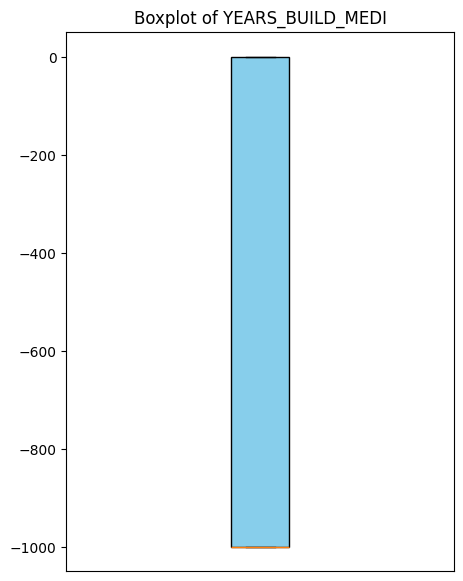

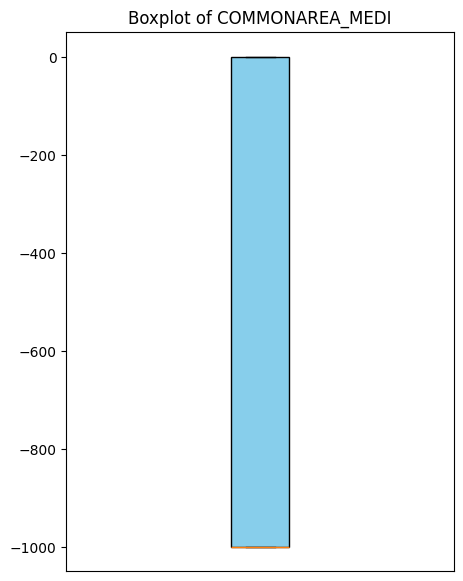

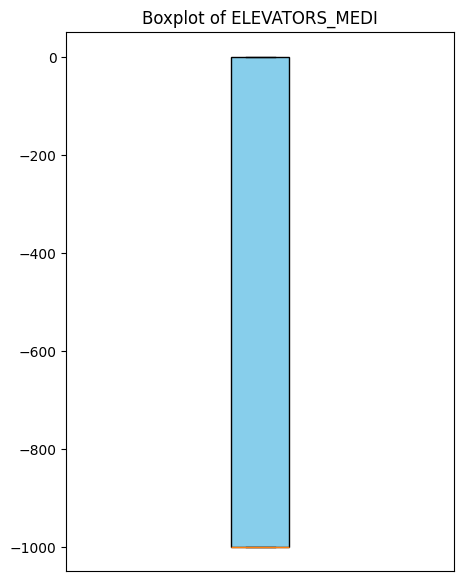

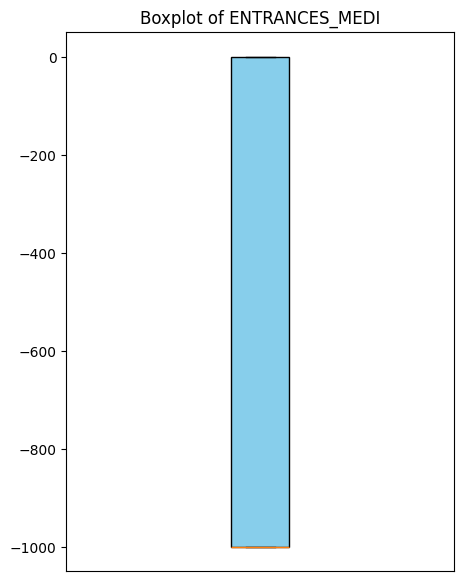

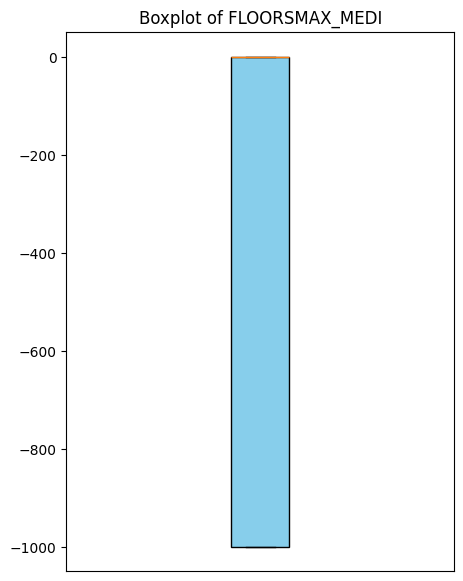

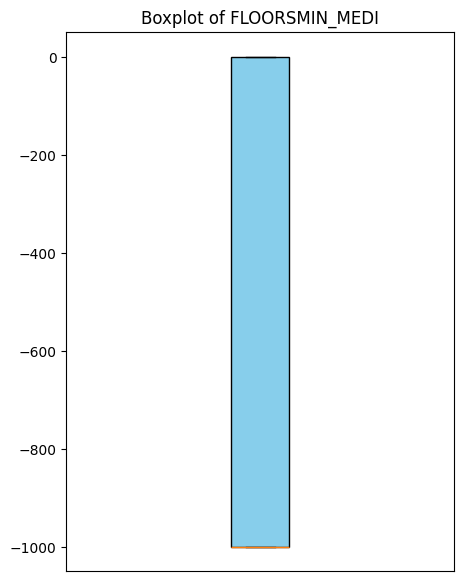

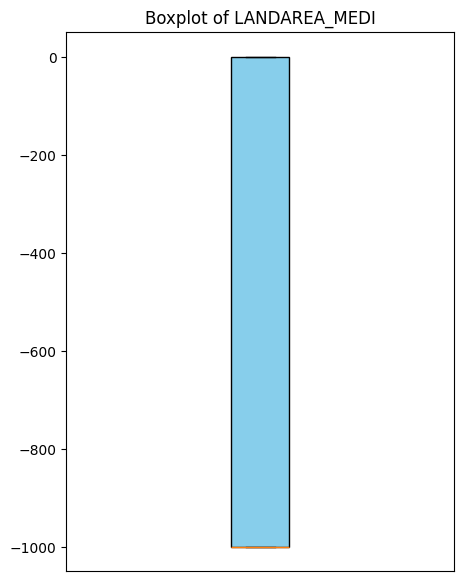

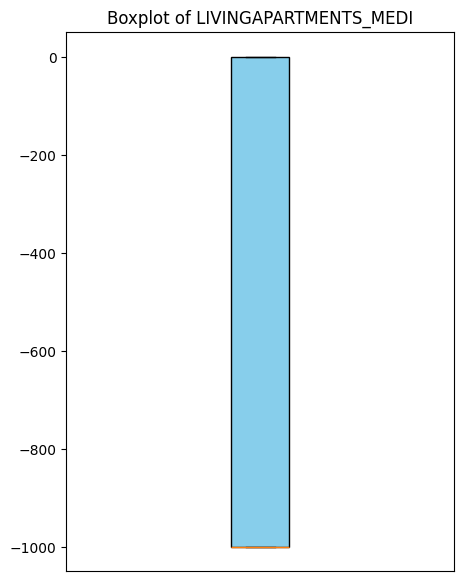

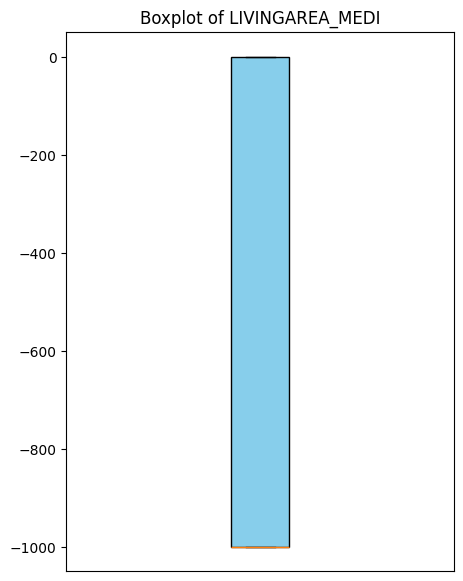

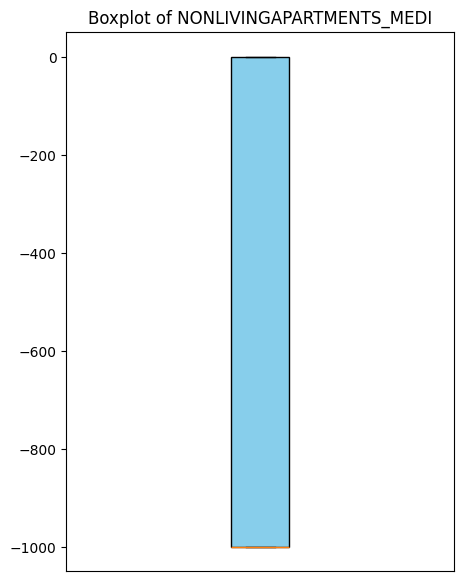

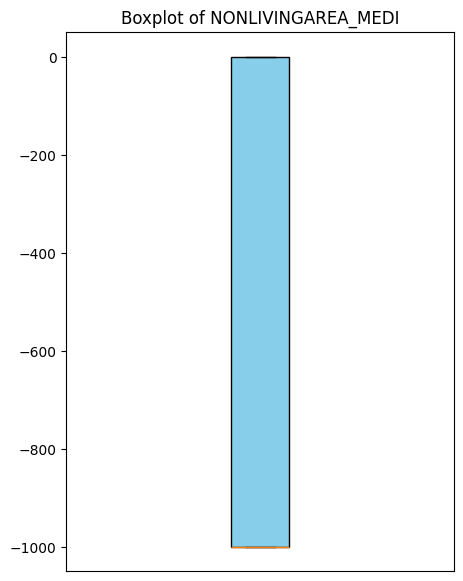

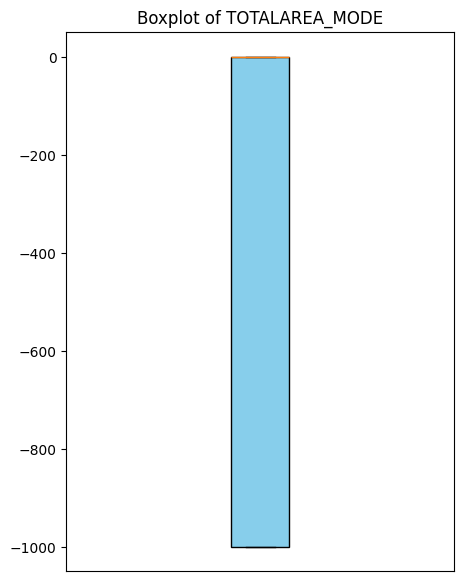

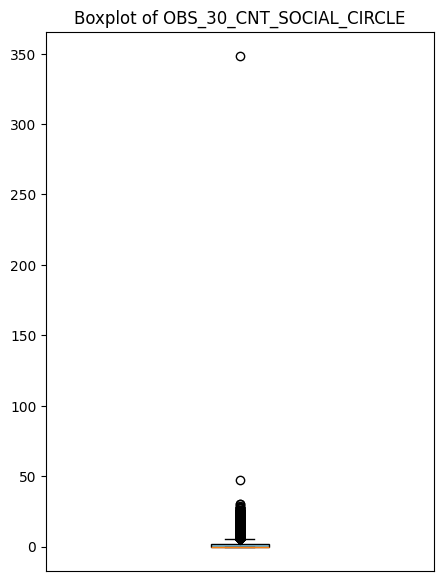

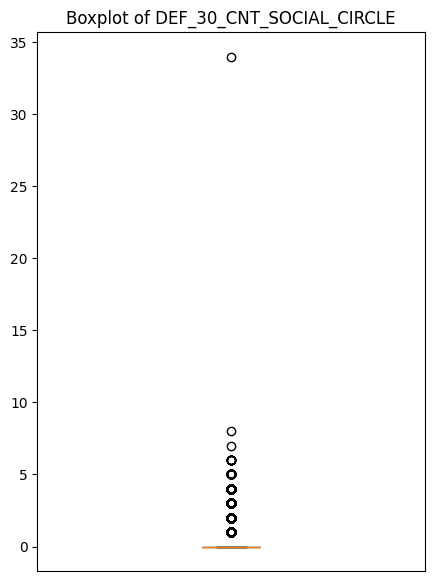

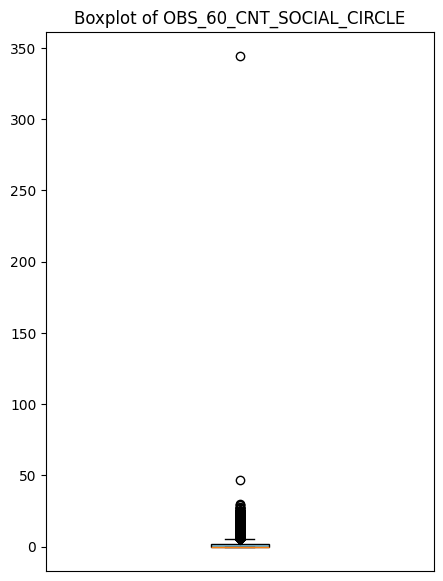

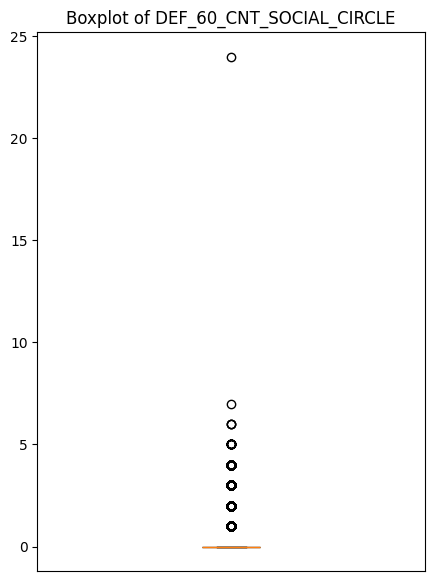

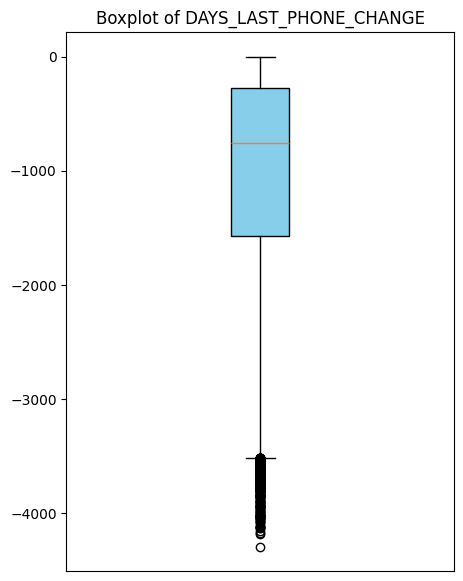

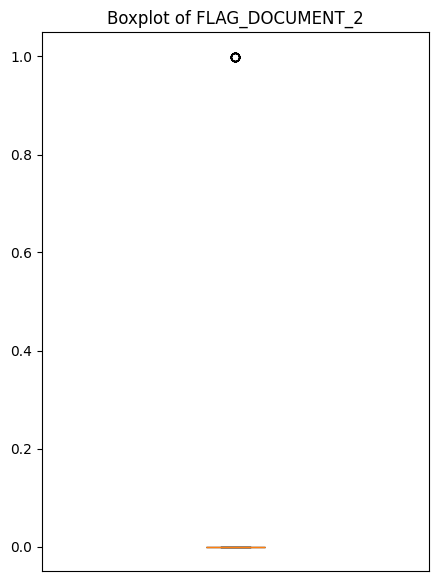

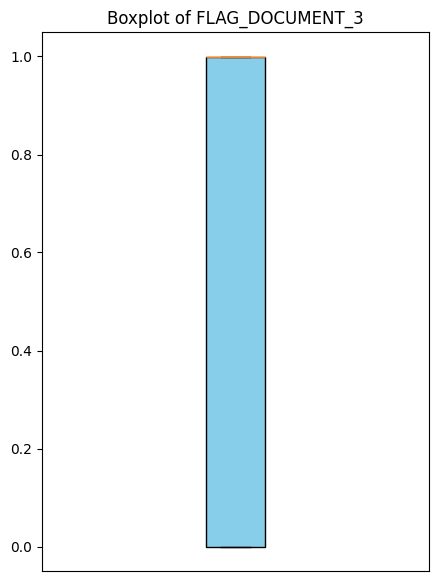

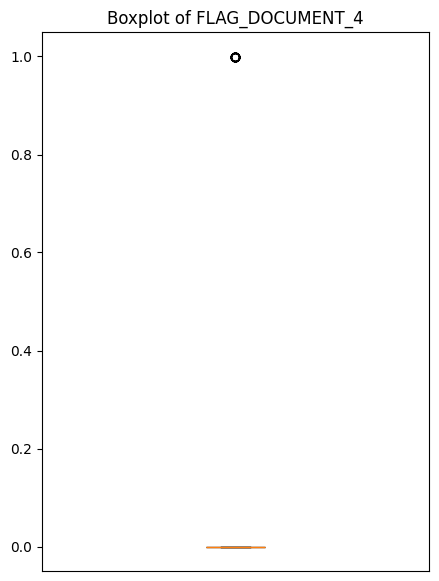

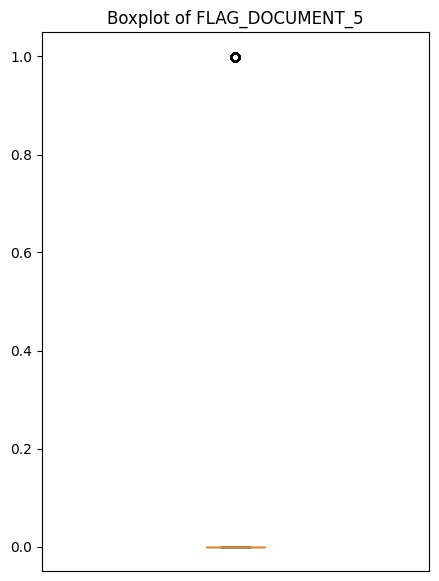

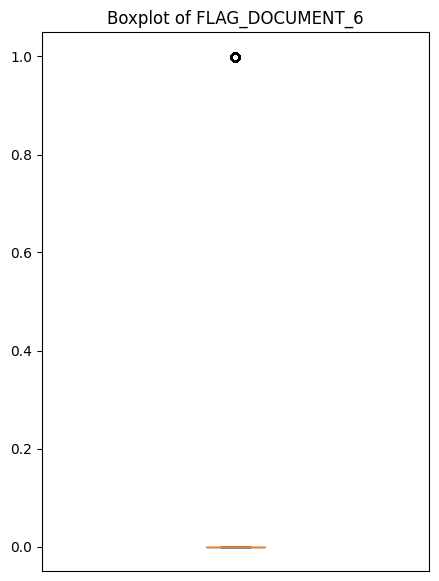

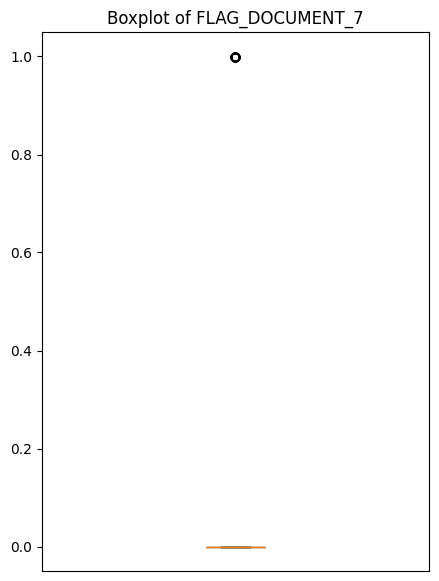

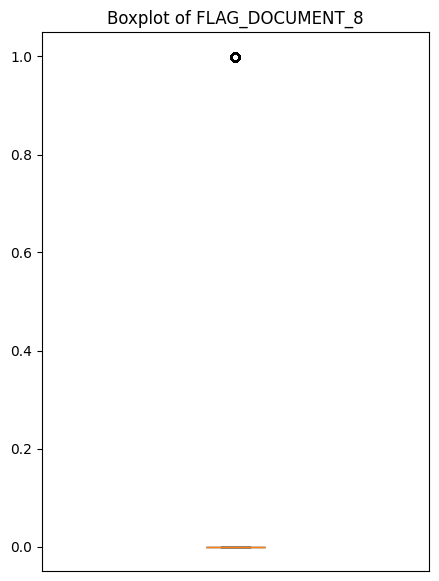

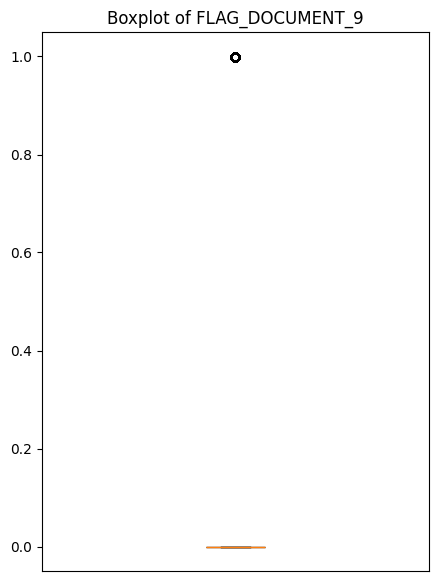

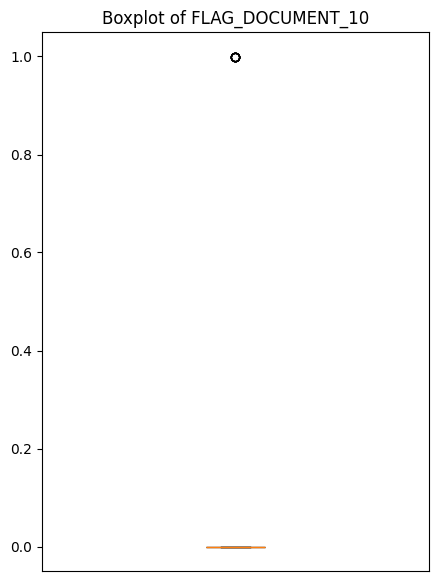

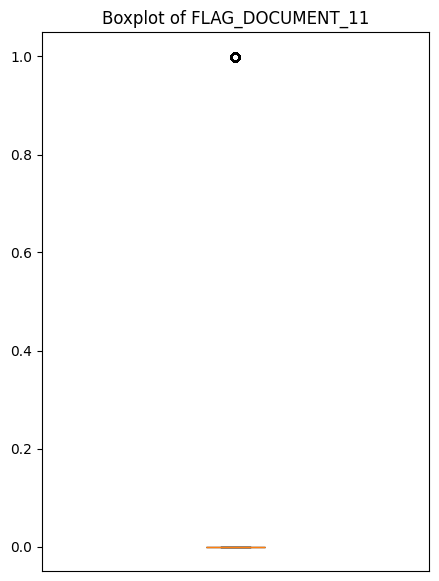

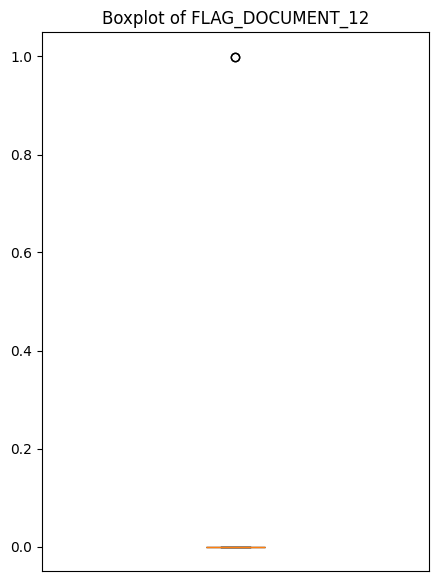

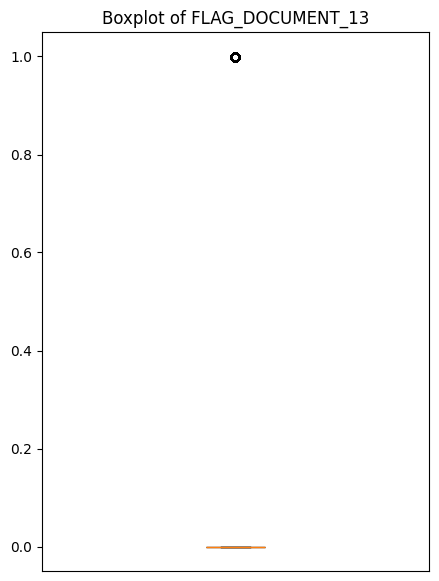

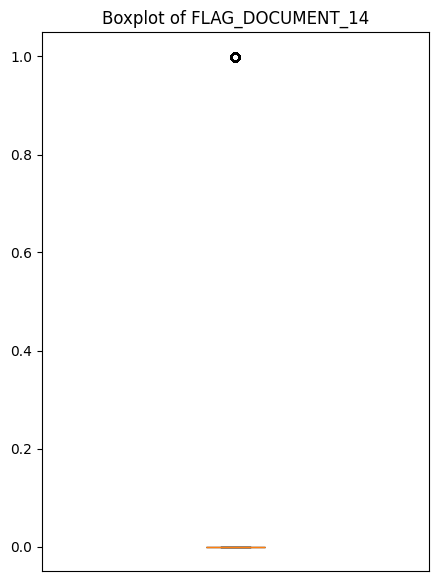

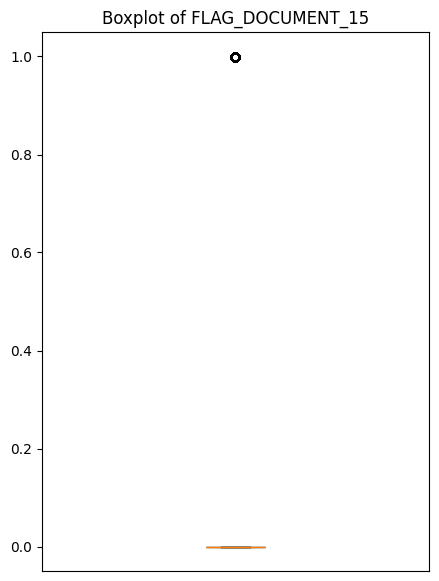

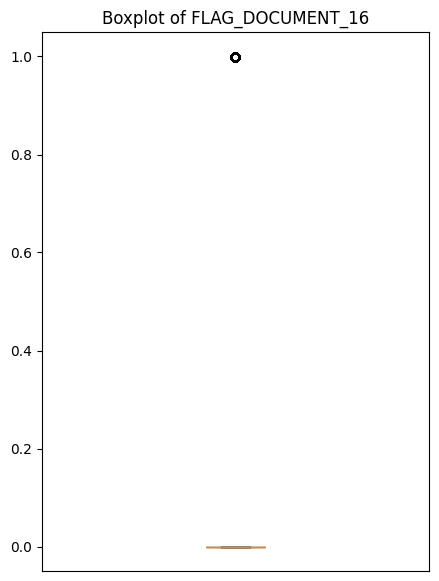

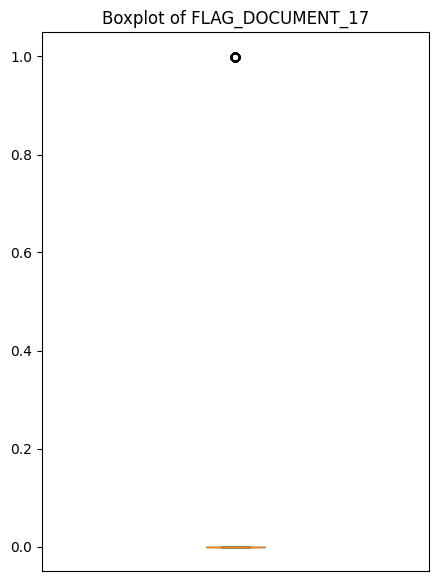

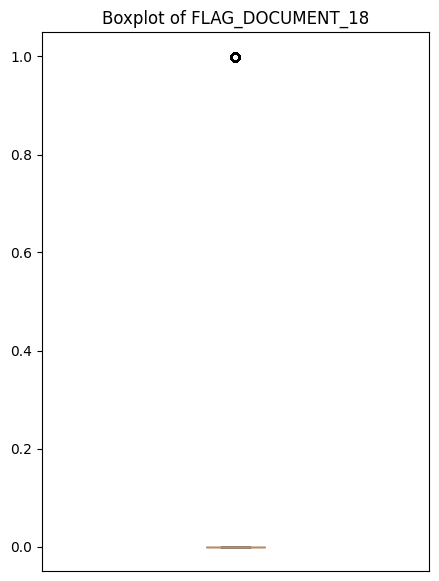

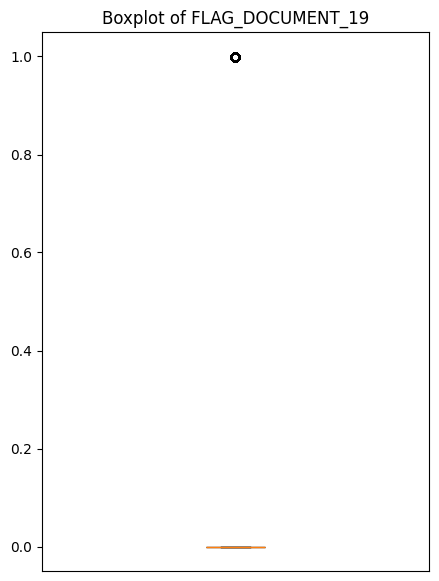

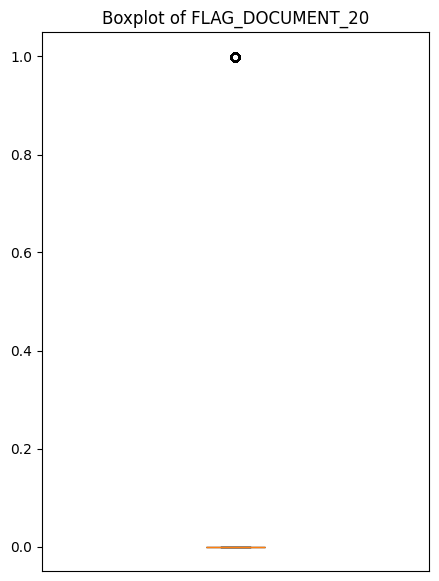

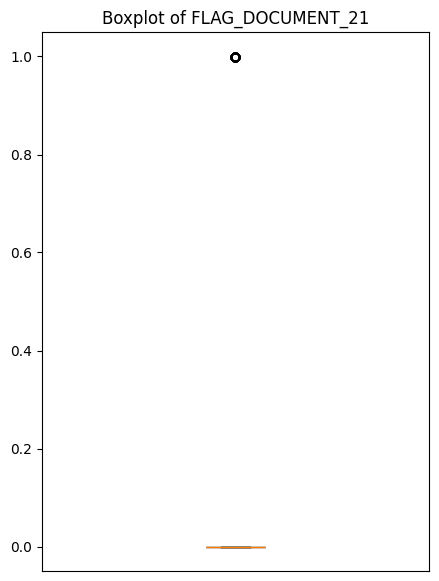

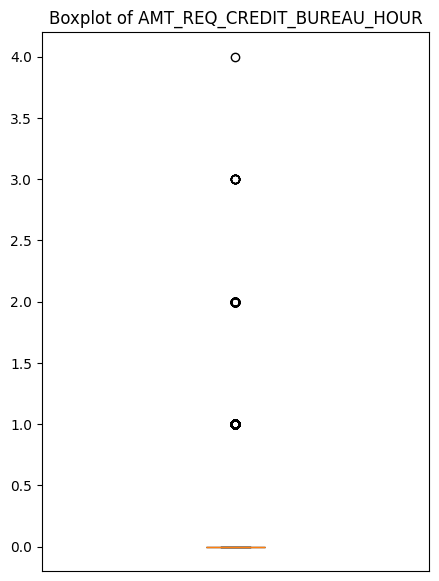

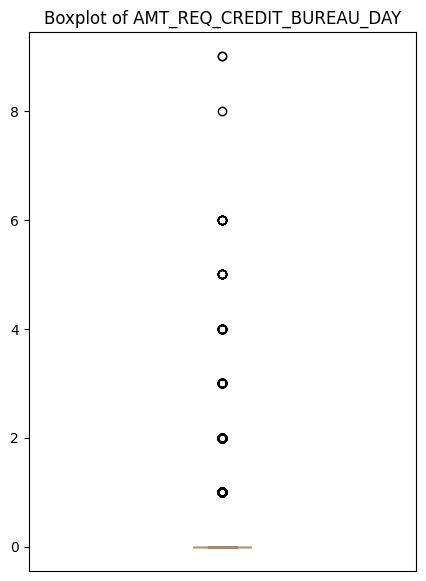

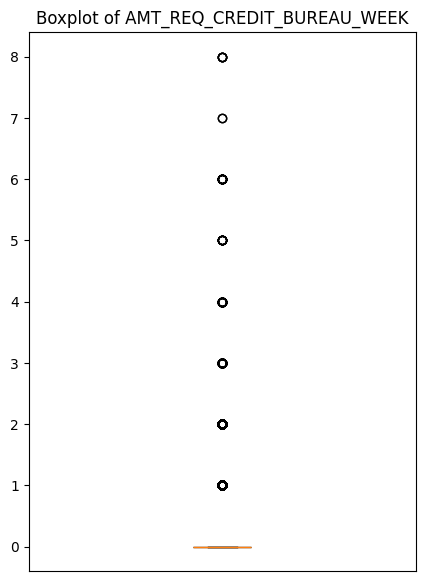

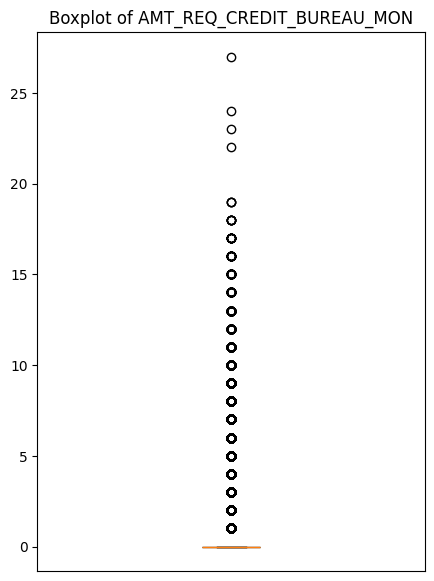

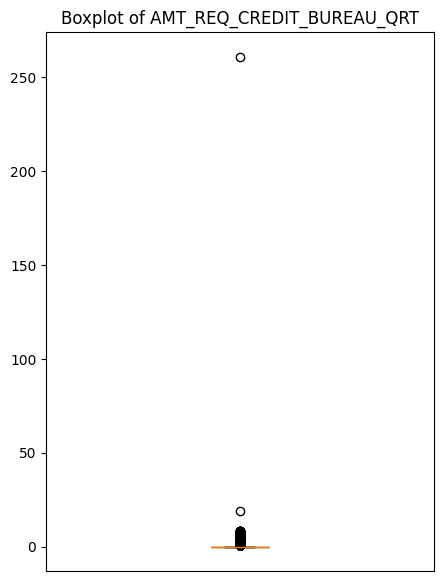

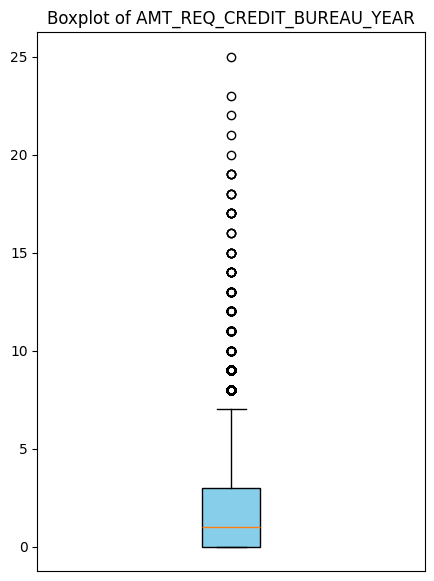

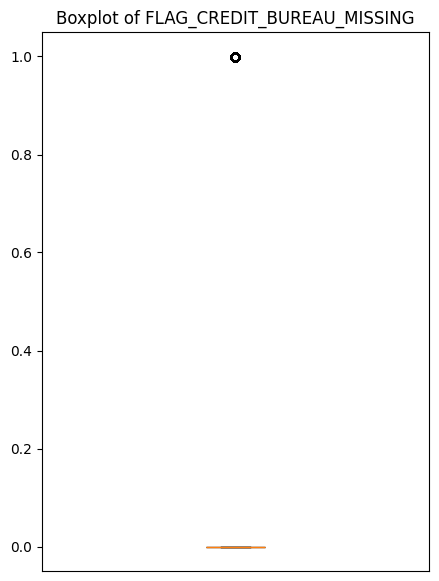

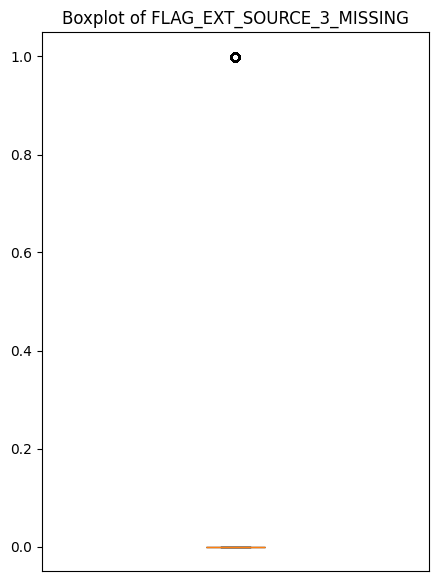

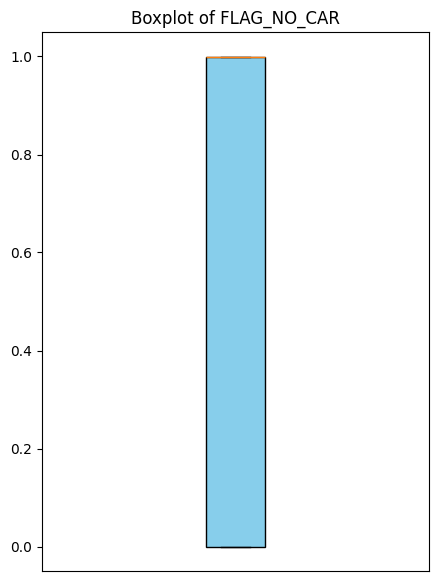

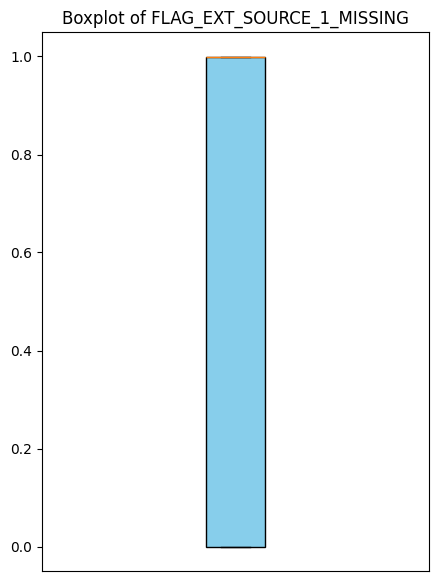

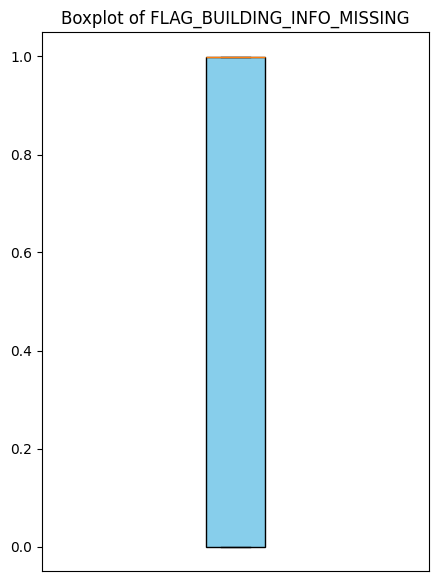

In [98]:
# Get only float-type columns
float_features = train.select_dtypes(include=['number']).columns

# Create individual boxplots
for feature in float_features:
    plt.figure(figsize=(5, 7))
    plt.boxplot(train[feature].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="skyblue"))
    plt.title(f"Boxplot of {feature}")
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks([])
    plt.show()

In [99]:
float_features = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_EMPLOYED",
    "OWN_CAR_AGE",
    "CNT_FAM_MEMBERS",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_QRT"
]

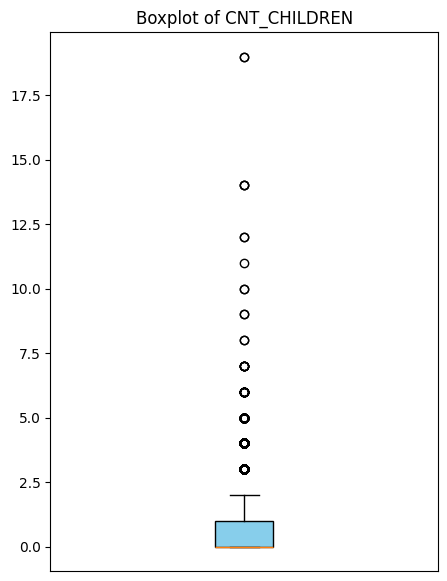

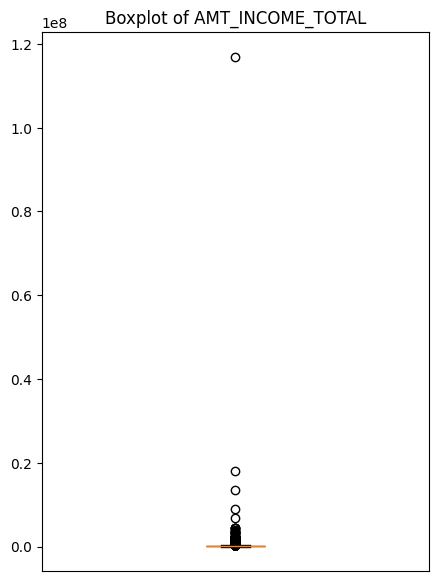

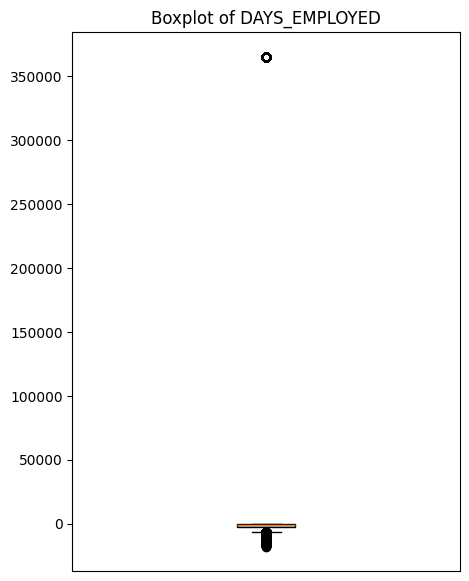

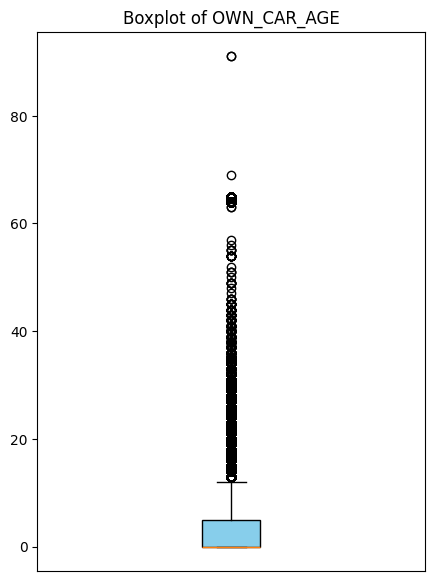

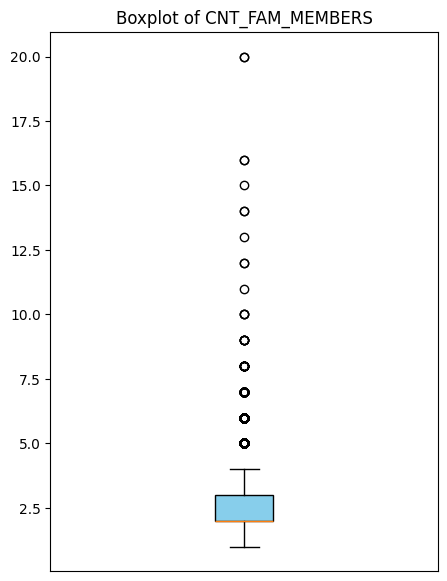

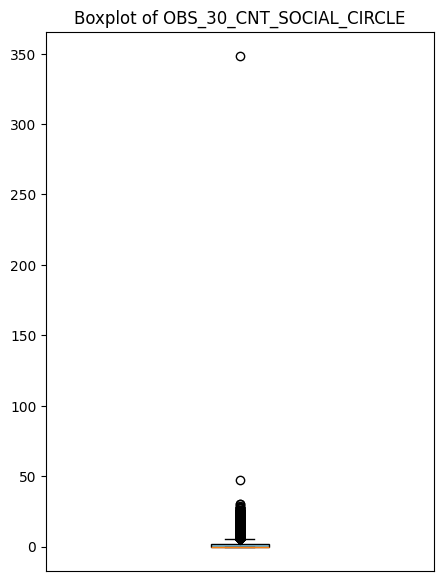

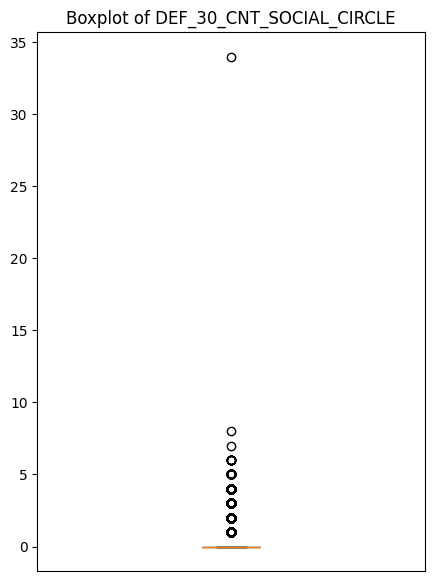

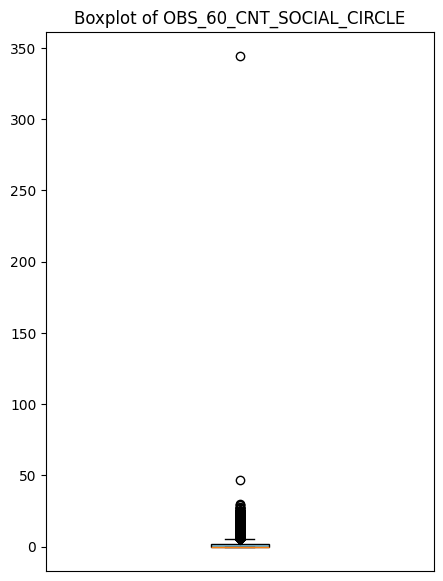

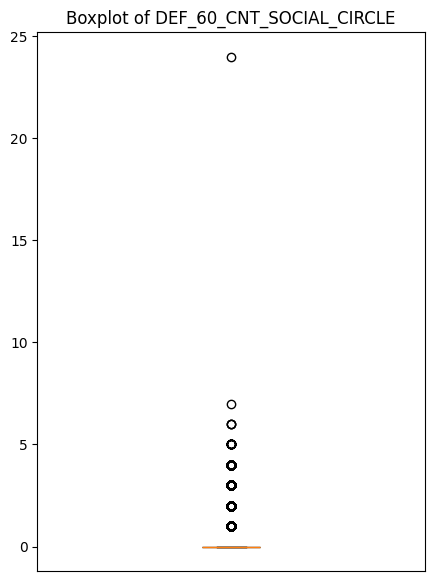

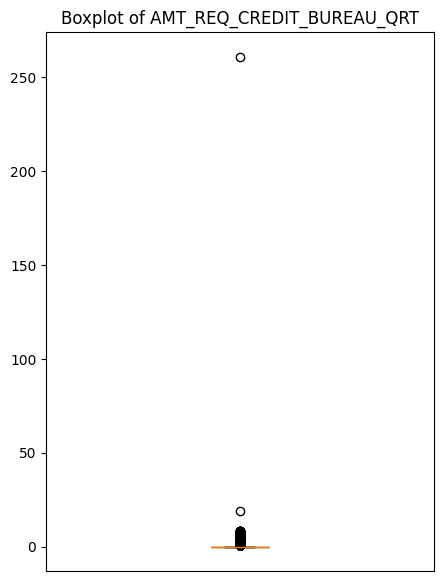

In [100]:
# Create individual boxplots
for feature in float_features:
    plt.figure(figsize=(5, 7))
    plt.boxplot(train[feature].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="skyblue"))
    plt.title(f"Boxplot of {feature}")
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks([])
    plt.show()

### AMT_INCOME_TOTAL

Currency &rightarrow; HUF (Hungarian Forint)

In [101]:
df.describe()['AMT_INCOME_TOTAL'].loc[['mean', 'min', '25%', '50%', '75%', 'max']]

mean      170116.060
min        25650.000
25%       112500.000
50%       153000.000
75%       202500.000
max    117000000.000
Name: AMT_INCOME_TOTAL, dtype: float64

In [102]:
train[train["AMT_INCOME_TOTAL"] > 0.3e8]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING
12840,114967,1,Cash loans,F,N,Y,1,117000000.000,562491.000,26194.500,454500.000,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.011,-12615,-922,-6762.000,-3643,0.000,1,1,0,1,0,0,Laborers,3.000,2,2,TUESDAY,14,0,0,0,0,0,0,Business Entity Type 3,0.461,0.113,0.146,0.103,0.095,0.979,-999.000,-999.000,0.000,0.207,0.167,-999.000,0.069,-999.000,0.061,-999.000,-999.000,0.105,0.098,0.979,-999.000,-999.000,0.000,0.207,0.167,-999.000,0.070,-999.000,0.064,-999.000,-999.000,0.104,0.095,0.979,-999.000,-999.000,0.000,0.207,0.167,-999.000,0.070,-999.000,0.063,-999.000,-999.000,Missing,block of flats,0.071,"Stone, brick",No,0.000,0.000,0.000,0.000,0.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000,0,0,1,0,1


In [103]:
train = train[train["AMT_INCOME_TOTAL"] <= 0.3e8]
test = test[test["AMT_INCOME_TOTAL"] <= 0.3e8]

In [104]:
train[train["AMT_INCOME_TOTAL"] > 0.3e8]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING


### DAYS_EMPLOYED

In [105]:
train[train["DAYS_EMPLOYED"] > 350000][["DAYS_EMPLOYED"]]

,DAYS_EMPLOYED
8,365243
11,365243
23,365243
38,365243
43,365243
...,...
307469,365243
307483,365243
307487,365243
307505,365243


In [106]:
# Create a flag for unemployed/retired/pensioner
train['FLAG_UNEMPLOYED'] = (train['DAYS_EMPLOYED'] == 365243).astype(int)
test['FLAG_UNEMPLOYED'] = (test['DAYS_EMPLOYED'] == 365243).astype(int)
df['FLAG_UNEMPLOYED'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

#### YEARS_EMPLOYED

In [107]:
# Convert days to years (negative → employed, NaN → unemployed)
train['YEARS_EMPLOYED'] = -train['DAYS_EMPLOYED'] / 365  # Negative because days are backwards
test['YEARS_EMPLOYED'] = -test['DAYS_EMPLOYED'] / 365  # Negative because days are backwards
df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365  # Negative because days are backwards

#### Employment Status Categories

In [108]:
# ===== Employment Status Binning =====

# TRAIN
conditions = [
    train['DAYS_EMPLOYED'] == 365243,   # Unemployed
    train['DAYS_EMPLOYED'] < -3650,     # Employed >10 years
    train['DAYS_EMPLOYED'] < -730,      # Employed 2–10 years
    train['DAYS_EMPLOYED'] < 0          # Employed <2 years
]
labels = ['Unemployed', 'Long_Term', 'Mid_Term', 'Short_Term']
train['EMPLOYMENT_STATUS'] = np.select(conditions, labels, default='Unknown')

# TEST
conditions = [
    test['DAYS_EMPLOYED'] == 365243,
    test['DAYS_EMPLOYED'] < -3650,
    test['DAYS_EMPLOYED'] < -730,
    test['DAYS_EMPLOYED'] < 0
]
test['EMPLOYMENT_STATUS'] = np.select(conditions, labels, default='Unknown')

# df
conditions = [
    df['DAYS_EMPLOYED'] == 365243,
    df['DAYS_EMPLOYED'] < -3650,
    df['DAYS_EMPLOYED'] < -730,
    df['DAYS_EMPLOYED'] < 0
]
df['EMPLOYMENT_STATUS'] = np.select(conditions, labels, default='Unknown')

### AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE

In [109]:
float_features = [
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

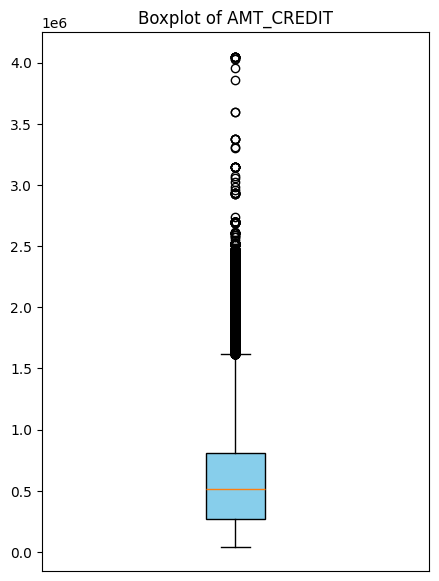

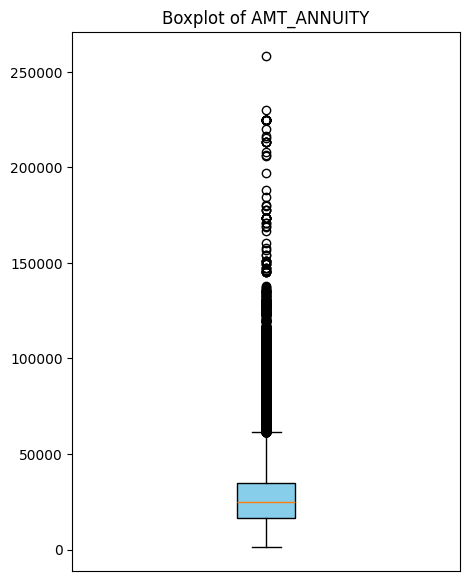

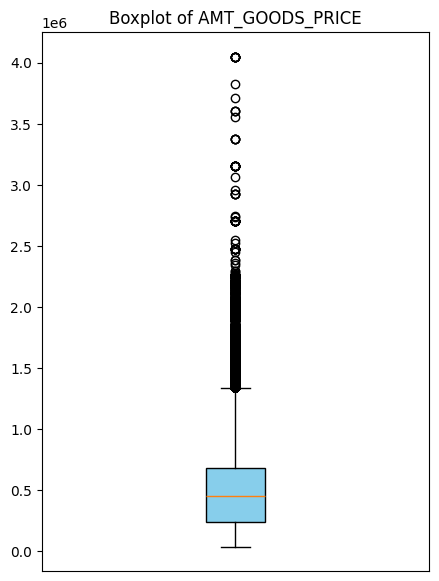

In [110]:
# Create individual boxplots
for feature in float_features:
    plt.figure(figsize=(5, 7))
    plt.boxplot(train[feature].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="skyblue"))
    plt.title(f"Boxplot of {feature}")
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks([])
    plt.show()

In [111]:
df.describe()[['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']].loc[['mean', 'min', 'max']]

,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
mean,587767.414,27425.561,528019.998
min,45000.000,1615.500,40500.000
max,4050000.000,258025.500,4050000.000


In [112]:
train.describe()[['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']].loc[['mean', 'min', 'max']]

,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
mean,599028.212,27108.512,538316.884
min,45000.000,1615.500,40500.000
max,4050000.000,258025.500,4050000.000


**Rule 1: AMT_ANNUITY should not exceed AMT_CREDIT**

In [113]:
train[train['AMT_ANNUITY'] > train['AMT_CREDIT']]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS


**Rule 2: AMT_GOODS_PRICE should not exceed AMT_CREDIT**

In [114]:
train[train['AMT_GOODS_PRICE'] > train['AMT_CREDIT']]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS
724,100837,0,Revolving loans,F,N,Y,2,45000.000,135000.000,6750.000,450000.000,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.025,-10072,-381,-519.000,-1834,0.000,1,1,1,1,0,0,Core staff,4.000,2,2,WEDNESDAY,14,0,0,0,0,0,0,Kindergarten,0.359,0.378,0.535,-999.000,-999.000,0.979,-999.000,-999.000,0.000,0.035,0.042,-999.000,-999.000,-999.000,0.007,-999.000,-999.000,-999.000,-999.000,0.979,-999.000,-999.000,0.000,0.035,0.042,-999.000,-999.000,-999.000,0.007,-999.000,-999.000,-999.000,-999.000,0.979,-999.000,-999.000,0.000,0.035,0.042,-999.000,-999.000,-999.000,0.007,-999.000,-999.000,Missing,block of flats,0.008,"Stone, brick",No,2.000,1.000,2.000,1.000,-2011.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,1,1,1,0,1,0,1.044,Short_Term
1942,102276,0,Revolving loans,M,Y,Y,0,540000.000,315000.000,15750.000,450000.000,Unaccompanied,Commercial associate,Higher education,Married,House / apartment,0.073,-12613,-2747,-3410.000,-4383,5.000,1,1,1,1,0,0,Managers,2.000,1,1,THURSDAY,14,0,0,0,0,0,0,Trade: type 2,0.343,0.735,0.671,0.073,0.036,0.975,0.660,0.074,0.040,0.035,0.333,0.375,0.000,0.060,0.050,0.000,0.004,0.075,0.037,0.975,0.673,0.075,0.040,0.035,0.333,0.375,0.000,0.065,0.052,0.000,0.005,0.074,0.036,0.975,0.664,0.075,0.040,0.035,0.333,0.375,0.000,0.061,0.051,0.000,0.005,reg oper account,block of flats,0.041,Block,No,5.000,0.000,5.000,0.000,-127.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,2.000,2.000,0,0,0,0,0,0,7.526,Mid_Term
2138,102512,0,Revolving loans,M,Y,Y,0,112500.000,135000.000,6750.000,202500.000,Unaccompanied

In [115]:
inconsistent_rows = train[train['AMT_GOODS_PRICE'] > train['AMT_CREDIT']]

In [116]:
inconsistent_rows['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Revolving loans    507
Name: count, dtype: int64

In [117]:
# Step 1: Flag the pattern
train['REVOLVING_GOODS_OVER_CREDIT'] = (
    (train['NAME_CONTRACT_TYPE'] == 'Revolving loans') & 
    (train['AMT_GOODS_PRICE'] > train['AMT_CREDIT'])
).astype(int)

test['REVOLVING_GOODS_OVER_CREDIT'] = (
    (test['NAME_CONTRACT_TYPE'] == 'Revolving loans') & 
    (test['AMT_GOODS_PRICE'] > test['AMT_CREDIT'])
).astype(int)

df['REVOLVING_GOODS_OVER_CREDIT'] = (
    (df['NAME_CONTRACT_TYPE'] == 'Revolving loans') & 
    (df['AMT_GOODS_PRICE'] > df['AMT_CREDIT'])
).astype(int)

In [118]:
# Step 2: Add a ratio feature
train['GOODS_CREDIT_RATIO'] = train['AMT_GOODS_PRICE'] / train['AMT_CREDIT']
test['GOODS_CREDIT_RATIO'] = test['AMT_GOODS_PRICE'] / test['AMT_CREDIT']
df['GOODS_CREDIT_RATIO'] = df['AMT_GOODS_PRICE'] / df['AMT_CREDIT']

In [119]:
# Step 3: Optional capping (if values are errors)
train.loc[
    (train['NAME_CONTRACT_TYPE'] == 'Revolving loans') & 
    (train['AMT_GOODS_PRICE'] > train['AMT_CREDIT']),
    'AMT_GOODS_PRICE'
] = train['AMT_CREDIT']

test.loc[
    (test['NAME_CONTRACT_TYPE'] == 'Revolving loans') & 
    (test['AMT_GOODS_PRICE'] > test['AMT_CREDIT']),
    'AMT_GOODS_PRICE'
] = test['AMT_CREDIT']

df.loc[
    (df['NAME_CONTRACT_TYPE'] == 'Revolving loans') & 
    (df['AMT_GOODS_PRICE'] > df['AMT_CREDIT']),
    'AMT_GOODS_PRICE'
] = df['AMT_CREDIT']

In [120]:
train[train['AMT_GOODS_PRICE'] > train['AMT_CREDIT']]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS,REVOLVING_GOODS_OVER_CREDIT,GOODS_CREDIT_RATIO


In [121]:
df[df['AMT_GOODS_PRICE'] > df['AMT_CREDIT']]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,is_train,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS,REVOLVING_GOODS_OVER_CREDIT,GOODS_CREDIT_RATIO


**Rule 3: AMT_ANNUITY should be reasonable (e.g., < 30% of AMT_CREDIT)**

In [122]:
train['HIGH_ANNUITY_RATIO'] = (train['AMT_ANNUITY'] / train['AMT_CREDIT']) > 0.3
df['HIGH_ANNUITY_RATIO'] = (df['AMT_ANNUITY'] / df['AMT_CREDIT']) > 0.3

In [123]:
train[train['HIGH_ANNUITY_RATIO']]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS,REVOLVING_GOODS_OVER_CREDIT,GOODS_CREDIT_RATIO,HIGH_ANNUITY_RATIO


In [124]:
df[df['HIGH_ANNUITY_RATIO']]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,is_train,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS,REVOLVING_GOODS_OVER_CREDIT,GOODS_CREDIT_RATIO,HIGH_ANNUITY_RATIO


In [125]:
train = train.drop('HIGH_ANNUITY_RATIO', axis=1)
df = df.drop('HIGH_ANNUITY_RATIO', axis=1)

**Rule 4: Credit-to-Income Ratio (CTI)**

In [126]:
train['CTI_RATIO'] = train['AMT_CREDIT'] / train['AMT_INCOME_TOTAL']
train['HIGH_CTI'] = train['CTI_RATIO'] > 20  # Flag if CTI > 20

test['CTI_RATIO'] = test['AMT_CREDIT'] / test['AMT_INCOME_TOTAL']
test['HIGH_CTI'] = test['CTI_RATIO'] > 20  # Flag if CTI > 20

df['CTI_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['HIGH_CTI'] = df['CTI_RATIO'] > 20  # Flag if CTI > 20

In [127]:
train[train['HIGH_CTI']]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS,REVOLVING_GOODS_OVER_CREDIT,GOODS_CREDIT_RATIO,CTI_RATIO,HIGH_CTI
678,100784,1,Cash loans,F,N,Y,0,54000.000,1885500.000,74191.500,1885500.000,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,0.031,-22181,365243,-14266.000,-4714,0.000,1,0,0,1,0,0,Unknown,2.000,2,2,MONDAY,10,0,0,0,0,0,0,XNA,0.506,0.624,0.535,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,Missing,Missing,0.007,Missing,No,6.000,0.000,6.000,0.000,-1683.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,1,1,1,1,1,1,-1000.666,Unemployed,0,1.000,34.917,True
1221,101442,0,Cash loans,F,N,N,0,36000.000,900000.000,26311.500,900000.000,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,0.019,-20395,365243,-6067.000,-3908,0.000,1,0,0,1,0,0,Unknown,2.000,2,2,FRIDAY,11,0,0,0,0,0,0,XNA,0.506,0.641,0.734,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,Missing,Missing,-999.000,Missing,Missing,1.000,0.000,1.000,0.000,-157

In [128]:
high_cti = train[train['HIGH_CTI']]
high_cti[['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'CTI_RATIO']].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,CTI_RATIO
count,235.000,235.000,235.000
mean,49865.591,1203445.245,24.477
std,16209.293,401263.393,5.632
min,25650.000,571500.000,20.005
25%,36000.000,896022.000,21.451
50%,46044.000,1125000.000,22.904
75%,58500.000,1443948.750,25.656
max,103500.000,2517300.000,84.737


In [129]:
high_cti['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans    235
Name: count, dtype: int64

In [130]:
high_cti['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Pensioner               148
Working                  59
State servant            11
Commercial associate     11
Unemployed                5
Maternity leave           1
Name: count, dtype: int64

In [131]:
high_cti['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Unknown                  167
Laborers                  18
Sales staff               13
Core staff                 7
Medicine staff             6
Managers                   5
Security staff             4
Accountants                4
Cleaning staff             3
Cooking staff              2
Drivers                    2
High skill tech staff      2
Low-skill Laborers         1
Waiters/barmen staff       1
Name: count, dtype: int64

In [132]:
train['HIGH_CTI_RISK'] = (train['CTI_RATIO'] > 20).astype(int)
test['HIGH_CTI_RISK'] = (test['CTI_RATIO'] > 20).astype(int)
df['HIGH_CTI_RISK'] = (df['CTI_RATIO'] > 20).astype(int)

In [133]:
if 'TARGET' in train.columns:
    print(train.groupby('HIGH_CTI')['TARGET'].mean())

HIGH_CTI
False   0.081
True    0.098
Name: TARGET, dtype: object


HIGH_CTI has a higher default rate (True == 1) it means the flag is somewhat predictive.

**Rule 5: Annuity-to-Income Ratio**

In [134]:
train['ATI_RATIO'] = train['AMT_ANNUITY'] / train['AMT_INCOME_TOTAL']
train['HIGH_ATI'] = train['ATI_RATIO'] > 0.5  # Flag if ATI > 50%

test['ATI_RATIO'] = test['AMT_ANNUITY'] / test['AMT_INCOME_TOTAL']
test['HIGH_ATI'] = test['ATI_RATIO'] > 0.5  # Flag if ATI > 50%

df['ATI_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['HIGH_ATI'] = df['ATI_RATIO'] > 0.5  # Flag if ATI > 50%

In [135]:
train[train['HIGH_ATI']]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS,REVOLVING_GOODS_OVER_CREDIT,GOODS_CREDIT_RATIO,CTI_RATIO,HIGH_CTI,HIGH_CTI_RISK,ATI_RATIO,HIGH_ATI
678,100784,1,Cash loans,F,N,Y,0,54000.000,1885500.000,74191.500,1885500.000,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,0.031,-22181,365243,-14266.000,-4714,0.000,1,0,0,1,0,0,Unknown,2.000,2,2,MONDAY,10,0,0,0,0,0,0,XNA,0.506,0.624,0.535,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,Missing,Missing,0.007,Missing,No,6.000,0.000,6.000,0.000,-1683.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,1,1,1,1,1,1,-1000.666,Unemployed,0,1.000,34.917,True,1,1.374,True
733,100846,0,Cash loans,F,N,N,0,58500.000,888840.000,29506.500,675000.000,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,0.023,-23491,365243,-1209.000,-4039,0.000,1,0,0,1,1,0,Unknown,1.000,2,2,THURSDAY,9,0,0,0,0,0,0,XNA,0.720,0.015,0.524,0.070,0.064,0.977,-999.000,-999.000,0.000,0.138,0.167,-999.000,0.035,-999.000,0.051,-999.000,0.048,0.071,0.066,0.977,-999.000,-999.000,0.000,0.138,0.167,-999.000,0.035,-999.000,0.053,-999.000,0.051,0.071,0.064,0.977,-999.000,-999.000,0.000,0.138,0.167,-999.000,0.035,-999.000,0.052,-999.000,0.049,Missing,block of flats,0.056,"Stone, brick",No,1.000,1.000,1.000,1.000,-106.000,0,0,0,0,1,0,0,0,0,0,0,0,0,

In [136]:
train['HIGH_ATI_RISK'] = (train['ATI_RATIO'] > 0.5).astype(int)
test['HIGH_ATI_RISK'] = (test['ATI_RATIO'] > 0.5).astype(int)
df['HIGH_ATI_RISK'] = (df['ATI_RATIO'] > 0.5).astype(int)

In [137]:
if 'TARGET' in train.columns:
    print("Default rate for HIGH_ATI vs Others:")
    print(train.groupby('HIGH_ATI')['TARGET'].mean())

Default rate for HIGH_ATI vs Others:
HIGH_ATI
False   0.081
True    0.075
Name: TARGET, dtype: object


Non-High-ATI Applicants (HIGH_ATI=False): Default rate = 8.1%  
High-ATI Applicants (HIGH_ATI=True): Default rate = 7.5%  

This is counterintuitive, we'd expect higher default rates for those spending >50% of income on loan repayments.

Keep the High-ATI Flag: Despite the lower default rate, it may interact with other features (e.g., loan type).

**Rule 6: Goods Price-to-Income Ratio**

In [138]:
train['GTI_RATIO'] = train['AMT_GOODS_PRICE'] / train['AMT_INCOME_TOTAL']
train['HIGH_GTI'] = train['GTI_RATIO'] > 25  # Flag if GTI > 25

test['GTI_RATIO'] = test['AMT_GOODS_PRICE'] / test['AMT_INCOME_TOTAL']
test['HIGH_GTI'] = test['GTI_RATIO'] > 25  # Flag if GTI > 25

df['GTI_RATIO'] = df['AMT_GOODS_PRICE'] / df['AMT_INCOME_TOTAL']
df['HIGH_GTI'] = df['GTI_RATIO'] > 25  # Flag if GTI > 25

In [139]:
train[train['HIGH_GTI']].shape

(38, 140)

In [140]:
train['HIGH_GTI_RISK'] = (train['GTI_RATIO'] > 25).astype(int)
test['HIGH_GTI_RISK'] = (test['GTI_RATIO'] > 25).astype(int)
df['HIGH_GTI_RISK'] = (df['GTI_RATIO'] > 25).astype(int)

In [141]:
if 'TARGET' in train.columns:
    print("Default rate for HIGH_GTI vs Others:")
    print(train.groupby('HIGH_GTI')['TARGET'].mean())

Default rate for HIGH_GTI vs Others:
HIGH_GTI
False   0.081
True    0.289
Name: TARGET, dtype: object


HIGH_GTI has a higher default rate (True == 1) it means the flag is predictive.

### DAYS_BIRTH

#### AGE_YEARS

In [142]:
# Convert DAYS_BIRTH to age in years
train['AGE_YEARS'] = abs(train['DAYS_BIRTH']) / 365.25
test['AGE_YEARS'] = abs(test['DAYS_BIRTH']) / 365.25
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365.25

In [143]:
train['AGE_YEARS'].describe()

count   307501.000
mean        43.907
std         11.948
min         20.504
25%         33.985
50%         43.121
75%         53.886
max         69.073
Name: AGE_YEARS, dtype: float64

In [144]:
df['AGE_YEARS'].describe()

count   356255.000
mean        43.919
std         11.934
min         20.090
25%         34.018
50%         43.135
75%         53.870
max         69.073
Name: AGE_YEARS, dtype: float64

### OWN_CAR_AGE

In [145]:
train["OWN_CAR_AGE"].describe()

count   307501.000
mean         4.102
std          9.010
min          0.000
25%          0.000
50%          0.000
75%          5.000
max         91.000
Name: OWN_CAR_AGE, dtype: float64

In [146]:
df["OWN_CAR_AGE"].describe()

count   356255.000
mean         4.084
std          8.965
min          0.000
25%          0.000
50%          0.000
75%          5.000
max         91.000
Name: OWN_CAR_AGE, dtype: float64

Impossible Values (Negative or Too High)
- Negative values: Invalid (cars can’t have negative age).
- Cars older than 50-60 years: Likely data errors (classic cars are rare in loan datasets).

In [147]:
# Check for extremely old cars (e.g., > 50 years)
old_cars = train[train['OWN_CAR_AGE'] > 50]
print("Cars older than 50 years:", len(old_cars))

Cars older than 50 years: 3361


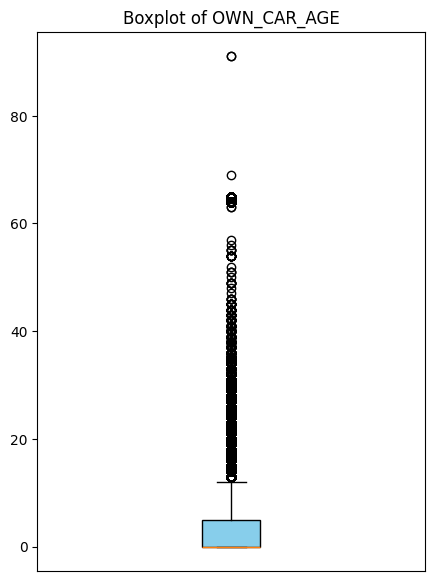

In [148]:
plt.figure(figsize=(5, 7))
plt.boxplot(train['OWN_CAR_AGE'].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor="skyblue"))
plt.title("Boxplot of OWN_CAR_AGE")
plt.ylabel('')
plt.xlabel('')
plt.xticks([])
plt.show()

In [149]:
train['OWN_CAR_AGE'] = train['OWN_CAR_AGE'].clip(upper=60)
test['OWN_CAR_AGE'] = test['OWN_CAR_AGE'].clip(upper=60)

In [150]:
train["OWN_CAR_AGE"].describe()

count   307501.000
mean         4.055
std          8.704
min          0.000
25%          0.000
50%          0.000
75%          5.000
max         60.000
Name: OWN_CAR_AGE, dtype: float64

### CNT_CHILDREN, CNT_FAM_MEMBERS

In [151]:
train[["CNT_CHILDREN", "CNT_FAM_MEMBERS",]].describe()

,CNT_CHILDREN,CNT_FAM_MEMBERS
count,307501.000,307501.000
mean,0.417,2.153
std,0.722,0.911
min,0.000,1.000
25%,0.000,2.000
50%,0.000,2.000
75%,1.000,3.000
max,19.000,20.000


Check if CNT_FAM_MEMBERS ≥ CNT_CHILDREN + 1 (at least 1 adult per family):

In [152]:
invalid_families = train[train['CNT_FAM_MEMBERS'] < (train['CNT_CHILDREN'] + 1)]
print(f"Invalid family records: {len(invalid_families)}")

Invalid family records: 0


In [153]:
invalid_families = df[df['CNT_FAM_MEMBERS'] < (df['CNT_CHILDREN'] + 1)]
print(f"Invalid family records: {len(invalid_families)}")

Invalid family records: 0


### OBS_30_CNT_SOCIAL_CIRCLE

In [154]:
float_features = [
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_QRT"
]

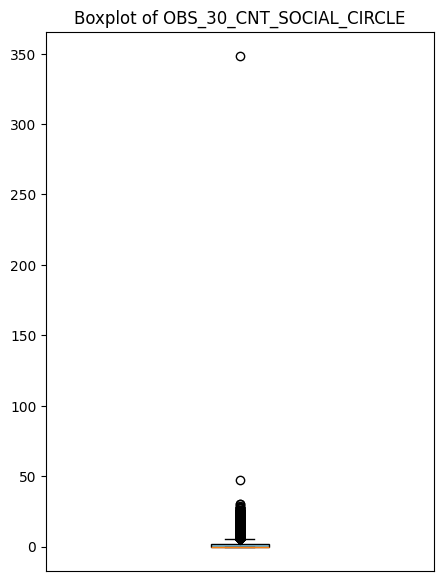

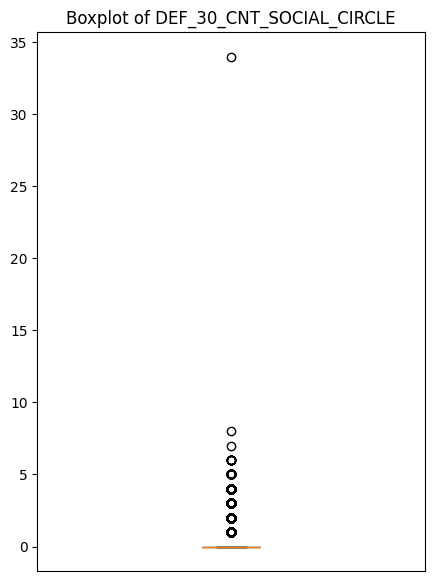

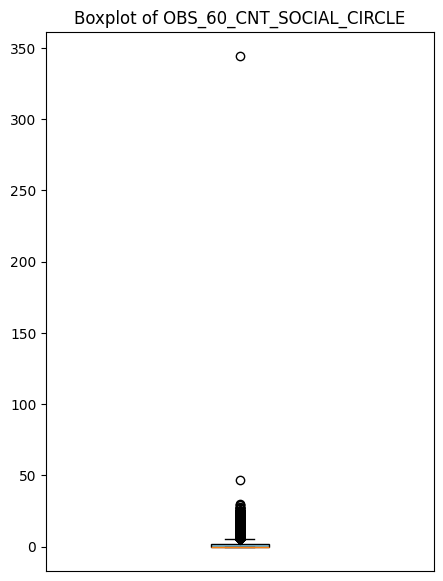

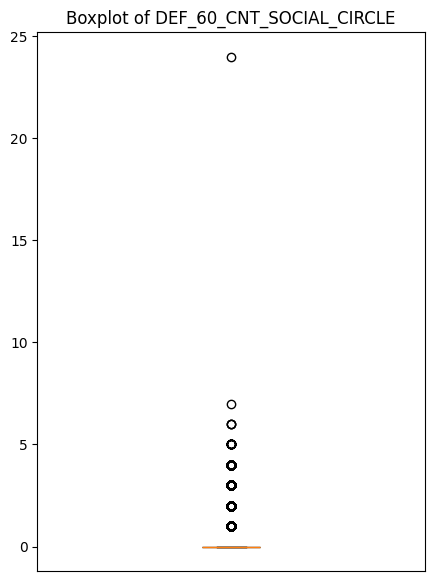

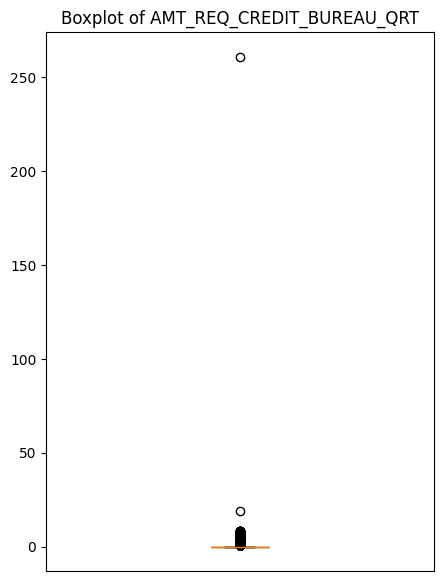

In [155]:
# Create individual boxplots
for feature in float_features:
    plt.figure(figsize=(5, 7))
    plt.boxplot(train[feature].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="skyblue"))
    plt.title(f"Boxplot of {feature}")
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks([])
    plt.show()

In [156]:
train[train['OBS_30_CNT_SOCIAL_CIRCLE'] > 40]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS,REVOLVING_GOODS_OVER_CREDIT,GOODS_CREDIT_RATIO,CTI_RATIO,HIGH_CTI,HIGH_CTI_RISK,ATI_RATIO,HIGH_ATI,HIGH_ATI_RISK,GTI_RATIO,HIGH_GTI,HIGH_GTI_RISK,AGE_YEARS
77497,189856,0,Cash loans,M,Y,Y,1,157500.000,296280.000,23539.500,225000.000,Family,Working,Secondary / secondary special,Married,House / apartment,0.010,-14767,-2767,-13306.000,-4720,11.000,1,1,0,1,0,1,Laborers,3.000,2,2,MONDAY,17,0,0,0,0,0,0,Industry: type 4,0.460,0.399,0.750,0.222,0.174,0.982,-999.000,-999.000,0.240,0.207,0.333,-999.000,0.110,-999.000,0.262,-999.000,-999.000,0.226,0.181,0.982,-999.000,-999.000,0.242,0.207,0.333,-999.000,0.113,-999.000,0.272,-999.000,-999.000,0.224,0.174,0.982,-999.000,-999.000,0.240,0.207,0.333,-999.000,0.112,-999.000,0.266,-999.000,-999.000,Missing,block of flats,0.206,Panel,No,47.000,0.000,47.000,0.000,0.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,4.000,0,0,0,0,1,0,7.581,Mid_Term,0,0.759,1.881,False,0,0.149,False,0,1.429,False,0,40.430
148403,272071,0,Revolving loans,M,N,Y,0,202500.000,180000.000,9000.000,180000.000,Family,State servant,Higher education,Single / not married,House / apartment,0.020,-10111,-1917,-2306.000,-2306,0.000,1,1,0,1,0,0,Core staff,1.000,3,3,THURSDAY,9,0,0,0,0,1,1,Police,0.361,0.305,0.357,-999.000,0.031,0.987,0.816,-999.000,0.120,0.035,0.333,0.375,-999.000,0.030,0.024,-999.000,-999.000,-999.000,0.032,0.987,0.824,-999.000,0.121,0.035,0.333,0.375,-999.000,0.033,0.025,-999.000,-999.000,-999.000,0.031,0.987,0.819,-999.000,0.120,0.035,0.333,0.375,-999.000,0.031,0.024,-999.000,-999.000,reg oper account,block of flats,0.030,Panel,No,348.000,34.000,344.000,24.000,-667.

In [157]:
train = train[train['OBS_30_CNT_SOCIAL_CIRCLE'] <= 40]
test = test[test['OBS_30_CNT_SOCIAL_CIRCLE'] <= 40]

In [158]:
train[train['OBS_30_CNT_SOCIAL_CIRCLE'] > 40]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,FLAG_CREDIT_BUREAU_MISSING,FLAG_EXT_SOURCE_3_MISSING,FLAG_NO_CAR,FLAG_EXT_SOURCE_1_MISSING,FLAG_BUILDING_INFO_MISSING,FLAG_UNEMPLOYED,YEARS_EMPLOYED,EMPLOYMENT_STATUS,REVOLVING_GOODS_OVER_CREDIT,GOODS_CREDIT_RATIO,CTI_RATIO,HIGH_CTI,HIGH_CTI_RISK,ATI_RATIO,HIGH_ATI,HIGH_ATI_RISK,GTI_RATIO,HIGH_GTI,HIGH_GTI_RISK,AGE_YEARS


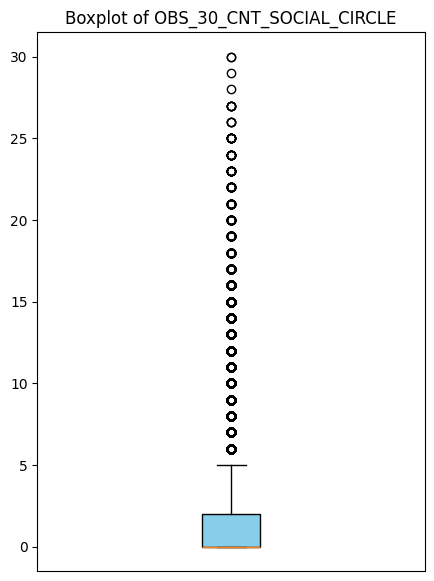

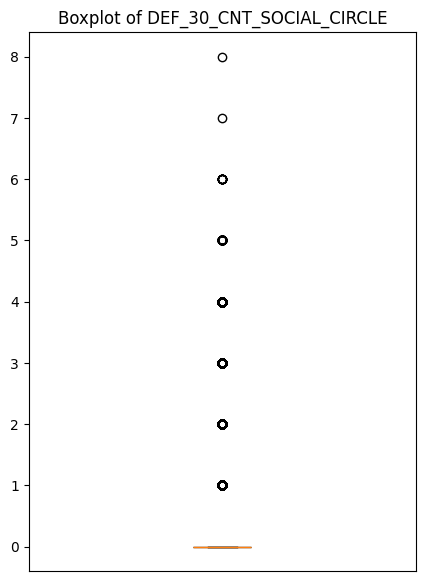

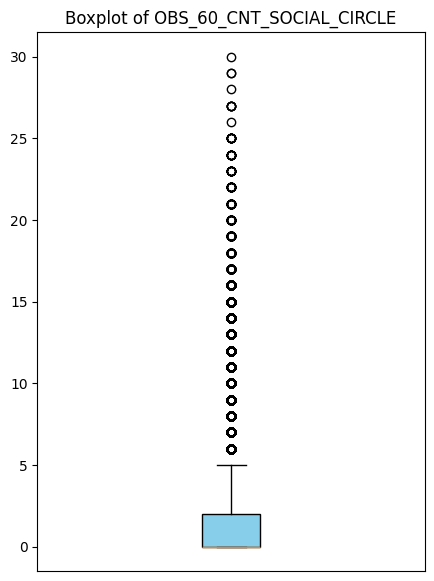

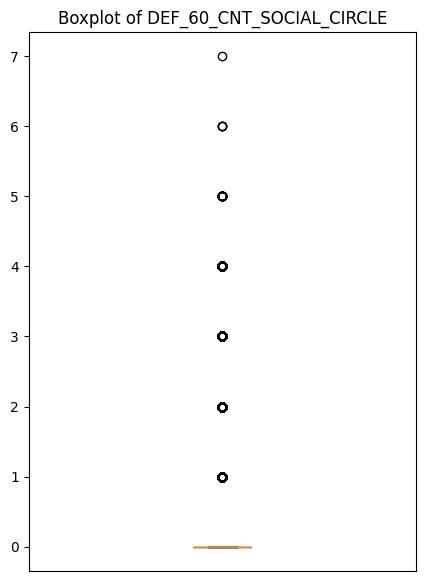

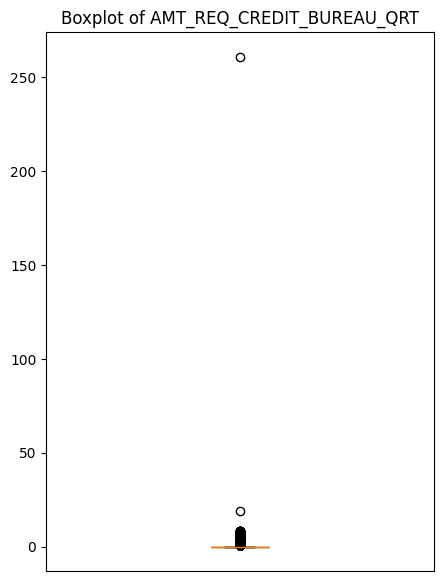

In [159]:
# Create individual boxplots
for feature in float_features:
    plt.figure(figsize=(5, 7))
    plt.boxplot(train[feature].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="skyblue"))
    plt.title(f"Boxplot of {feature}")
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks([])
    plt.show()

### AMT_REQ_CREDIT_BUREAU_QRT

In [160]:
train['AMT_REQ_CREDIT_BUREAU_QRT'].describe()

count   307499.000
mean         0.230
std          0.744
min          0.000
25%          0.000
50%          0.000
75%          0.000
max        261.000
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: float64

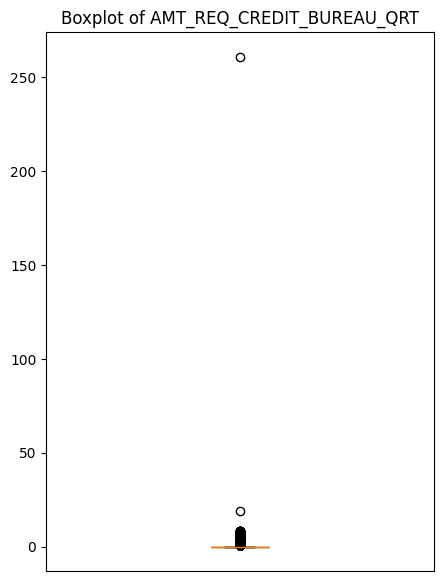

In [161]:
plt.figure(figsize=(5, 7))
plt.boxplot(train['AMT_REQ_CREDIT_BUREAU_QRT'].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor="skyblue"))
plt.title("Boxplot of AMT_REQ_CREDIT_BUREAU_QRT")
plt.ylabel('')
plt.xlabel('')
plt.xticks([])
plt.show()

In [162]:
train[train['AMT_REQ_CREDIT_BUREAU_QRT'] > 10]['AMT_REQ_CREDIT_BUREAU_QRT']

239474   261.000
253541    19.000
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: float64

In [163]:
# Manual Cap
cap_value = 10

In [164]:
train['AMT_REQ_CREDIT_BUREAU_QRT'] = np.where(
    train['AMT_REQ_CREDIT_BUREAU_QRT'] > cap_value, 
    cap_value, 
    train['AMT_REQ_CREDIT_BUREAU_QRT']
)

test['AMT_REQ_CREDIT_BUREAU_QRT'] = np.where(
    test['AMT_REQ_CREDIT_BUREAU_QRT'] > cap_value, 
    cap_value, 
    test['AMT_REQ_CREDIT_BUREAU_QRT']
)

In [165]:
train[train['AMT_REQ_CREDIT_BUREAU_QRT'] > 10]['AMT_REQ_CREDIT_BUREAU_QRT']

Series([], Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: float64)

**Verify Again**

In [166]:
float_features = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_EMPLOYED",
    "OWN_CAR_AGE",
    "CNT_FAM_MEMBERS",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_QRT"
]

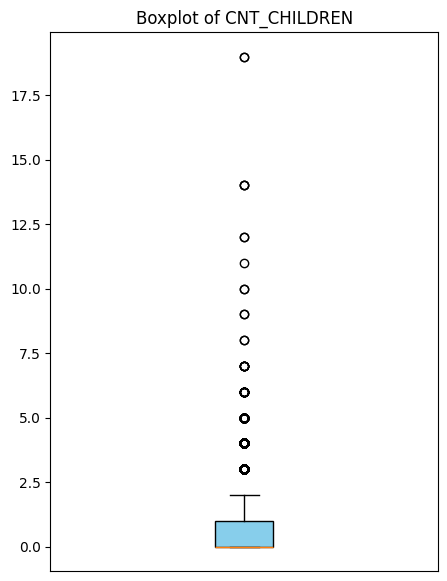

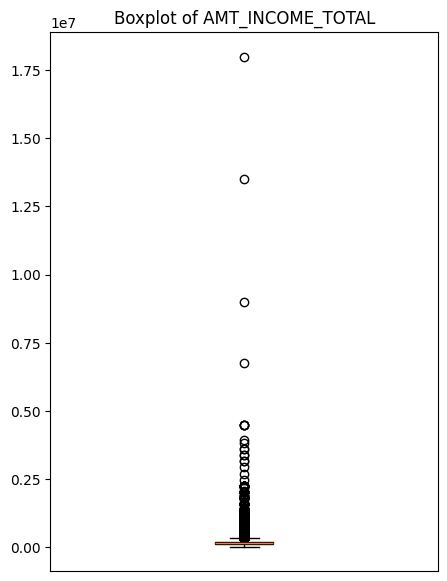

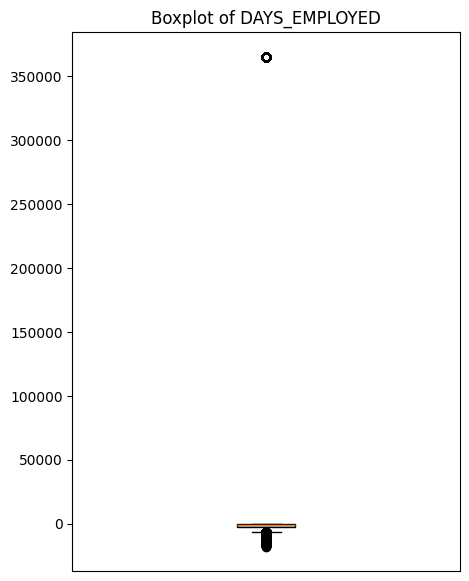

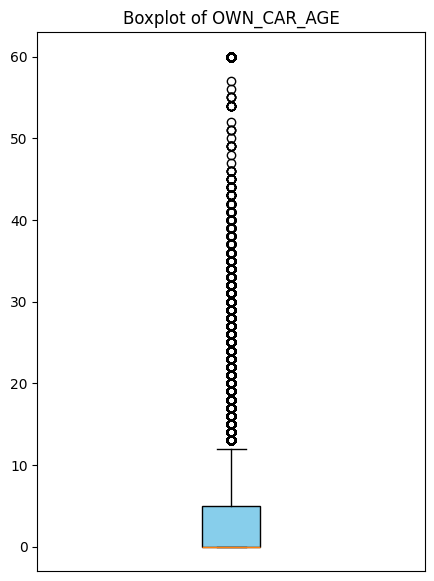

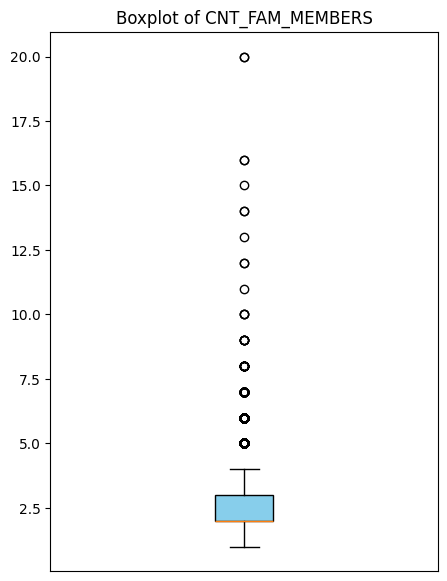

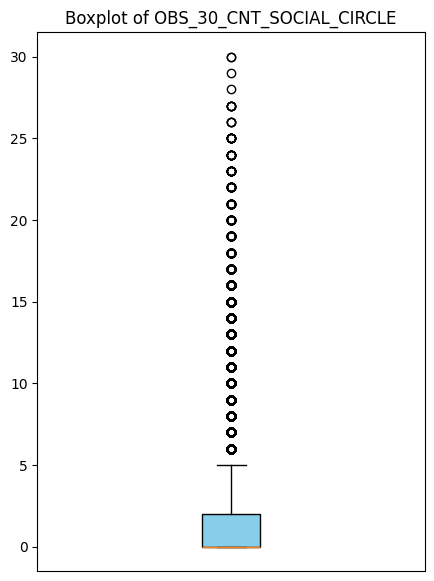

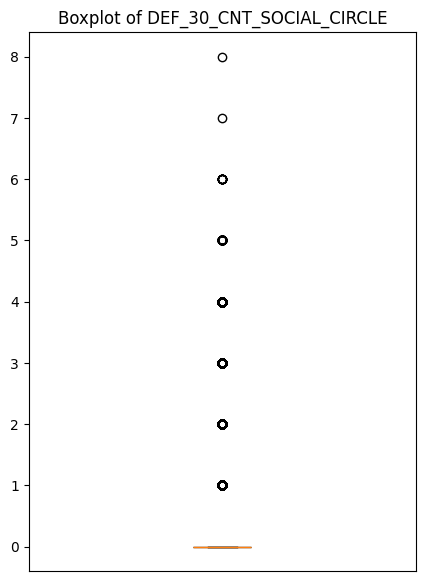

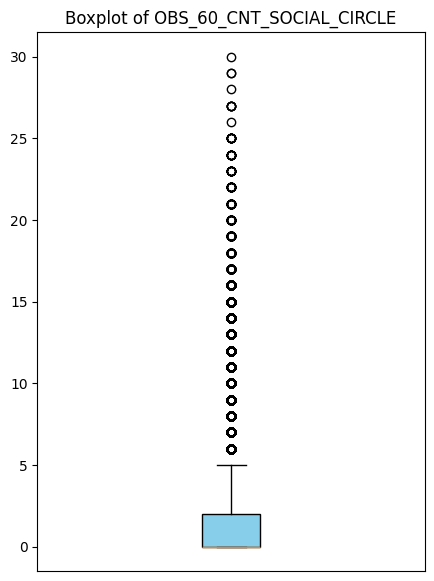

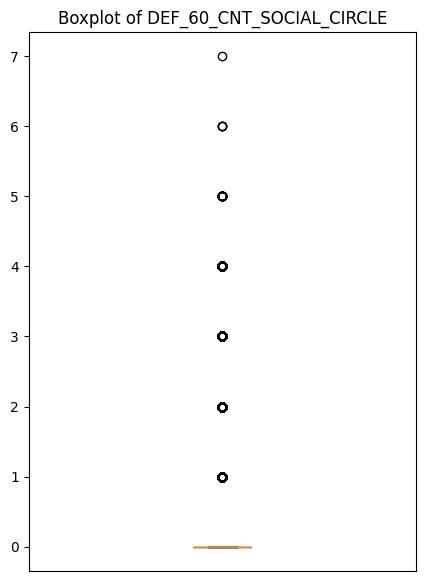

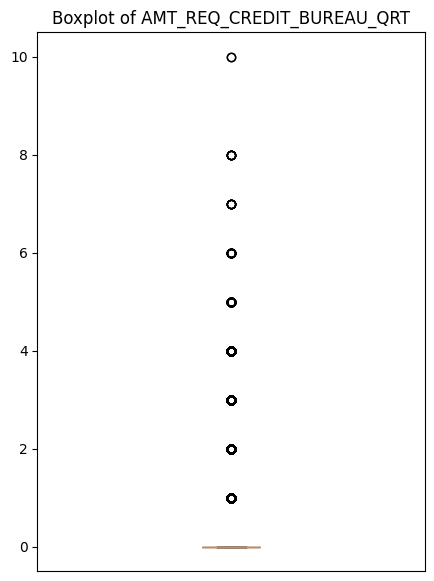

In [167]:
# Create individual boxplots
for feature in float_features:
    plt.figure(figsize=(5, 7))
    plt.boxplot(train[feature].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="skyblue"))
    plt.title(f"Boxplot of {feature}")
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks([])
    plt.show()

## Handling Skewness

Skewness Interpretation
- 0 to ±0.5 → Nearly symmetric (No transformation needed)
- ±0.5 to ±1.0 → Moderately skewed (Mild transformation)
- \>±1.0 → Strongly skewed (Stronger transformation required)

**Exclude the Binary Features**

In [168]:
# Filter numeric columns first
numeric_cols = train.select_dtypes(include='number')

In [169]:
# Drop binary columns (only two unique values)
non_binary_cols = [col for col in numeric_cols.columns if train[col].nunique() > 2]

In [170]:
# Compute skew only for non-binary numeric columns
skewed = train[non_binary_cols].skew().sort_values(ascending=True)
print(skewed)

YEARS_EMPLOYED               -1.664
EXT_SOURCE_2                 -0.796
DAYS_LAST_PHONE_CHANGE       -0.714
DAYS_REGISTRATION            -0.591
EXT_SOURCE_3                 -0.538
                              ...  
AMT_REQ_CREDIT_BUREAU_MON     8.371
AMT_REQ_CREDIT_BUREAU_WEEK   10.009
AMT_REQ_CREDIT_BUREAU_HOUR   15.642
AMT_INCOME_TOTAL             26.978
AMT_REQ_CREDIT_BUREAU_DAY    29.081
Length: 78, dtype: float64


While skewness transformations can improve the performance of some machine learning models, they are generally less critical for tree-based models like DecisionTree, RandomForest, LightGBM, and XGBoost.

# Data Visualization

## Target Distribution

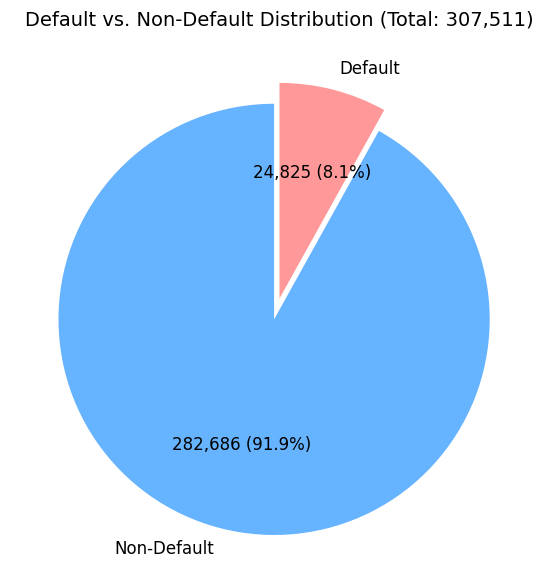

In [171]:
# Calculate the frequency of each class
target_counts = df['TARGET'].value_counts()

colors = ['#66b3ff', '#ff9999']

# Exploding the largest segment for emphasis
explode = [0.1 if i == target_counts.idxmax() else 0 for i in target_counts.index]

# Map the target values (1, 0) to their respective labels
label_map = {1: 'Default', 0: 'Non-Default'}

# Function to format the autopct with both number and percentage
def func(pct, allvalues):
    absolute = round(pct / 100. * sum(allvalues))
    return f"{absolute:,} ({pct:.1f}%)"

# Plot the pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    target_counts,
    labels=[label_map[i] for i in target_counts.index],
    autopct=lambda pct: func(pct, target_counts),
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={'edgecolor': 'none'},
    textprops={'fontsize': 12}
)

plt.title(f'Default vs. Non-Default Distribution (Total: {target_counts.sum():,})', fontsize=14, pad=0)
plt.show()

## Categorical Data vs Target

In [172]:
train.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
Index: 307499 entries, 0 to 307510
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   SK_ID_CURR                  307499 non-null  object
 1   TARGET                      307499 non-null  object
 2   NAME_CONTRACT_TYPE          307499 non-null  object
 3   CODE_GENDER                 307499 non-null  object
 4   FLAG_OWN_CAR                307499 non-null  object
 5   FLAG_OWN_REALTY             307499 non-null  object
 6   NAME_TYPE_SUITE             307499 non-null  object
 7   NAME_INCOME_TYPE            307499 non-null  object
 8   NAME_EDUCATION_TYPE         307499 non-null  object
 9   NAME_FAMILY_STATUS          307499 non-null  object
 10  NAME_HOUSING_TYPE           307499 non-null  object
 11  OCCUPATION_TYPE             307499 non-null  object
 12  WEEKDAY_APPR_PROCESS_START  307499 non-null  object
 13  ORGANIZATION_TYPE           307499

In [173]:
def prop_agg(train, y, x):
  temp_train = train.groupby([y,x], as_index = False).size()
  temp_train['prop'] = temp_train['size'] / temp_train.groupby(y)['size'].transform('sum')
  return temp_train

In [174]:
prop_agg(train, "NAME_CONTRACT_TYPE", "TARGET")

,NAME_CONTRACT_TYPE,TARGET,size,prop
0,Cash loans,0,255010,0.917
1,Cash loans,1,23220,0.083
2,Revolving loans,0,27665,0.945
3,Revolving loans,1,1604,0.055


**NAME_CONTRACT_TYPE vs TARGET**

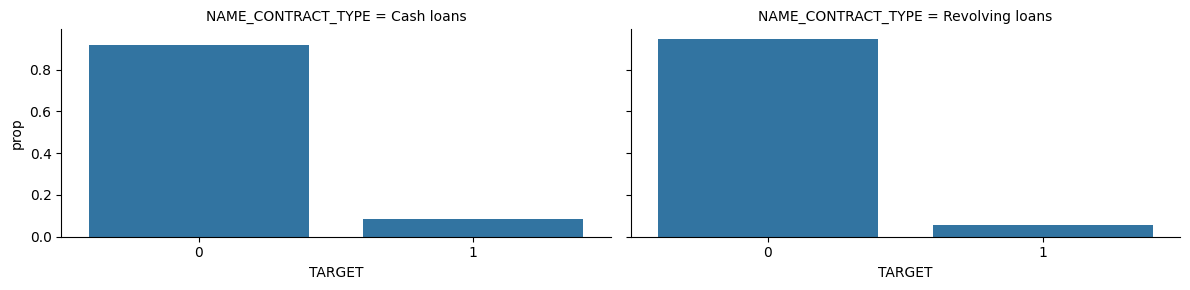

In [175]:
g = sns.FacetGrid(
    data = prop_agg(train, "NAME_CONTRACT_TYPE", "TARGET"),
    col = "NAME_CONTRACT_TYPE",
    aspect = 2
)
g.map(sns.barplot, "TARGET", "prop");

Applicants with contract type Cash loans show slightly higher churn than Revolving loans. The difference is small, but it suggests that NAME_CONTRACT_TYPE has a moderate predictive effect on churn.

**CODE_GENDER vs TARGET**

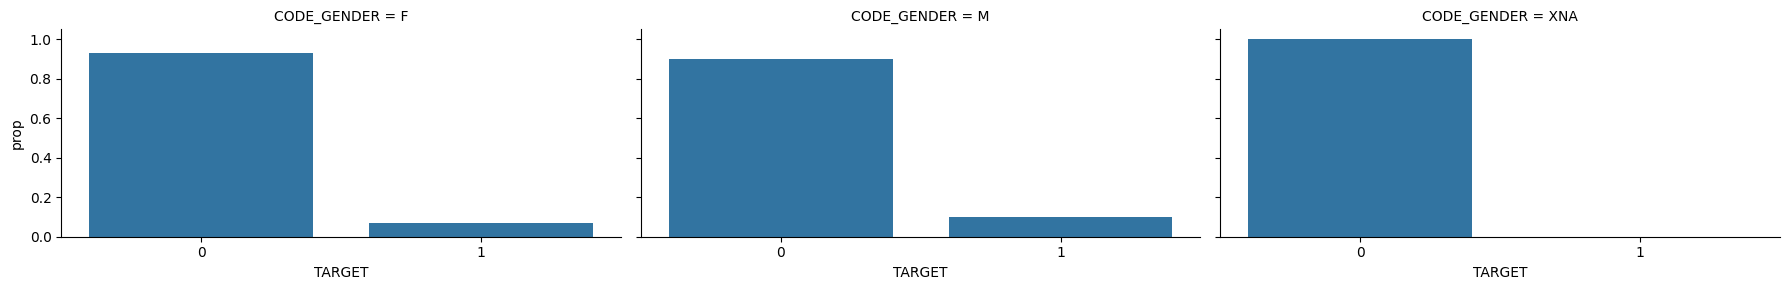

In [176]:
g = sns.FacetGrid(
    data = prop_agg(train, "CODE_GENDER", "TARGET"),
    col = "CODE_GENDER",
    aspect = 2
)
g.map(sns.barplot, "TARGET", "prop");

Male applicants have higher churn than females, indicating that CODE_GENDER also has a moderate predictive effect.

**NAME_TYPE_SUITE vs TARGET**

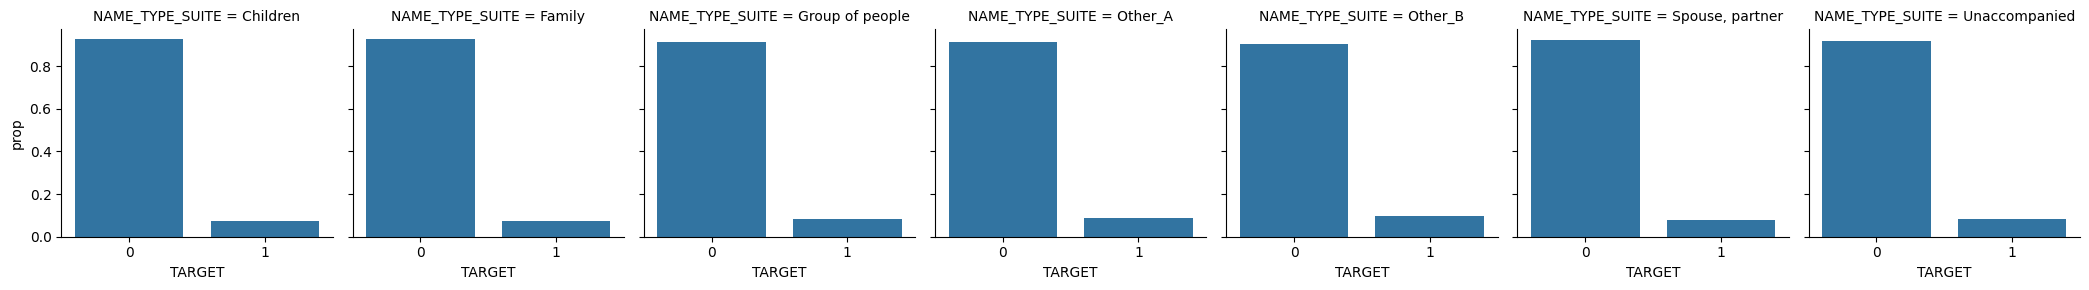

In [177]:
g = sns.FacetGrid(
    data = prop_agg(train, "NAME_TYPE_SUITE", "TARGET"),
    col = "NAME_TYPE_SUITE"
)
g.map(sns.barplot, "TARGET", "prop");

For NAME_TYPE_SUITE, churn and non-churn proportions are similar, making it a weak predictor.

**NAME_INCOME_TYPE vs TARGET**

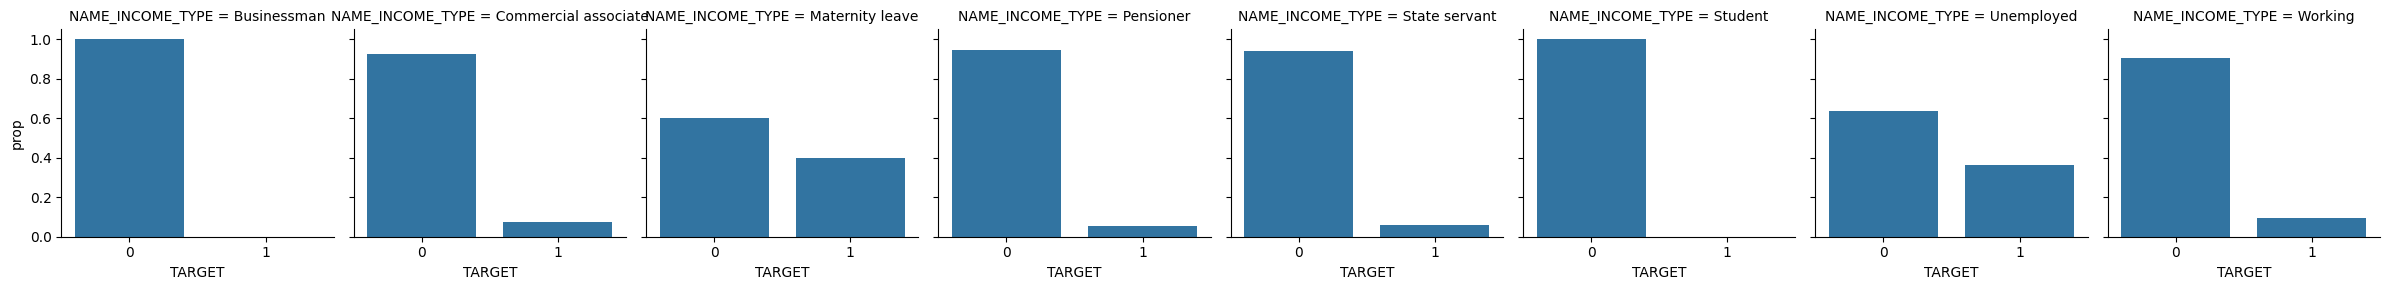

In [178]:
g = sns.FacetGrid(
    data = prop_agg(train, "NAME_INCOME_TYPE", "TARGET"),
    col = "NAME_INCOME_TYPE"
)
g.map(sns.barplot, "TARGET", "prop");

In NAME_INCOME_TYPE, churn rates fluctuate across categories due to uneven distribution, so it is considered a weak predictor.

In [179]:
train['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 158770
Commercial associate     71616
Pensioner                55358
State servant            21700
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

**NAME_EDUCATION_TYPE vs TARGET**

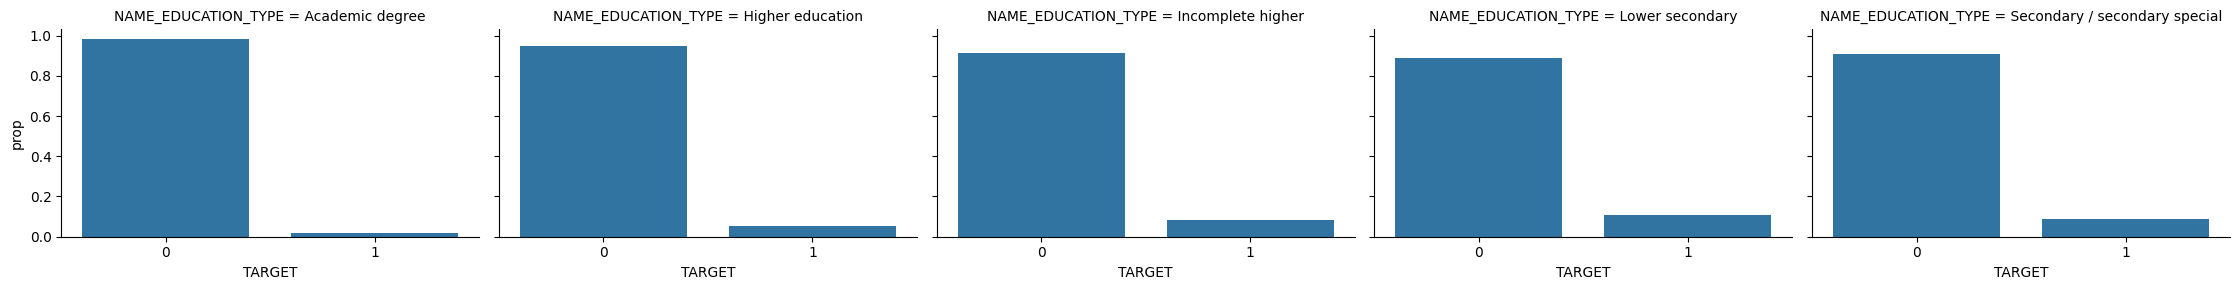

In [180]:
g = sns.FacetGrid(
    data = prop_agg(train, "NAME_EDUCATION_TYPE", "TARGET"),
    col = "NAME_EDUCATION_TYPE",
    aspect = 1.5
)
g.map(sns.barplot, "TARGET", "prop");

The same applies to NAME_EDUCATION_TYPE: churn patterns are inconsistent across categories, suggesting weak predictive power.

In [181]:
train['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218383
Higher education                  74860
Incomplete higher                 10277
Lower secondary                    3815
Academic degree                     164
Name: count, dtype: int64

**NAME_FAMILY_STATUS vs TARGET**

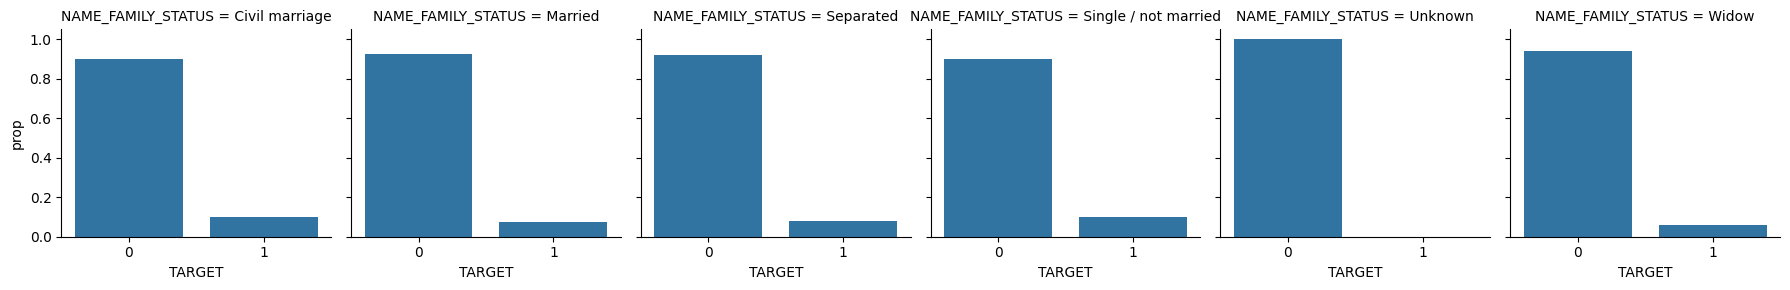

In [182]:
g = sns.FacetGrid(
    data = prop_agg(train, "NAME_FAMILY_STATUS", "TARGET"),
    col = "NAME_FAMILY_STATUS"
)
g.map(sns.barplot, "TARGET", "prop");

NAME_FAMILY_STATUS shows nearly equal churn and non-churn distribution across categories, so it is a weak predictor.

In [183]:
train['NAME_FAMILY_STATUS'].value_counts()

NAME_FAMILY_STATUS
Married                 196426
Single / not married     45439
Civil marriage           29775
Separated                19770
Widow                    16087
Unknown                      2
Name: count, dtype: int64

**NAME_HOUSING_TYPE vs TARGET**

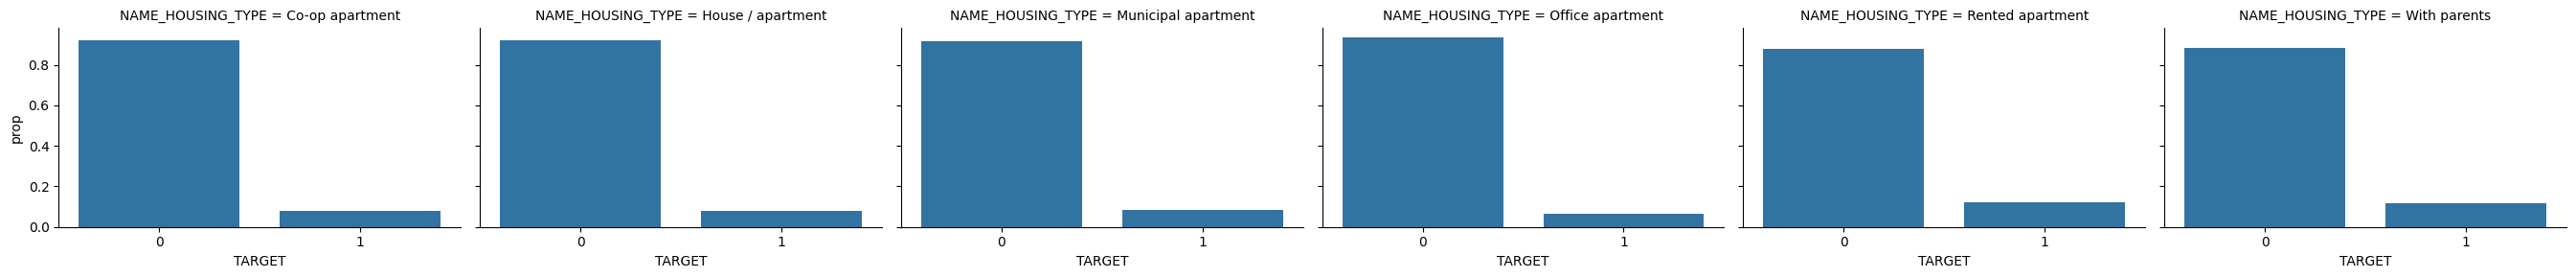

In [184]:
g = sns.FacetGrid(
    data = prop_agg(train, "NAME_HOUSING_TYPE", "TARGET"),
    col = "NAME_HOUSING_TYPE",
    aspect = 1.5
)
g.map(sns.barplot, "TARGET", "prop");

For NAME_HOUSING_TYPE, applicants renting apartments or living with parents have higher churn, indicating moderate predictive power.

In [185]:
train['NAME_HOUSING_TYPE'].value_counts()

NAME_HOUSING_TYPE
House / apartment      272859
With parents            14839
Municipal apartment     11182
Rented apartment         4880
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

**OCCUPATION_TYPE vs TARGET**

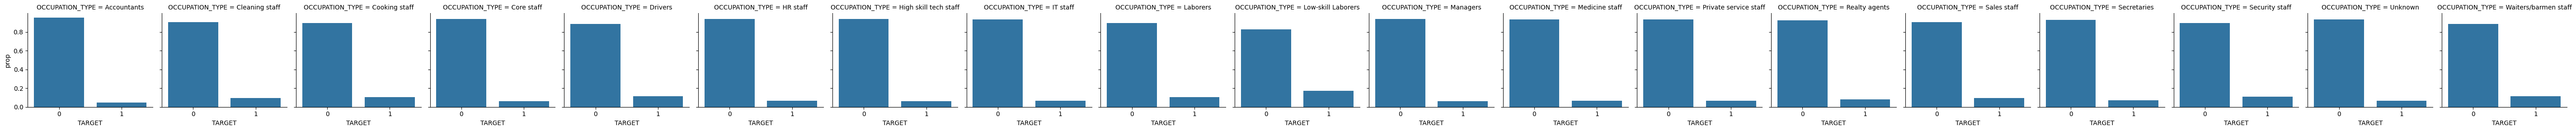

In [186]:
g = sns.FacetGrid(
    data = prop_agg(train, "OCCUPATION_TYPE", "TARGET"),
    col = "OCCUPATION_TYPE"
)
g.map(sns.barplot, "TARGET", "prop");

In OCCUPATION_TYPE, Low-skill Laborers show higher churn, and proportions vary across occupations. This makes it a moderate predictor.

In [187]:
train['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Unknown                  96382
Laborers                 55184
Sales staff              32102
Core staff               27569
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

## Numerical Data vs Target

In [188]:
# Select numeric columns
numeric_df = train.select_dtypes(include='number')

# Exclude binary columns (columns with exactly 2 unique values)
non_binary_df = numeric_df.loc[:, numeric_df.nunique() > 2]

# Display info
non_binary_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307499 entries, 0 to 307510
Data columns (total 78 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   CNT_CHILDREN                  307499 non-null  int64  
 1   AMT_INCOME_TOTAL              307499 non-null  float64
 2   AMT_CREDIT                    307499 non-null  float64
 3   AMT_ANNUITY                   307499 non-null  float64
 4   AMT_GOODS_PRICE               307499 non-null  float64
 5   REGION_POPULATION_RELATIVE    307499 non-null  float64
 6   DAYS_BIRTH                    307499 non-null  int64  
 7   DAYS_EMPLOYED                 307499 non-null  int64  
 8   DAYS_REGISTRATION             307499 non-null  float64
 9   DAYS_ID_PUBLISH               307499 non-null  int64  
 10  OWN_CAR_AGE                   307499 non-null  float64
 11  CNT_FAM_MEMBERS               307499 non-null  float64
 12  REGION_RATING_CLIENT          307499 non-null  in

**AMT_INCOME_TOTAL vs TARGET**

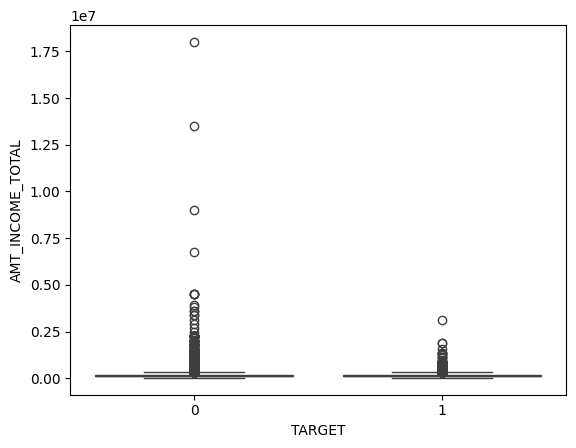

In [189]:
sns.boxplot(x = "TARGET", y = "AMT_INCOME_TOTAL", data = train);

In AMT_INCOME_TOTAL, applicants with lower income tend to churn, suggesting it is a moderate to strong predictor.

**AMT_CREDIT vs TARGET**

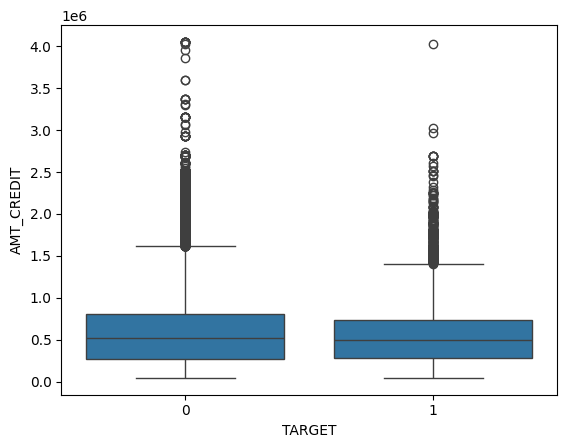

In [190]:
sns.boxplot(x = "TARGET", y = "AMT_CREDIT", data = train);

In AMT_CREDIT, churn and non-churn distributions are similar, making it a weak predictor.

**AMT_ANNUITY vs TARGET**

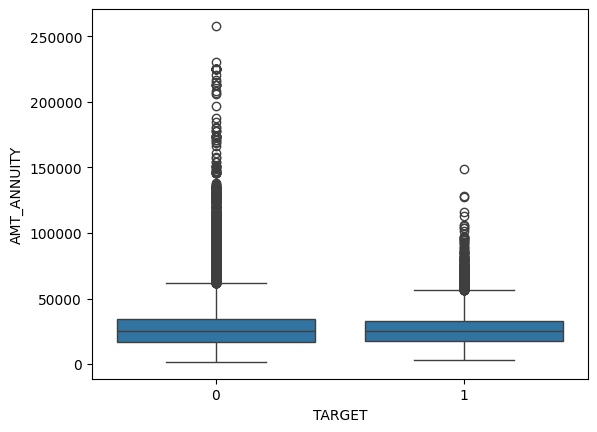

In [191]:
sns.boxplot(x = "TARGET", y = "AMT_ANNUITY", data = train);

In AMT_ANNUITY, applicants with lower annuity values tend to churn more, suggesting moderate predictive power.

**AMT_GOODS_PRICE vs TARGET**

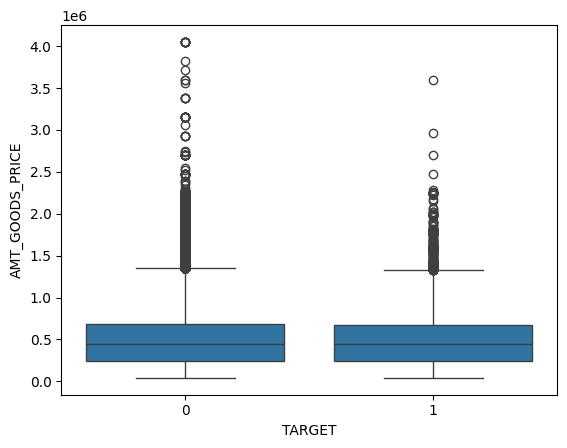

In [192]:
sns.boxplot(x = "TARGET", y = "AMT_GOODS_PRICE", data = train);

In AMT_GOODS_PRICE, the distributions are also similar, suggesting weak predictive power.

**AGE_YEARS vs TARGET**

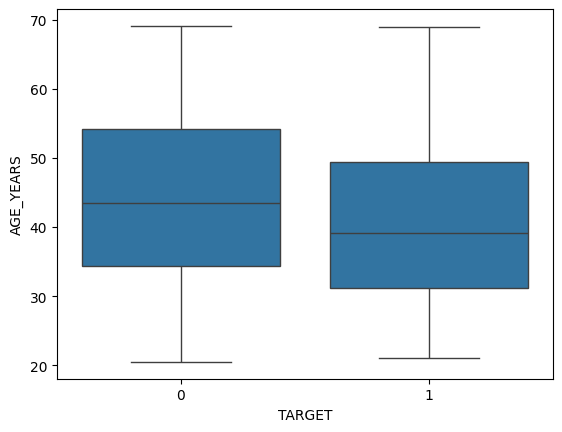

In [193]:
sns.boxplot(x = "TARGET", y = "AGE_YEARS", data = train);

In AGE_YEARS, younger applicants show higher churn, indicating a moderate predictor.

# Dropping Unused Column

This column is not important for building machine learning models, as it is merely an identifier.

In [194]:
# train = train.drop(columns=['SK_ID_CURR'])
# test = test.drop(columns=['SK_ID_CURR'])

# Replacing Some Values

Since there are only 4 “Unknown” out of more than 350,000 records, replacing XNA with the most frequent category avoids creating an almost-empty category that adds no real predictive power.

**CODE_GENDER**

In [195]:
train["CODE_GENDER"].value_counts().sort_index()

CODE_GENDER
F      202442
M      105053
XNA         4
Name: count, dtype: int64

In [196]:
most_freq = train['CODE_GENDER'].mode()[0]
print(f'Most Freq. Code Gender: {most_freq}')

Most Freq. Code Gender: F


In [197]:
# train n test

train['CODE_GENDER'] = train['CODE_GENDER'].replace('XNA', most_freq)
test['CODE_GENDER'] = test['CODE_GENDER'].replace('XNA', most_freq)

In [198]:
train["CODE_GENDER"].value_counts().sort_index()

CODE_GENDER
F    202446
M    105053
Name: count, dtype: int64

In [199]:
test["CODE_GENDER"].value_counts().sort_index()

CODE_GENDER
F    32676
M    16064
Name: count, dtype: int64

**ORGANIZATION_TYPE**

In [200]:
train["ORGANIZATION_TYPE"].value_counts().sort_index()

ORGANIZATION_TYPE
Advertising                 429
Agriculture                2454
Bank                       2507
Business Entity Type 1     5984
Business Entity Type 2    10553
Business Entity Type 3    67991
Cleaning                    260
Construction               6721
Culture                     379
Electricity                 950
Emergency                   560
Government                10403
Hotel                       966
Housing                    2958
Industry: type 1           1039
Industry: type 10           109
Industry: type 11          2704
Industry: type 12           369
Industry: type 13            67
Industry: type 2            458
Industry: type 3           3278
Industry: type 4            876
Industry: type 5            599
Industry: type 6            112
Industry: type 7           1307
Industry: type 8             24
Industry: type 9           3368
Insurance                   597
Kindergarten               6880
Legal Services              305
Medicine              

In [201]:
# train, test, df

train['ORGANIZATION_TYPE'] = train['ORGANIZATION_TYPE'].replace('XNA', 'Unknown')
test['ORGANIZATION_TYPE'] = test['ORGANIZATION_TYPE'].replace('XNA', 'Unknown')
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].replace('XNA', 'Unknown')

In [202]:
df["ORGANIZATION_TYPE"].value_counts().sort_index()

ORGANIZATION_TYPE
Advertising                 500
Agriculture                2746
Bank                       2881
Business Entity Type 1     6871
Business Entity Type 2    12032
Business Entity Type 3    78832
Cleaning                    303
Construction               7760
Culture                     440
Electricity                1106
Emergency                   651
Government                11912
Hotel                      1100
Housing                    3393
Industry: type 1           1217
Industry: type 10           133
Industry: type 11          3120
Industry: type 12           446
Industry: type 13            73
Industry: type 2            535
Industry: type 3           3767
Industry: type 4           1044
Industry: type 5            696
Industry: type 6            139
Industry: type 7           1524
Industry: type 8             27
Industry: type 9           3867
Insurance                   677
Kindergarten               7918
Legal Services              358
Medicine              

# Save the CSV files for creating a scorecard

In [203]:
# Ubuntu
local_path = '../tmp_dataset/'

train.to_csv(local_path + 'train_scorecard.csv', index=False)
test.to_csv(local_path + 'test_scorecard.csv', index=False)

# Feature Encoding

In [204]:
train.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
Index: 307499 entries, 0 to 307510
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   SK_ID_CURR                  307499 non-null  object
 1   TARGET                      307499 non-null  object
 2   NAME_CONTRACT_TYPE          307499 non-null  object
 3   CODE_GENDER                 307499 non-null  object
 4   FLAG_OWN_CAR                307499 non-null  object
 5   FLAG_OWN_REALTY             307499 non-null  object
 6   NAME_TYPE_SUITE             307499 non-null  object
 7   NAME_INCOME_TYPE            307499 non-null  object
 8   NAME_EDUCATION_TYPE         307499 non-null  object
 9   NAME_FAMILY_STATUS          307499 non-null  object
 10  NAME_HOUSING_TYPE           307499 non-null  object
 11  OCCUPATION_TYPE             307499 non-null  object
 12  WEEKDAY_APPR_PROCESS_START  307499 non-null  object
 13  ORGANIZATION_TYPE           307499

## Binary Encoding

**2 Unique Values**

In [205]:
contract_type_map = {'Cash loans': 0, 'Revolving loans': 1}

In [206]:
train['NAME_CONTRACT_TYPE'] = train['NAME_CONTRACT_TYPE'].map(contract_type_map)
test['NAME_CONTRACT_TYPE'] = test['NAME_CONTRACT_TYPE'].map(contract_type_map)

In [207]:
train['CODE_GENDER'] = train['CODE_GENDER'].apply(lambda x: 1 if x == 'F' else 0)
test['CODE_GENDER'] = test['CODE_GENDER'].apply(lambda x: 1 if x == 'F' else 0)

In [208]:
train['FLAG_OWN_CAR'] = train['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
test['FLAG_OWN_CAR'] = test['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})

In [209]:
train['FLAG_OWN_REALTY'] = train['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})
test['FLAG_OWN_REALTY'] = test['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})

**3 Unique Values**

In [210]:
# Binary encode "Yes" and keep "Missing" as a separate flag
train['EMERGENCY_YES'] = (train['EMERGENCYSTATE_MODE'] == 'Yes').astype(int)
train['EMERGENCY_MISSING'] = (train['EMERGENCYSTATE_MODE'] == 'Missing').astype(int)
train.drop('EMERGENCYSTATE_MODE', axis=1, inplace=True)

In [211]:
test['EMERGENCY_YES'] = (test['EMERGENCYSTATE_MODE'] == 'Yes').astype(int)
test['EMERGENCY_MISSING'] = (test['EMERGENCYSTATE_MODE'] == 'Missing').astype(int)
test.drop('EMERGENCYSTATE_MODE', axis=1, inplace=True)

## Ordinal Encoding

In [212]:
education_order = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4
}

In [213]:
train['NAME_EDUCATION_TYPE'] = train['NAME_EDUCATION_TYPE'].map(education_order)
test['NAME_EDUCATION_TYPE'] = test['NAME_EDUCATION_TYPE'].map(education_order)

## Cyclical Encoding

In [214]:
weekday_map = {
    'MONDAY': 0,
    'TUESDAY': 1,
    'WEDNESDAY': 2,
    'THURSDAY': 3,
    'FRIDAY': 4,
    'SATURDAY': 5,
    'SUNDAY': 6
}

In [215]:
for xf in [train, test]:
    xf['WEEKDAY_APPR_PROCESS_START'] = xf['WEEKDAY_APPR_PROCESS_START'].map(weekday_map)
    xf['WEEKDAY_SIN'] = np.sin(2 * np.pi * xf['WEEKDAY_APPR_PROCESS_START'] / 7)
    xf['WEEKDAY_COS'] = np.cos(2 * np.pi * xf['WEEKDAY_APPR_PROCESS_START'] / 7)
    xf.drop('WEEKDAY_APPR_PROCESS_START', axis=1, inplace=True)

## One-Hot Encoding (Dummy Encoding Version)

In [216]:
categorical_columns = ['NAME_TYPE_SUITE','NAME_INCOME_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE',
                       'FONDKAPREMONT_MODE','HOUSETYPE_MODE','WALLSMATERIAL_MODE','EMPLOYMENT_STATUS']

In [217]:
# Reset index to avoid index misalignment during concat/split
train_reset = train.reset_index(drop=True)
test_reset = test.reset_index(drop=True)

# Combine, encode, and split back
combined = pd.concat([train_reset, test_reset], axis=0)
combined = pd.get_dummies(combined, columns=categorical_columns, dtype=int, drop_first=True)

# Split back while preserving row order
train = combined.iloc[:len(train)].copy()
test = combined.iloc[len(train):].copy()

## Frequency Encoding (High Cardinality)

In [218]:
occupation_freq = train['OCCUPATION_TYPE'].value_counts(normalize=True)

In [219]:
for xf in [train, test]:
    xf['OCCUPATION_TYPE'] = xf['OCCUPATION_TYPE'].map(occupation_freq)

## Target Encoding (Very High Cardinality)

In [220]:
# from train
org_means = train.groupby('ORGANIZATION_TYPE')['TARGET'].mean()

In [221]:
for xf in [train, test]:
    xf['ORGANIZATION_TYPE_ENCODED'] = xf['ORGANIZATION_TYPE'].map(org_means)
    xf.drop('ORGANIZATION_TYPE', axis=1, inplace=True)

In [222]:
org_means.to_json("../dataset/org_means.json", orient="index", indent=4)

In [223]:
train['ORGANIZATION_TYPE_ENCODED'].isna().sum()

0

In [224]:
train['ORGANIZATION_TYPE_ENCODED'] = train['ORGANIZATION_TYPE_ENCODED'].astype(float)
test['ORGANIZATION_TYPE_ENCODED'] = test['ORGANIZATION_TYPE_ENCODED'].astype(float)

In [225]:
train['ORGANIZATION_TYPE_ENCODED']

0        0.093
1        0.059
2        0.070
3        0.093
4        0.059
          ... 
307494   0.066
307495   0.054
307496   0.059
307497   0.081
307498   0.093
Name: ORGANIZATION_TYPE_ENCODED, Length: 307499, dtype: float64

---

In [226]:
train.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
Index: 307499 entries, 0 to 307498
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   SK_ID_CURR  307499 non-null  object
 1   TARGET      307499 non-null  object
dtypes: object(2)
memory usage: 7.0+ MB


In [227]:
test.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
Index: 48740 entries, 0 to 48739
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SK_ID_CURR  48740 non-null  object
 1   TARGET      0 non-null      object
dtypes: object(2)
memory usage: 1.1+ MB


In [228]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307499 entries, 0 to 307498
Data columns (total 177 columns):
 #    Column                                    Non-Null Count   Dtype  
---   ------                                    --------------   -----  
 0    SK_ID_CURR                                307499 non-null  object 
 1    TARGET                                    307499 non-null  object 
 2    NAME_CONTRACT_TYPE                        307499 non-null  int64  
 3    CODE_GENDER                               307499 non-null  int64  
 4    FLAG_OWN_CAR                              307499 non-null  int64  
 5    FLAG_OWN_REALTY                           307499 non-null  int64  
 6    CNT_CHILDREN                              307499 non-null  int64  
 7    AMT_INCOME_TOTAL                          307499 non-null  float64
 8    AMT_CREDIT                                307499 non-null  float64
 9    AMT_ANNUITY                               307499 non-null  float64
 10   AMT_GOODS_P

In [229]:
test.shape

(48740, 177)

# Multicollinearity Check

## Correlation Matrix

I group the correlation strength into the following categories:
- Strong: Correlation strength ≥ 0.8 or ≤ -0.8
- Moderate: 0.3 < correlation strength < 0.8 or -0.8 < correlation strength < -0.3
- Weak: Correlation strength ≤ 0.3 and ≥ -0.3

In [230]:
def num_corr(df, corr_name='Correlation Matrix'):
    sns.set_style("whitegrid")
    plt.figure(figsize=(16, 6))
    correlation = df.corr(numeric_only=True)
    mask = np.zeros_like(correlation, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(correlation, annot=True, mask=mask, cmap='coolwarm', annot_kws={"size": 11})
    sns.despine(left=True, bottom=True)
    plt.grid(False)
    plt.xticks(fontsize=11, rotation=90)
    plt.yticks(fontsize=11, rotation=0)
    plt.title(f"{corr_name}", fontsize=16, fontweight='bold')

In [231]:
train[['AMT_CREDIT', 'AMT_GOODS_PRICE']].sample(10)

,AMT_CREDIT,AMT_GOODS_PRICE
25886,117162.000,103500.000
39775,490536.000,405000.000
92439,540000.000,540000.000
136508,540000.000,540000.000
193244,284400.000,225000.000
124970,508495.500,454500.000
289942,454500.000,454500.000
257555,746280.000,675000.000
292788,675000.000,675000.000
99565,202500.000,202500.000


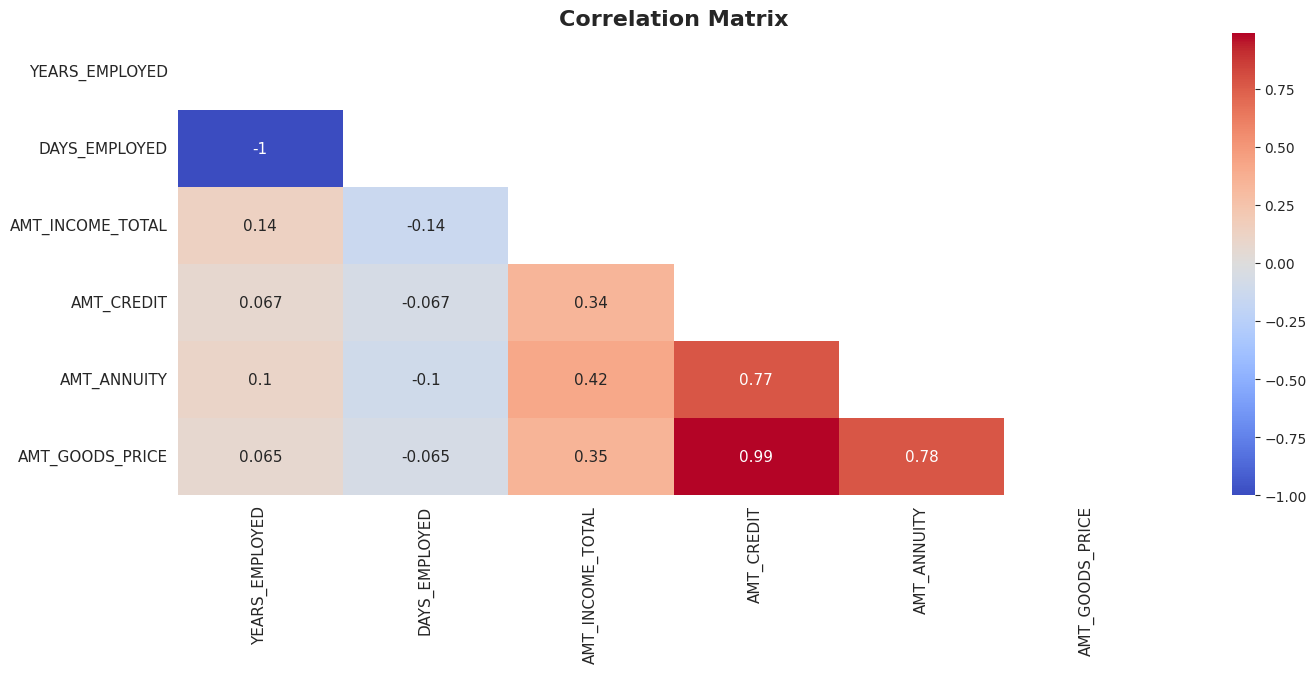

In [232]:
num_corr(train[['YEARS_EMPLOYED', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']])

In [233]:
def get_strong_correlations(df, threshold=0.8):

    # Select only numeric columns
    df_numeric = df.select_dtypes(include=['number'])
    
    # Calculate correlation matrix
    corr_matrix = df_numeric.corr()
    
    # Get upper triangle of correlation matrix without diagonal (to avoid self/redundant pairs)
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Unstack and sort by absolute correlation
    corr_pairs = upper_triangle.unstack().dropna().sort_values(key=abs, ascending=False)
    
    # Filter by threshold
    strong_corrs = corr_pairs[(corr_pairs >= threshold) | (corr_pairs <= -threshold)]
    
    # Convert to DataFrame for better presentation
    result_df = pd.DataFrame(strong_corrs).reset_index()
    result_df.columns = ['Feature 1', 'Feature 2', 'Correlation']
    
    # Sort by absolute correlation value
    result_df['Abs_Correlation'] = result_df['Correlation'].abs()
    result_df = result_df.sort_values('Abs_Correlation', ascending=False).drop('Abs_Correlation', axis=1)
    
    return result_df

In [234]:
pd.set_option("display.max_rows", None)

In [235]:
get_strong_correlations(train)

,Feature 1,Feature 2,Correlation
0,AGE_YEARS,DAYS_BIRTH,-1.000
1,EMPLOYMENT_STATUS_Unemployed,FLAG_UNEMPLOYED,1.000
2,YEARS_EMPLOYED,DAYS_EMPLOYED,-1.000
3,YEARS_BUILD_MEDI,YEARS_BUILD_AVG,1.000
4,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_AVG,1.000
5,COMMONAREA_MEDI,COMMONAREA_AVG,1.000
6,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,1.000
7,ENTRANCES_MEDI,ENTRANCES_AVG,1.000
8,BASEMENTAREA_MEDI,BASEMENTAREA_AVG,1.000
9,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MODE,1.000


In [236]:
col_to_drop = ['YEARS_EMPLOYED','AGE_YEARS','YEARS_BUILD_AVG','NONLIVINGAPARTMENTS_AVG','COMMONAREA_AVG','YEARS_BEGINEXPLUATATION_AVG','ENTRANCES_AVG',
               'BASEMENTAREA_AVG','NONLIVINGAPARTMENTS_MODE','LIVINGAPARTMENTS_AVG']

In [237]:
col_to_drop.extend(['NONLIVINGAREA_AVG','LANDAREA_AVG','FLOORSMIN_AVG','LIVINGAREA_AVG','APARTMENTS_AVG','FLOORSMAX_AVG',
               'ELEVATORS_AVG','COMMONAREA_MODE','YEARS_BUILD_MODE','NONLIVINGAREA_MODE','LANDAREA_MODE','BASEMENTAREA_MODE'])

In [238]:
col_to_drop.extend(['YEARS_BEGINEXPLUATATION_MODE','LIVINGAPARTMENTS_MODE','ENTRANCES_MODE','FLOORSMIN_MODE','FLOORSMAX_MODE','APARTMENTS_MODE',
               'ELEVATORS_MODE','LIVINGAREA_MODE'])

In [239]:
col_to_drop.extend(['OBS_60_CNT_SOCIAL_CIRCLE','YEARS_BEGINEXPLUATATION_MEDI','AMT_GOODS_PRICE','GTI_RATIO','FLOORSMAX_MEDI', 'ENTRANCES_MEDI', 'REGION_RATING_CLIENT'])

In [240]:
col_to_drop.extend(['FLOORSMIN_MEDI','ELEVATORS_MEDI','COMMONAREA_MEDI','NONLIVINGAREA_MEDI','DEF_60_CNT_SOCIAL_CIRCLE','BASEMENTAREA_MEDI'])

In [241]:
col_to_drop.extend(['NONLIVINGAPARTMENTS_MEDI','TOTALAREA_MODE','YEARS_BUILD_MEDI','LANDAREA_MEDI'])

In [242]:
col_to_drop.extend(['APARTMENTS_MEDI','CNT_CHILDREN'])

In [243]:
col_to_drop.extend(['EMPLOYMENT_STATUS_Unknown','FLAG_NO_CAR','NAME_INCOME_TYPE_Pensioner','FLAG_EMP_PHONE','WALLSMATERIAL_MODE_Missing',
                    'EMERGENCY_MISSING','REG_REGION_NOT_WORK_REGION','REG_CITY_NOT_WORK_CITY'])

In [244]:
col_to_drop.extend(['HOUSETYPE_MODE_block of flats', 'FLAG_BUILDING_INFO_MISSING', 'NAME_TYPE_SUITE_Family'])

In [245]:
col_to_drop.extend(['EMPLOYMENT_STATUS_Unemployed', 'FLAG_UNEMPLOYED'])

In [246]:
train = train.drop(col_to_drop, axis=1)
test = test.drop(col_to_drop, axis=1)

**Now there are no correlations greater than 0.8**

In [247]:
get_strong_correlations(train)

,Feature 1,Feature 2,Correlation


Keep only one from each pair (typically keep the more intuitive version)
- For age-related features, **DAYS_BIRTH** and **DAYS_EMPLOYED** are commonly used in credit scoring
- Person A: 12,000 days old (32.87 years)
- Person B: 12,400 days old (33.97 years)
- The model can see this 400-day difference if we use days, but would see both as "33" if we use years **(AGE_YEARS)**
- Model Performance: In Home Credit's own benchmarks, days consistently outperform years
- Industry Standard: FICO and other scoring systems use days for finer gradations

In [248]:
# Correlation greater than 0.7
get_strong_correlations(train, threshold=0.7)

,Feature 1,Feature 2,Correlation
0,FLAG_EXT_SOURCE_3_MISSING,FLAG_CREDIT_BUREAU_MISSING,0.794
1,ATI_RATIO,CTI_RATIO,0.788
2,AMT_ANNUITY,AMT_CREDIT,0.770
3,FONDKAPREMONT_MODE_reg oper account,LIVINGAPARTMENTS_MEDI,0.759


## VIF

I group the strength of VIF into the following categories:
- No multicollinearity: VIF = 1
- Moderate multicollinearity: 5 ≤ VIF ≤ 10
- Severe multicollinearity: VIF > 10

In [249]:
train.isna().sum()[train.isna().sum() > 0]

Series([], dtype: int64)

Calculate the VIF only for variables with a correlation strength greater than 0.3

The difference in VIF scores between correlation thresholds of 0.2 and 0.3 is small, so I choose 0.3 for better speed.

In [250]:
def calculate_vif(data, target_col='TARGET', corr_threshold=0.3):

    # Drop the target column and keep only numeric features
    X = data.drop(columns=target_col, errors='ignore')
    X = X.select_dtypes(include='number')
    
    # Correlation matrix and selecting highly correlated features
    corr_matrix = X.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_features = [col for col in upper_tri.columns if any(upper_tri[col] > corr_threshold)]
    
    # Subset and clean the data
    X_vif = X[high_corr_features]

    # Handle infs and NaNs
    # Temporary imputation for missing values (just for VIF)
    X_vif = X_vif.replace([np.inf, -np.inf], np.nan).fillna(X_vif.median(numeric_only=True))
    
    # Add constant for VIF computation
    X_vif = add_constant(X_vif)
    
    # Compute VIF
    vif_df = pd.DataFrame({
        "feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    })
    
    # Drop the constant and sort by VIF
    vif_df = vif_df[vif_df.feature != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)
    
    return vif_df

In [251]:
%%time
vif_results = calculate_vif(train, target_col='TARGET')

CPU times: user 3min 26s, sys: 1min 40s, total: 5min 6s
Wall time: 2min 1s


In [252]:
vif_results

,feature,VIF
0,CTI_RATIO,12.494
1,AMT_CREDIT,11.570
2,ATI_RATIO,9.382
3,AMT_ANNUITY,8.082
4,DAYS_EMPLOYED,3.674
5,LIVINGAREA_MEDI,3.410
6,NAME_FAMILY_STATUS_Married,2.808
7,FLAG_EXT_SOURCE_3_MISSING,2.726
8,FLAG_CREDIT_BUREAU_MISSING,2.718
9,WALLSMATERIAL_MODE_Panel,2.585


In [253]:
col_to_drop = ['CTI_RATIO']

train = train.drop(col_to_drop, axis=1)
test = test.drop(col_to_drop, axis=1)

In [254]:
vif_results = calculate_vif(train, target_col='TARGET')

In [255]:
vif_results

,feature,VIF
0,DAYS_EMPLOYED,3.674
1,LIVINGAREA_MEDI,3.410
2,AMT_ANNUITY,3.054
3,NAME_FAMILY_STATUS_Married,2.808
4,FLAG_EXT_SOURCE_3_MISSING,2.726
5,FLAG_CREDIT_BUREAU_MISSING,2.718
6,WALLSMATERIAL_MODE_Panel,2.585
7,AMT_CREDIT,2.537
8,"WALLSMATERIAL_MODE_Stone, brick",2.525
9,FLAG_DOCUMENT_3,2.376


The VIF values are all below 0.4, so multicollinearity is not a problem.

# Data Preprocessing III

## Handling Missing Values

In [256]:
train.shape, test.shape, df.shape

((307499, 114), (48740, 114), (356255, 143))

In [257]:
train.isnull().sum()[train.isnull().sum() > 0]

Series([], dtype: int64)

In [258]:
test.isnull().sum()[test.isnull().sum() > 0]

TARGET    48740
dtype: int64

In [259]:
df.isnull().sum()[df.isnull().sum() > 0]

TARGET                       48744
AMT_ANNUITY                     36
AMT_GOODS_PRICE                278
NAME_TYPE_SUITE               2203
CNT_FAM_MEMBERS                  2
EXT_SOURCE_1                193910
EXT_SOURCE_2                   668
EXT_SOURCE_3                 69633
OBS_30_CNT_SOCIAL_CIRCLE      1050
DEF_30_CNT_SOCIAL_CIRCLE      1050
OBS_60_CNT_SOCIAL_CIRCLE      1050
DEF_60_CNT_SOCIAL_CIRCLE      1050
DAYS_LAST_PHONE_CHANGE           1
GOODS_CREDIT_RATIO             278
ATI_RATIO                       36
GTI_RATIO                      278
dtype: int64

---

In [260]:
train.isnull().sum().sum()

0

In [261]:
test.isnull().sum().sum()

48740

In [262]:
df.isnull().sum().sum()

320267

# Feature Scaling

I'll try this in the ML notebook

# Save the PARQUET Files to HDFS (Machine Learning Dataset)

In [263]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307499 entries, 0 to 307498
Data columns (total 114 columns):
 #    Column                                    Non-Null Count   Dtype  
---   ------                                    --------------   -----  
 0    SK_ID_CURR                                307499 non-null  object 
 1    TARGET                                    307499 non-null  object 
 2    NAME_CONTRACT_TYPE                        307499 non-null  int64  
 3    CODE_GENDER                               307499 non-null  int64  
 4    FLAG_OWN_CAR                              307499 non-null  int64  
 5    FLAG_OWN_REALTY                           307499 non-null  int64  
 6    AMT_INCOME_TOTAL                          307499 non-null  float64
 7    AMT_CREDIT                                307499 non-null  float64
 8    AMT_ANNUITY                               307499 non-null  float64
 9    NAME_EDUCATION_TYPE                       307499 non-null  int64  
 10   REGION_POPU

In [264]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48740 entries, 0 to 48739
Data columns (total 114 columns):
 #    Column                                    Non-Null Count  Dtype  
---   ------                                    --------------  -----  
 0    SK_ID_CURR                                48740 non-null  object 
 1    TARGET                                    0 non-null      object 
 2    NAME_CONTRACT_TYPE                        48740 non-null  int64  
 3    CODE_GENDER                               48740 non-null  int64  
 4    FLAG_OWN_CAR                              48740 non-null  int64  
 5    FLAG_OWN_REALTY                           48740 non-null  int64  
 6    AMT_INCOME_TOTAL                          48740 non-null  float64
 7    AMT_CREDIT                                48740 non-null  float64
 8    AMT_ANNUITY                               48740 non-null  float64
 9    NAME_EDUCATION_TYPE                       48740 non-null  int64  
 10   REGION_POPULATION_RELATIV

In [265]:
train.shape, test.shape

((307499, 114), (48740, 114))

In [266]:
# Ubuntu
local_path = '../tmp_dataset/'

train.to_csv(local_path + 'train.csv', index=False)
test.to_csv(local_path + 'test.csv', index=False)

train.to_parquet(local_path + 'train.parquet', index=False)
test.to_parquet(local_path + 'test.parquet', index=False)

**Disable the Safe Mode**

In [267]:
!hdfs dfsadmin -safemode leave

Safe mode is OFF


**Make Directory in hdfs**

In [268]:
!hdfs dfs -mkdir -p /user/jihadakbr/credit_risk/ml_data

**Move or Put the PARQUET Files from Local to HDFS**

In [269]:
!hdfs dfs -put -f /home/jihadakbr/Project/Home_Credit_Default_Risk/tmp_dataset/train.parquet /user/jihadakbr/credit_risk/ml_data/train.parquet

In [270]:
!hdfs dfs -put -f /home/jihadakbr/Project/Home_Credit_Default_Risk/tmp_dataset/test.parquet /user/jihadakbr/credit_risk/ml_data/test.parquet

**My file inside HDFS system (virtual file system)**

In [271]:
!hdfs dfs -ls /user/jihadakbr/credit_risk/ml_data

Found 2 items
-rw-r--r--   1 jihadakbr hadoop    3102285 2025-10-06 21:25 /user/jihadakbr/credit_risk/ml_data/test.parquet
-rw-r--r--   1 jihadakbr hadoop   15756340 2025-10-06 21:24 /user/jihadakbr/credit_risk/ml_data/train.parquet


# Save the Clean Data to PostgreSQL

In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 143 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    356255 non-null  object 
 1    TARGET                        307511 non-null  object 
 2    NAME_CONTRACT_TYPE            356255 non-null  object 
 3    CODE_GENDER                   356255 non-null  object 
 4    FLAG_OWN_CAR                  356255 non-null  object 
 5    FLAG_OWN_REALTY               356255 non-null  object 
 6    CNT_CHILDREN                  356255 non-null  int64  
 7    AMT_INCOME_TOTAL              356255 non-null  float64
 8    AMT_CREDIT                    356255 non-null  float64
 9    AMT_ANNUITY                   356219 non-null  float64
 10   AMT_GOODS_PRICE               355977 non-null  float64
 11   NAME_TYPE_SUITE               354052 non-null  object 
 12   NAME_INCOME_TYPE            

In [273]:
df.shape

(356255, 143)

In [274]:
# import pandas as pd

# train = [{'x': 2, 'y': 3}]
# test = [{'x': 2}]

# train = pd.DataFrame(train)
# test = pd.DataFrame(test)


In [275]:
# Go one directory up
env_path = Path.cwd().parent / ".env"
# print(f"env_path: {env_path}")

In [276]:
# Load environment variables (credentials) from the .env file
load_dotenv(dotenv_path=env_path, override=True)

True

In [277]:
# Connection configuration for creating a new database
admin_dbname = os.getenv('DB_ADMIN_NAME')  # PostgreSQL template database
user = os.getenv('DB_USER')                # PostgreSQL username
password = os.getenv('DB_PASSWORD')        # PostgreSQL password
host = os.getenv('DB_HOST')                # Host
port = os.getenv('DB_PORT')                # Default PostgreSQL port

In [278]:
# Use 'with' statement to ensure the connection is always closed
try:
    with connect(
        dbname=admin_dbname,
        user=user,
        password=password,
        host=host,
        port=port
    ) as conn_admin:
        print("Connection successful")
except Exception as e:
    print(f"Failed to connect to database: {e}")

Connection successful


In [279]:
# Create a cursor to execute SQL commands
conn_admin.autocommit = True  # Needed to execute CREATE DATABASE
cur = conn_admin.cursor()     # Create cursor from connection

# Name of the new database
new_dbname = 'credit_risk'

# Create the new database if it doesn't already exist
try:
    cur.execute(f"CREATE DATABASE {new_dbname}")
    print(f"Database '{new_dbname}' created successfully!")
except psycopg2.errors.DuplicateDatabase:
    print(f"Database '{new_dbname}' already exists.")

# Close the admin connection
cur.close()
conn_admin.close()

Database 'credit_risk' already exists.


In [280]:
try:
    # Open a connection to the new database
    conn = connect(
        dbname=new_dbname,
        user=user,
        password=password,
        host=host,
        port=port
    )
    print(f"Connected successfully to database {new_dbname}")
except psycopg2.OperationalError as e:
    print(f"Failed to connect to database: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Connected successfully to database credit_risk


In [281]:
# Create a SQLAlchemy engine for connecting to PostgreSQL
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{new_dbname}')

In [282]:
%%time
# Save DataFrame to PostgreSQL using pandas.to_sql()
# 10-15 mins to run
df.to_sql('clean_data', engine, if_exists='replace', index=False)

print("Data successfully inserted into PostgreSQL!")

Data successfully inserted into PostgreSQL!
CPU times: user 8min 44s, sys: 2min 21s, total: 11min 5s
Wall time: 20min 10s


In [283]:
# Close the database connection
conn.close()